압축 해제 + 1,400장씩 분할이후 70 15 15 분할

In [ ]:
import os
import zipfile
import random
import shutil
from pathlib import Path

# =========================
# 기본 설정
# =========================
ZIP_PATH = "/content/tomato.zip"

EXTRACT_DIR = "/content/tomato_original"
OUTPUT_DIR = "/content/tomato_dataset"

SEED = 42
IMAGES_PER_CLASS = 1400

random.seed(SEED)

# =========================
# 기존 결과 삭제
# =========================
if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

os.makedirs(EXTRACT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# ZIP 압축 해제
# =========================
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("압축 해제 완료")
print("압축 해제 위치:", EXTRACT_DIR)


# =========================
# 사용할 7개 클래스
# =========================
classes = [
    "Tomato___Bacterial_spot",
    "Tomato___healthy",
    "Tomato___Late_blight",
    "Tomato___Septoria_leaf_spot",
    "Tomato___Spider_mites Two-spotted_spider_mite",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato___Target_Spot"
]

# =========================
# 이미지 확장자
# =========================
image_extensions = {
    ".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"
}

# =========================
# 실제 클래스 폴더 찾기
# =========================
class_dirs = {}

for root, dirs, files in os.walk(EXTRACT_DIR):
    for d in dirs:
        if d in classes:
            class_dirs[d] = os.path.join(root, d)

print("\n찾은 클래스:")
for cls in classes:
    if cls in class_dirs:
        print("✅", cls, "->", class_dirs[cls])
    else:
        print("❌ 찾지 못함:", cls)


# =========================
# 클래스별 데이터 생성
# =========================
for cls in classes:

    if cls not in class_dirs:
        raise FileNotFoundError(
            f"\n클래스 폴더를 찾을 수 없습니다: {cls}\n"
            "압축 해제 후 실제 폴더명을 확인해주세요."
        )

    source_dir = class_dirs[cls]

    # 이미지 목록
    images = [
        os.path.join(source_dir, f)
        for f in os.listdir(source_dir)
        if Path(f).suffix in image_extensions
    ]

    print(f"\n[{cls}]")
    print("원본 이미지:", len(images))

    # 최소 1400장 확인
    if len(images) < IMAGES_PER_CLASS:
        raise ValueError(
            f"{cls}의 이미지가 {IMAGES_PER_CLASS}장보다 적습니다."
        )

    # =========================
    # 랜덤하게 1400장 선택
    # =========================
    random.shuffle(images)
    selected = images[:IMAGES_PER_CLASS]

    # =========================
    # 70 / 15 / 15
    # =========================
    train_count = int(IMAGES_PER_CLASS * 0.70)
    val_count = int(IMAGES_PER_CLASS * 0.15)

    train_images = selected[:train_count]
    val_images = selected[train_count:train_count + val_count]
    test_images = selected[train_count + val_count:]

    print("Train:", len(train_images))
    print("Val  :", len(val_images))
    print("Test :", len(test_images))

    # =========================
    # 폴더 생성
    # =========================
    train_dir = os.path.join(OUTPUT_DIR, "train", cls)
    val_dir = os.path.join(OUTPUT_DIR, "val", cls)
    test_dir = os.path.join(OUTPUT_DIR, "test", cls)

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    # =========================
    # 파일 복사
    # =========================
    for img in train_images:
        shutil.copy2(
            img,
            os.path.join(train_dir, os.path.basename(img))
        )

    for img in val_images:
        shutil.copy2(
            img,
            os.path.join(val_dir, os.path.basename(img))
        )

    for img in test_images:
        shutil.copy2(
            img,
            os.path.join(test_dir, os.path.basename(img))
        )


# =========================
# 최종 결과 확인
# =========================
print("\n" + "=" * 50)
print("데이터셋 분할 완료")
print("=" * 50)

for split in ["train", "val", "test"]:

    split_dir = os.path.join(OUTPUT_DIR, split)

    total = 0

    print(f"\n[{split}]")

    for cls in classes:
        cls_dir = os.path.join(split_dir, cls)

        count = len([
            f for f in os.listdir(cls_dir)
            if Path(f).suffix in image_extensions
        ])

        total += count

        print(f"{cls}: {count}")

    print("합계:", total)

print("\n최종 데이터 위치:")
print(OUTPUT_DIR)

압축 해제 완료
압축 해제 위치: /content/tomato_original

찾은 클래스:
✅ Tomato___Bacterial_spot -> /content/tomato_original/tomato/Tomato___Bacterial_spot
✅ Tomato___healthy -> /content/tomato_original/tomato/Tomato___healthy
✅ Tomato___Late_blight -> /content/tomato_original/tomato/Tomato___Late_blight
✅ Tomato___Septoria_leaf_spot -> /content/tomato_original/tomato/Tomato___Septoria_leaf_spot
✅ Tomato___Spider_mites Two-spotted_spider_mite -> /content/tomato_original/tomato/Tomato___Spider_mites Two-spotted_spider_mite
✅ Tomato___Tomato_Yellow_Leaf_Curl_Virus -> /content/tomato_original/tomato/Tomato___Tomato_Yellow_Leaf_Curl_Virus
✅ Tomato___Target_Spot -> /content/tomato_original/tomato/Tomato___Target_Spot

[Tomato___Bacterial_spot]
원본 이미지: 2127
Train: 979
Val  : 210
Test : 211

[Tomato___healthy]
원본 이미지: 1591
Train: 979
Val  : 210
Test : 211

[Tomato___Late_blight]
원본 이미지: 1909
Train: 979
Val  : 210
Test : 211

[Tomato___Septoria_leaf_spot]
원본 이미지: 1771
Train: 979
Val  : 210
Test : 211

[Tomato__

Keras CNN 기본 모델

In [ ]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


라이브러리 + 시드

In [ ]:
DATA_DIR = "/content/tomato_dataset"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("클래스:", class_names)
print("클래스 수:", NUM_CLASSES)

Found 6853 files belonging to 7 classes.
Found 1470 files belonging to 7 classes.
Found 1477 files belonging to 7 classes.
클래스: ['Tomato___Bacterial_spot', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___healthy']
클래스 수: 7


데이터 불러오기

In [ ]:
DATA_DIR = "/content/tomato_dataset"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("클래스:", class_names)
print("클래스 수:", NUM_CLASSES)

Found 6853 files belonging to 7 classes.
Found 1470 files belonging to 7 classes.
Found 1477 files belonging to 7 classes.
클래스: ['Tomato___Bacterial_spot', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___healthy']
클래스 수: 7


성능을위한 캐시

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

cnn모델

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    # 정규화
    layers.Rescaling(1./255),

    # CNN Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # CNN Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # CNN Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Classification
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

Dropout(0.3) 을 0.5 로 과적합개선

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    # 정규화
    layers.Rescaling(1./255),

    # CNN Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # CNN Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # CNN Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Classification
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,543 (12.61 MB)

 Trainable params: 3,305,543 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

컴파일

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

학습

In [ ]:
EPOCHS = 30

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - accuracy: 0.5109 - loss: 1.2829 - val_accuracy: 0.7864 - val_loss: 0.6648
Epoch 2/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.7565 - loss: 0.6816 - val_accuracy: 0.8381 - val_loss: 0.5420
Epoch 3/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.8269 - loss: 0.4983 - val_accuracy: 0.8986 - val_loss: 0.3552
Epoch 4/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.8389 - loss: 0.4531 - val_accuracy: 0.9238 - val_loss: 0.3203
Epoch 5/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8707 - loss: 0.3666 - val_accuracy: 0.8680 - val_loss: 0.4780
Epoch 6/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8903 - loss: 0.3119 - val_accuracy: 0.9272 - val_loss: 0.3034
Epoch 7/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.8979 - loss: 0.3018 - val_accuracy: 0.9204 - val_loss: 0.3176
Epoch 8/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9091 - loss: 0.2564 - val_ac

데이터 누수검사

In [ ]:
import os
from collections import defaultdict

DATA_DIR = "/content/tomato_dataset"

file_locations = defaultdict(list)

for split in ["train", "val", "test"]:

    split_dir = os.path.join(DATA_DIR, split)

    for root, dirs, files in os.walk(split_dir):

        for file in files:

            if file.lower().endswith((".jpg", ".jpeg", ".png")):

                full_path = os.path.join(root, file)

                file_locations[file].append(full_path)


# 서로 다른 split에 같은 파일명이 존재하는 경우
cross_split_names = {}

for filename, paths in file_locations.items():

    splits = set()

    for path in paths:

        # train / val / test 추출
        parts = path.split(os.sep)

        for split in ["train", "val", "test"]:
            if split in parts:
                splits.add(split)

    if len(splits) > 1:
        cross_split_names[filename] = paths


print("================================")
print("파일명 기준 검사")
print("================================")

print("전체 고유 파일명:", len(file_locations))
print("여러 split에 동일 파일명이 존재:", len(cross_split_names))

파일명 기준 검사
전체 고유 파일명: 3041
여러 split에 동일 파일명이 존재: 1434


In [ ]:
import os
import hashlib
from collections import defaultdict

DATA_DIR = "/content/tomato_dataset"

hash_locations = defaultdict(list)

for split in ["train", "val", "test"]:

    split_dir = os.path.join(DATA_DIR, split)

    for root, dirs, files in os.walk(split_dir):

        for file in files:

            if file.lower().endswith((".jpg", ".jpeg", ".png")):

                path = os.path.join(root, file)

                # 파일 내용으로 SHA-256 생성
                with open(path, "rb") as f:
                    file_hash = hashlib.sha256(f.read()).hexdigest()

                hash_locations[file_hash].append(
                    (split, path)
                )


# 서로 다른 split에 동일한 이미지가 있는지 검사
leakage = {}

for file_hash, locations in hash_locations.items():

    splits = set(split for split, path in locations)

    if len(splits) > 1:
        leakage[file_hash] = locations


print("================================")
print("실제 이미지 파일 데이터 누수 검사")
print("================================")

print(f"전체 이미지 수: {sum(len(v) for v in hash_locations.values())}")
print(f"서로 다른 이미지 해시 수: {len(hash_locations)}")
print(f"Train/Val/Test 간 동일 이미지: {len(leakage)}")


if len(leakage) == 0:
    print("\n✅ 동일한 이미지가 Train / Val / Test 사이에 없습니다.")
    print("→ 파일 내용 기준 데이터 누수 없음")
else:
    print("\n⚠️ 동일한 이미지가 서로 다른 데이터셋에 존재합니다.")

    for i, (file_hash, locations) in enumerate(leakage.items()):

        print(f"\n[{i+1}]")

        for split, path in locations:
            print(split, ":", path)

        if i >= 9:
            break

실제 이미지 파일 데이터 누수 검사
전체 이미지 수: 9800
서로 다른 이미지 해시 수: 9792
Train/Val/Test 간 동일 이미지: 2

⚠️ 동일한 이미지가 서로 다른 데이터셋에 존재합니다.

[1]
train : /content/tomato_dataset/train/Tomato___Late_blight/image (1485).jpg
val : /content/tomato_dataset/val/Tomato___Late_blight/image (1188).jpg

[2]
train : /content/tomato_dataset/train/Tomato___healthy/image (55).JPG
val : /content/tomato_dataset/val/Tomato___healthy/image (1305).JPG


start 데이터셋을 누수없이 데이터 나누기

In [ ]:
# ============================================
# Tomato Dataset 재생성 + 데이터 누수 방지
# ============================================

import os
import shutil
import random
import hashlib

# --------------------------------------------
# 1. 기본 설정
# --------------------------------------------

SOURCE_DIR = "/content/tomato_original/tomato"
OUTPUT_DIR = "/content/tomato_dataset_clean"

SEED = 42
IMAGES_PER_CLASS = 1400

random.seed(SEED)

# 사용할 7개 클래스
CLASS_NAMES = [
    "Tomato___Bacterial_spot",
    "Tomato___healthy",
    "Tomato___Late_blight",
    "Tomato___Septoria_leaf_spot",
    "Tomato___Spider_mites Two-spotted_spider_mite",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato___Target_Spot"
]

# Train / Val / Test 비율
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15


# --------------------------------------------
# 2. 기존 clean 데이터셋 삭제
# --------------------------------------------

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

os.makedirs(OUTPUT_DIR)

print("새 데이터셋 생성:")
print(OUTPUT_DIR)


# --------------------------------------------
# 3. 이미지 확장자
# --------------------------------------------

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".JPG",
    ".JPEG",
    ".PNG"
)


# --------------------------------------------
# 4. SHA-256 함수
# --------------------------------------------

def get_file_hash(file_path):

    sha256 = hashlib.sha256()

    with open(file_path, "rb") as f:

        while True:

            data = f.read(1024 * 1024)

            if not data:
                break

            sha256.update(data)

    return sha256.hexdigest()


# --------------------------------------------
# 5. 클래스별 데이터 처리
# --------------------------------------------

total_count = 0

for class_name in CLASS_NAMES:

    class_dir = os.path.join(SOURCE_DIR, class_name)

    if not os.path.exists(class_dir):
        print(f"\n❌ 클래스 폴더 없음: {class_name}")
        continue

    # 이미지 목록
    images = [
        file for file in os.listdir(class_dir)
        if file.lower().endswith(IMAGE_EXTENSIONS)
    ]

    print(f"\n[{class_name}]")
    print(f"원본 이미지: {len(images)}장")

    # ----------------------------------------
    # 이미지 내용 기준 중복 제거
    # ----------------------------------------

    unique_images = []
    hashes = set()

    for file in images:

        file_path = os.path.join(class_dir, file)

        file_hash = get_file_hash(file_path)

        if file_hash not in hashes:

            hashes.add(file_hash)
            unique_images.append(file)

    print(f"중복 제거 후: {len(unique_images)}장")

    # ----------------------------------------
    # 1,400장 확보 가능한지 확인
    # ----------------------------------------

    if len(unique_images) < IMAGES_PER_CLASS:

        print(
            f"❌ {class_name}: "
            f"{IMAGES_PER_CLASS}장을 확보할 수 없습니다."
        )

        continue

    # ----------------------------------------
    # 랜덤 선택
    # ----------------------------------------

    random.shuffle(unique_images)

    selected_images = unique_images[:IMAGES_PER_CLASS]

    # ----------------------------------------
    # 70 / 15 / 15 분할
    # ----------------------------------------

    train_count = int(IMAGES_PER_CLASS * TRAIN_RATIO)
    val_count = int(IMAGES_PER_CLASS * VAL_RATIO)

    train_images = selected_images[:train_count]

    val_images = selected_images[
        train_count:train_count + val_count
    ]

    test_images = selected_images[
        train_count + val_count:
    ]

    print(f"Train: {len(train_images)}")
    print(f"Val  : {len(val_images)}")
    print(f"Test : {len(test_images)}")

    # ----------------------------------------
    # 폴더 생성
    # ----------------------------------------

    for split in ["train", "val", "test"]:

        os.makedirs(
            os.path.join(
                OUTPUT_DIR,
                split,
                class_name
            ),
            exist_ok=True
        )

    # ----------------------------------------
    # 이미지 복사
    # ----------------------------------------

    split_data = {
        "train": train_images,
        "val": val_images,
        "test": test_images
    }

    for split, file_list in split_data.items():

        destination_dir = os.path.join(
            OUTPUT_DIR,
            split,
            class_name
        )

        for file in file_list:

            source_path = os.path.join(
                class_dir,
                file
            )

            destination_path = os.path.join(
                destination_dir,
                file
            )

            shutil.copy2(
                source_path,
                destination_path
            )

    total_count += len(selected_images)


# --------------------------------------------
# 6. 최종 데이터셋 개수 확인
# --------------------------------------------

print("\n================================")
print("데이터셋 생성 완료")
print("================================")

print(f"전체 이미지: {total_count}")

for split in ["train", "val", "test"]:

    split_total = 0

    split_dir = os.path.join(
        OUTPUT_DIR,
        split
    )

    for class_name in CLASS_NAMES:

        class_dir = os.path.join(
            split_dir,
            class_name
        )

        if os.path.exists(class_dir):

            count = len([
                f for f in os.listdir(class_dir)
                if f.lower().endswith(IMAGE_EXTENSIONS)
            ])

            split_total += count

    print(f"{split}: {split_total}")

새 데이터셋 생성:
/content/tomato_dataset_clean

[Tomato___Bacterial_spot]
원본 이미지: 2127장
중복 제거 후: 2127장
Train: 979
Val  : 210
Test : 211

[Tomato___healthy]
원본 이미지: 1591장
중복 제거 후: 1585장
Train: 979
Val  : 210
Test : 211

[Tomato___Late_blight]
원본 이미지: 1909장
중복 제거 후: 1901장
Train: 979
Val  : 210
Test : 211

[Tomato___Septoria_leaf_spot]
원본 이미지: 1771장
중복 제거 후: 1771장
Train: 979
Val  : 210
Test : 211

[Tomato___Spider_mites Two-spotted_spider_mite]
원본 이미지: 1676장
중복 제거 후: 1676장
Train: 979
Val  : 210
Test : 211

[Tomato___Tomato_Yellow_Leaf_Curl_Virus]
원본 이미지: 5357장
중복 제거 후: 5357장
Train: 979
Val  : 210
Test : 211

[Tomato___Target_Spot]
원본 이미지: 1404장
중복 제거 후: 1404장
Train: 979
Val  : 210
Test : 211

데이터셋 생성 완료
전체 이미지: 9800
train: 6853
val: 1470
test: 1477


누수검사

In [ ]:
# ============================================
# 최종 데이터셋 SHA-256 누수 검사
# ============================================

from collections import defaultdict

hash_locations = defaultdict(list)

for split in ["train", "val", "test"]:

    split_dir = os.path.join(
        OUTPUT_DIR,
        split
    )

    for root, dirs, files in os.walk(split_dir):

        for file in files:

            if file.lower().endswith(IMAGE_EXTENSIONS):

                path = os.path.join(root, file)

                file_hash = get_file_hash(path)

                hash_locations[file_hash].append(
                    (split, path)
                )


# 서로 다른 split에 같은 이미지가 있는지 확인
leakage = {}

for file_hash, locations in hash_locations.items():

    splits = set(
        split for split, path in locations
    )

    if len(splits) > 1:

        leakage[file_hash] = locations


# --------------------------------------------
# 결과
# --------------------------------------------

print("\n================================")
print("최종 데이터 누수 검사")
print("================================")

print(
    f"전체 이미지: "
    f"{sum(len(v) for v in hash_locations.values())}"
)

print(
    f"고유 이미지 해시: "
    f"{len(hash_locations)}"
)

print(
    f"Train/Val/Test 간 동일 이미지: "
    f"{len(leakage)}"
)


if len(leakage) == 0:

    print("\n✅ 데이터 누수 없음")
    print("Train / Val / Test 사이에 동일 이미지가 없습니다.")

else:

    print("\n⚠️ 데이터 누수 발견")

    for i, (file_hash, locations) in enumerate(
        leakage.items()
    ):

        print(f"\n[{i + 1}]")

        for split, path in locations:
            print(split, ":", path)

        if i >= 9:
            break


최종 데이터 누수 검사
전체 이미지: 9800
고유 이미지 해시: 9800
Train/Val/Test 간 동일 이미지: 0

✅ 데이터 누수 없음
Train / Val / Test 사이에 동일 이미지가 없습니다.


In [ ]:

import os
import tensorflow as tf
import numpy as np
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = "/content/tomato_dataset_clean"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("클래스:", class_names)
print("클래스 수:", NUM_CLASSES)

Found 6853 files belonging to 7 classes.
Found 1470 files belonging to 7 classes.
Found 1477 files belonging to 7 classes.
클래스: ['Tomato___Bacterial_spot', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___healthy']
클래스 수: 7


Keras CNN을 새로 학습

In [ ]:
# ============================================
# Keras CNN 모델 생성 및 학습
# ============================================

from tensorflow.keras import layers, models

# 모델 생성
model = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    # 이미지 정규화
    layers.Rescaling(1./255),

    # CNN Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # CNN Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # CNN Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Classification
    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    # 과적합 완화
    layers.Dropout(0.5),

    # 7개 클래스
    layers.Dense(NUM_CLASSES, activation="softmax")
])


# ============================================
# 컴파일
# ============================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# 모델 구조 확인
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,543 (12.61 MB)

 Trainable params: 3,305,543 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================
# CNN 학습
# ============================================

EPOCHS = 30

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.5453 - loss: 1.2015 - val_accuracy: 0.7367 - val_loss: 0.7400
Epoch 2/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.7880 - loss: 0.6048 - val_accuracy: 0.8571 - val_loss: 0.4388
Epoch 3/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8517 - loss: 0.4163 - val_accuracy: 0.8687 - val_loss: 0.4278
Epoch 4/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8840 - loss: 0.3238 - val_accuracy: 0.9027 - val_loss: 0.3243
Epoch 5/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.8981 - loss: 0.2871 - val_accuracy: 0.8912 - val_loss: 0.3404
Epoch 6/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9126 - loss: 0.2536 - val_accuracy: 0.9109 - val_loss: 0.3229
Epoch 7/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9186 - loss: 0.2387 - val_accuracy: 0.8435 - val_loss: 0.5262
Epoch 8/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9338 - loss: 0.1872 - val_ac

평가

결과 저장 위치:
/root/Desktop/tomato_cnn_dropout05

========== 전체 평가 결과 ==========
Accuracy : 0.9194
Precision: 0.9250
Recall   : 0.9194
F1-score : 0.9196

========== Classification Report ==========
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.88      0.99      0.93       211
                         Tomato___Late_blight       0.91      0.93      0.92       211
                  Tomato___Septoria_leaf_spot       0.97      0.87      0.92       211
Tomato___Spider_mites Two-spotted_spider_mite       0.82      0.96      0.88       211
                         Tomato___Target_Spot       0.95      0.82      0.88       211
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.96      0.94      0.95       211
                             Tomato___healthy       0.99      0.93      0.96       211

                                     accuracy                           0.92      1477
                     

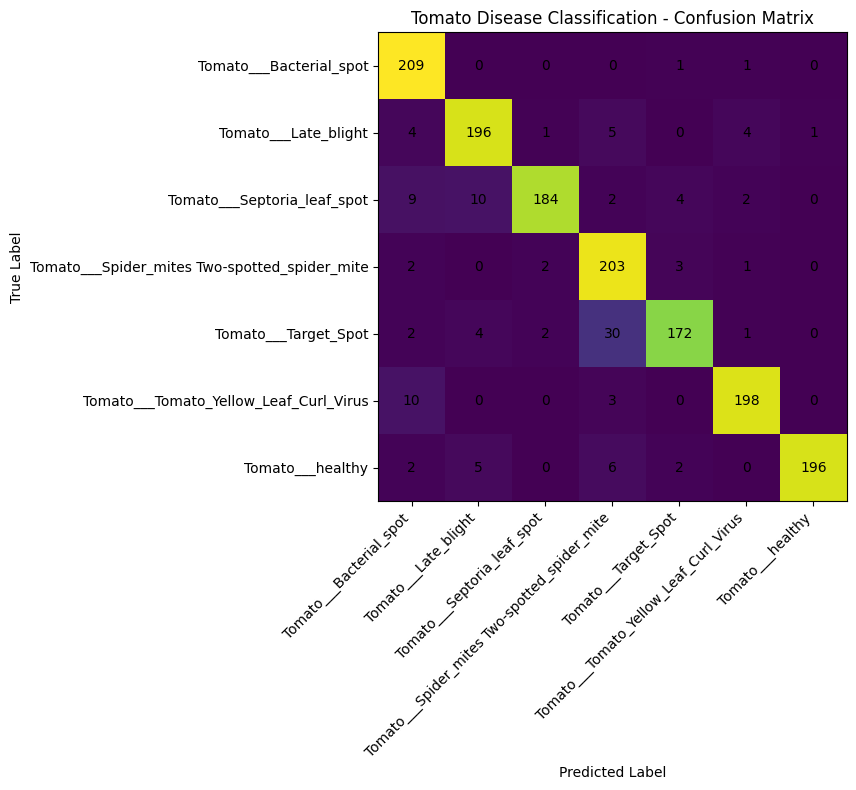

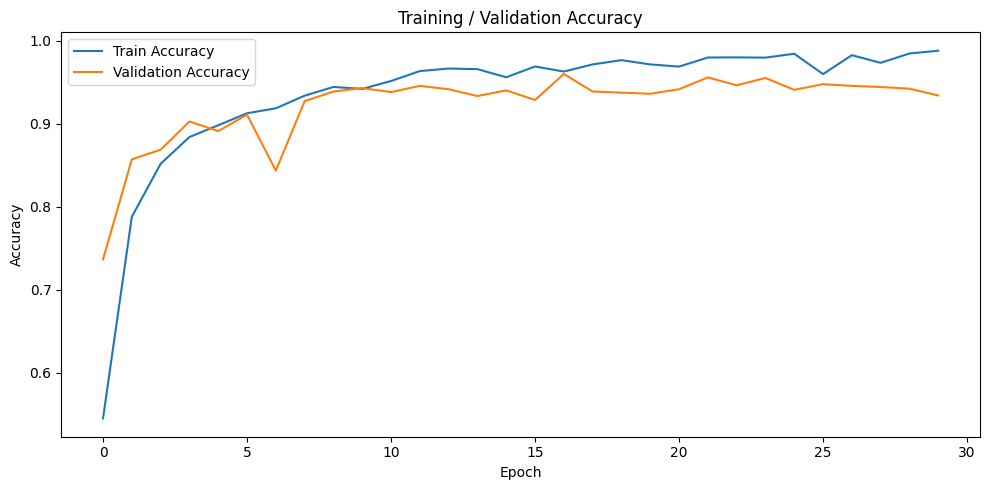

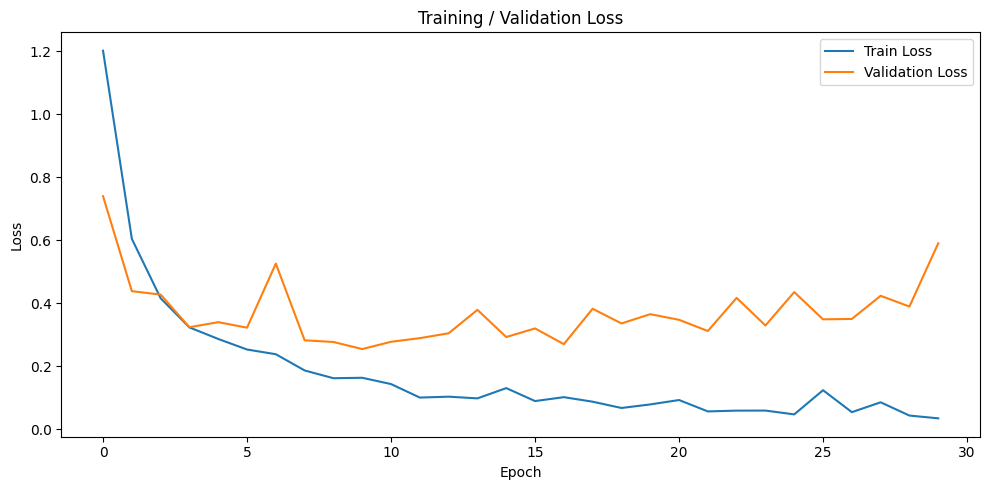


평가 완료!
Accuracy : 0.9194
Precision: 0.9250
Recall   : 0.9194
F1-score : 0.9196

저장 위치:
/root/Desktop/tomato_cnn_dropout05


In [ ]:
# ============================================
# Tomato CNN 평가 코드
# Accuracy / Precision / Recall / F1-score
# Confusion Matrix
# 학습곡선
# 결과를 바탕화면에 저장
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ============================================
# 1. 저장 폴더
# ============================================

SAVE_DIR = os.path.join(
    os.path.expanduser("~"),
    "Desktop",
    "tomato_cnn_dropout05"
)

os.makedirs(SAVE_DIR, exist_ok=True)

print("결과 저장 위치:")
print(SAVE_DIR)


# ============================================
# 2. Test 데이터 예측
# ============================================

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)


# ============================================
# 3. 주요 평가 지표
# ============================================

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\n========== 전체 평가 결과 ==========")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


# ============================================
# 4. 주요 지표 CSV 저장
# ============================================

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

metrics_df.to_csv(
    os.path.join(SAVE_DIR, "metrics.csv"),
    index=False,
    encoding="utf-8-sig"
)


# ============================================
# 5. 클래스별 평가
# ============================================

report_text = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print("\n========== Classification Report ==========")
print(report_text)


# CSV용
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

report_df.to_csv(
    os.path.join(SAVE_DIR, "classification_report.csv"),
    encoding="utf-8-sig"
)


# ============================================
# 6. Confusion Matrix
# ============================================

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\n========== Confusion Matrix ==========")
print(cm)


# ============================================
# 7. Confusion Matrix 이미지
# ============================================

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(cm)

# 숫자 표시
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))

ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

ax.set_title("Tomato Disease Classification - Confusion Matrix")

plt.tight_layout()

plt.savefig(
    os.path.join(SAVE_DIR, "confusion_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================
# 8. Accuracy 학습 곡선
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training / Validation Accuracy")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(SAVE_DIR, "accuracy_curve.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================
# 9. Loss 학습 곡선
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(SAVE_DIR, "loss_curve.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================
# 10. TXT 파일 저장
# ============================================

with open(
    os.path.join(SAVE_DIR, "evaluation_result.txt"),
    "w",
    encoding="utf-8"
) as f:

    f.write("Tomato Leaf Disease Classification\n")
    f.write("====================================\n\n")

    f.write(f"Accuracy : {accuracy:.4f}\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall   : {recall:.4f}\n")
    f.write(f"F1-score : {f1:.4f}\n\n")

    f.write("Classification Report\n")
    f.write("---------------------\n")

    f.write(report_text)


# ============================================
# 완료
# ============================================

print("\n====================================")
print("평가 완료!")
print("====================================")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print()
print("저장 위치:")
print(SAVE_DIR)

In [ ]:
from google.colab import files
import shutil
import os

SAVE_DIR = "/root/Desktop/tomato_cnn_dropout05"

# ZIP으로 묶기
zip_path = shutil.make_archive(
    "/content/tomato_cnn_dropout05",
    "zip",
    SAVE_DIR
)

# 내 컴퓨터로 다운로드
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

과적합 발생으로 베스트 저장을위한 재학습

In [ ]:
# ============================================
# Keras CNN 모델 생성 및 학습 - Best Model 저장 버전
# ============================================

from tensorflow.keras import layers, models
import tensorflow as tf
import os

# --------------------------------------------
# 1. 모델 생성
# --------------------------------------------

model = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    # 이미지 정규화
    layers.Rescaling(1./255),

    # CNN Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # CNN Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # CNN Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Classification
    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    # 과적합 완화
    layers.Dropout(0.5),

    # 7개 클래스
    layers.Dense(NUM_CLASSES, activation="softmax")
])


# --------------------------------------------
# 2. 컴파일
# --------------------------------------------

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# --------------------------------------------
# 3. Best 모델 저장 설정
# --------------------------------------------

BEST_MODEL_PATH = "/content/best_tomato_cnn_dropout05.keras"

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    BEST_MODEL_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)


# --------------------------------------------
# 4. 모델 구조 확인
# --------------------------------------------

model.summary()


# --------------------------------------------
# 5. 학습
# --------------------------------------------

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[checkpoint]
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,543 (12.61 MB)

 Trainable params: 3,305,543 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3857 - loss: 1.5749
Epoch 1: val_accuracy improved from None to 0.81973, saving model to /content/best_tomato_cnn_dropout05.keras

Epoch 1: finished saving model to /content/best_tomato_cnn_dropout05.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - accuracy: 0.5421 - loss: 1.2090 - val_accuracy: 0.8197 - val_loss: 0.5467
Epoch 2/30
213/215 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7726 - loss: 0.6607
Epoch 2: val_accuracy improved from 0.81973 to 0.84558, saving model to /content/best_tomato_cnn_dropout05.keras

Epoch 2: finished saving model to /content/best_tomato_cnn_dropout05.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.7893 - loss: 0.6046 - val_accuracy: 0.8456 - val_loss: 0.4804
Epoch 3/30
214/215 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8270 - loss: 0.4966
Epoch 3: val_accuracy did not improve from 0.84558
215/215 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.8446 - loss: 0.4523

모델 불러오기

In [ ]:
best_model = tf.keras.models.load_model(
    "/content/best_tomato_cnn_dropout05.keras"
)

평가

결과 저장 위치:
/root/Desktop/best_tomato_cnn_dropout05

========== 전체 평가 결과 ==========
Accuracy : 0.9472
Precision: 0.9474
Recall   : 0.9472
F1-score : 0.9470

========== Classification Report ==========
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.95      0.98      0.96       211
                         Tomato___Late_blight       0.93      0.95      0.94       211
                  Tomato___Septoria_leaf_spot       0.95      0.92      0.94       211
Tomato___Spider_mites Two-spotted_spider_mite       0.92      0.95      0.93       211
                         Tomato___Target_Spot       0.95      0.88      0.91       211
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.94      0.97      0.95       211
                             Tomato___healthy       0.99      0.99      0.99       211

                                     accuracy                           0.95      1477
                

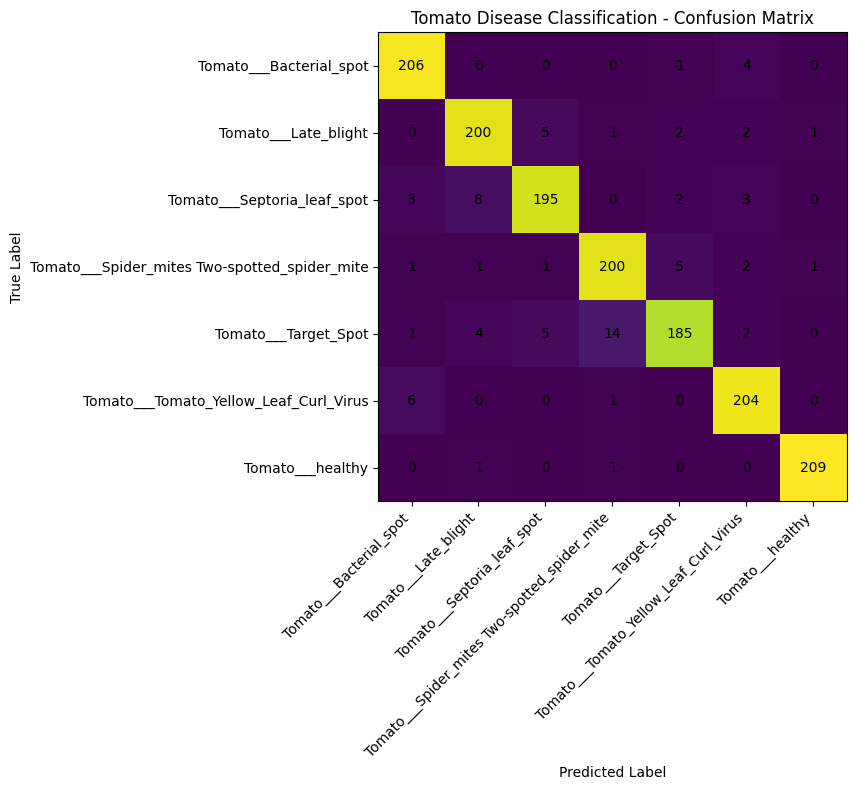

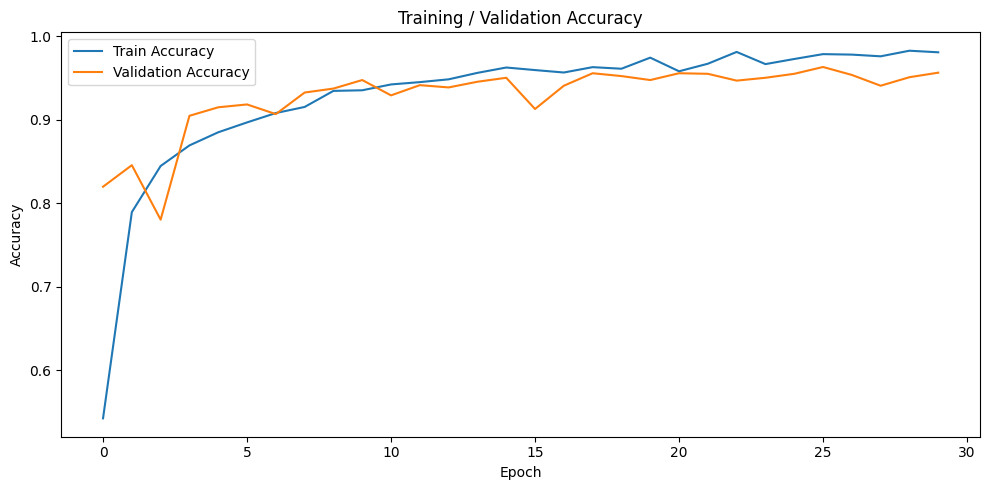

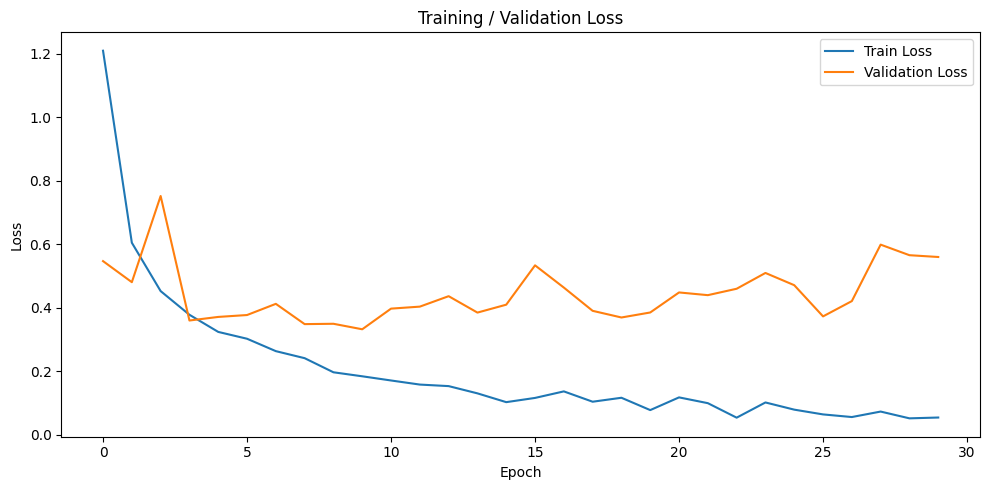


평가 완료!
Accuracy : 0.9472
Precision: 0.9474
Recall   : 0.9472
F1-score : 0.9470

저장 위치:
/root/Desktop/best_tomato_cnn_dropout05


In [ ]:
# ============================================
# Tomato CNN 평가 코드
# Accuracy / Precision / Recall / F1-score
# Confusion Matrix
# 학습곡선
# 결과를 바탕화면에 저장
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ============================================
# 1. 저장 폴더
# ============================================

SAVE_DIR = os.path.join(
    os.path.expanduser("~"),
    "Desktop",
    "best_tomato_cnn_dropout05"
)

os.makedirs(SAVE_DIR, exist_ok=True)

print("결과 저장 위치:")
print(SAVE_DIR)


# ============================================
# 2. Test 데이터 예측
# ============================================

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = best_model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)


# ============================================
# 3. 주요 평가 지표
# ============================================

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\n========== 전체 평가 결과 ==========")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


# ============================================
# 4. 주요 지표 CSV 저장
# ============================================

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

metrics_df.to_csv(
    os.path.join(SAVE_DIR, "metrics.csv"),
    index=False,
    encoding="utf-8-sig"
)


# ============================================
# 5. 클래스별 평가
# ============================================

report_text = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print("\n========== Classification Report ==========")
print(report_text)


# CSV용
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

report_df.to_csv(
    os.path.join(SAVE_DIR, "classification_report.csv"),
    encoding="utf-8-sig"
)


# ============================================
# 6. Confusion Matrix
# ============================================

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\n========== Confusion Matrix ==========")
print(cm)


# ============================================
# 7. Confusion Matrix 이미지
# ============================================

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(cm)

# 숫자 표시
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))

ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

ax.set_title("Tomato Disease Classification - Confusion Matrix")

plt.tight_layout()

plt.savefig(
    os.path.join(SAVE_DIR, "confusion_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================
# 8. Accuracy 학습 곡선
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training / Validation Accuracy")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(SAVE_DIR, "accuracy_curve.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================
# 9. Loss 학습 곡선
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(SAVE_DIR, "loss_curve.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================
# 10. TXT 파일 저장
# ============================================

with open(
    os.path.join(SAVE_DIR, "evaluation_result.txt"),
    "w",
    encoding="utf-8"
) as f:

    f.write("Tomato Leaf Disease Classification\n")
    f.write("====================================\n\n")

    f.write(f"Accuracy : {accuracy:.4f}\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall   : {recall:.4f}\n")
    f.write(f"F1-score : {f1:.4f}\n\n")

    f.write("Classification Report\n")
    f.write("---------------------\n")

    f.write(report_text)


# ============================================
# 완료
# ============================================

print("\n====================================")
print("평가 완료!")
print("====================================")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print()
print("저장 위치:")
print(SAVE_DIR)

In [ ]:
# ============================================
# 평가 결과 ZIP으로 묶어서 컴퓨터에 저장
# ============================================

from google.colab import files
import shutil
import os

# 현재 평가 결과 폴더
SAVE_DIR = "/root/Desktop/best_tomato_cnn_dropout05"

# ZIP 파일 생성
ZIP_PATH = shutil.make_archive(
    "/content/best_tomato_cnn_dropout05",
    "zip",
    SAVE_DIR
)

print("ZIP 생성 완료!")
print(ZIP_PATH)

# 컴퓨터로 다운로드
files.download(ZIP_PATH)

ZIP 생성 완료!
/content/best_tomato_cnn_dropout05.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

pytorch cnn

In [ ]:
# ============================================
# PyTorch CNN 모델 생성 및 학습
# Keras CNN과 동일 조건 비교
# ============================================

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader


# ============================================
# 1. 기본 설정
# ============================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("사용 장치:", device)


# ============================================
# 2. 경로 설정
# ============================================

DATA_DIR = "/content/tomato_dataset_clean"

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "val")
TEST_DIR  = os.path.join(DATA_DIR, "test")


# ============================================
# 3. 이미지 전처리
# ============================================
# Keras와 동일하게 128x128
# 정규화는 0~1 범위로만 변환
# 데이터 증강 없음
# ============================================

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])


# ============================================
# 4. Dataset
# ============================================

train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=transform
)


# ============================================
# 5. DataLoader
# ============================================

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)


# ============================================
# 6. 클래스 확인
# ============================================

class_names = train_dataset.classes
NUM_CLASSES = len(class_names)

print("클래스:", class_names)
print("클래스 수:", NUM_CLASSES)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))


# ============================================
# 7. CNN 모델
# Keras CNN과 동일한 구조
# ============================================

class TomatoCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(

            # CNN Block 1
            nn.Conv2d(3, 32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # CNN Block 2
            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # CNN Block 3
            nn.Conv2d(64, 128, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(

            # Keras Flatten
            nn.Flatten(),

            # Keras Dense(128)
            nn.Linear(128 * 14 * 14, 128),

            nn.ReLU(),

            # Keras Dropout(0.5)
            nn.Dropout(0.5),

            # Output 7
            nn.Linear(128, num_classes)
        )


    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


# 모델 생성
model = TomatoCNN(NUM_CLASSES).to(device)


# ============================================
# 8. Loss / Optimizer
# ============================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


# ============================================
# 9. Best 모델 저장 경로
# ============================================

BEST_MODEL_PATH = "/content/best_tomato_pytorch_cnn.pth"

best_val_accuracy = 0.0
best_epoch = 0


# ============================================
# 10. 학습
# ============================================

EPOCHS = 30

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []


for epoch in range(EPOCHS):

    # ----------------------------------------
    # Train
    # ----------------------------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


    train_loss = running_loss / len(train_dataset)
    train_accuracy = correct / total


    # ----------------------------------------
    # Validation
    # ----------------------------------------

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()


    val_loss = val_running_loss / len(val_dataset)
    val_accuracy = val_correct / val_total


    # ----------------------------------------
    # 기록
    # ----------------------------------------

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)


    # ----------------------------------------
    # 출력
    # ----------------------------------------

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )


    # ----------------------------------------
    # Best 모델 저장
    # ----------------------------------------

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print(
            f"  → Best 모델 저장! "
            f"Val Accuracy: {best_val_accuracy:.4f}"
        )


# ============================================
# 11. 학습 완료
# ============================================

print("\n====================================")
print("PyTorch CNN 학습 완료!")
print("====================================")

print(f"Best Epoch       : {best_epoch}")
print(f"Best Val Accuracy: {best_val_accuracy:.4f}")
print(f"모델 저장 위치   : {BEST_MODEL_PATH}")

사용 장치: cuda
클래스: ['Tomato___Bacterial_spot', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___healthy']
클래스 수: 7
Train: 6853
Validation: 1470
Test: 1477
Epoch [01/30] Train Loss: 1.1586 Train Acc: 0.5641 Val Loss: 0.6671 Val Acc: 0.7585
  → Best 모델 저장! Val Accuracy: 0.7585
Epoch [02/30] Train Loss: 0.6329 Train Acc: 0.7719 Val Loss: 0.4098 Val Acc: 0.8578
  → Best 모델 저장! Val Accuracy: 0.8578
Epoch [03/30] Train Loss: 0.4689 Train Acc: 0.8320 Val Loss: 0.3710 Val Acc: 0.8796
  → Best 모델 저장! Val Accuracy: 0.8796
Epoch [04/30] Train Loss: 0.3938 Train Acc: 0.8624 Val Loss: 0.2845 Val Acc: 0.9184
  → Best 모델 저장! Val Accuracy: 0.9184
Epoch [05/30] Train Loss: 0.3266 Train Acc: 0.8852 Val Loss: 0.2757 Val Acc: 0.9252
  → Best 모델 저장! Val Accuracy: 0.9252
Epoch [06/30] Train Loss: 0.2734 Train Acc: 0.9049 Val Loss: 0.2881 Val Acc: 0.9272
  → Best 모델 저장! Val Accurac

베스트 불러와서 평가

Best Model 불러오기 완료
Best Epoch       : 29
Best Val Accuracy: 0.9565

PyTorch CNN Test 결과
Accuracy : 0.9411
Precision: 0.9419
Recall   : 0.9411
F1-score : 0.9412
Test images: 1477

Classification Report
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot     0.9238    0.9763    0.9493       211
                         Tomato___Late_blight     0.9522    0.9431    0.9476       211
                  Tomato___Septoria_leaf_spot     0.9481    0.9526    0.9504       211
Tomato___Spider_mites Two-spotted_spider_mite     0.9043    0.8957    0.9000       211
                         Tomato___Target_Spot     0.8945    0.9242    0.9091       211
       Tomato___Tomato_Yellow_Leaf_Curl_Virus     0.9750    0.9242    0.9489       211
                             Tomato___healthy     0.9951    0.9716    0.9832       211

                                     accuracy                         0.9411      1477
              

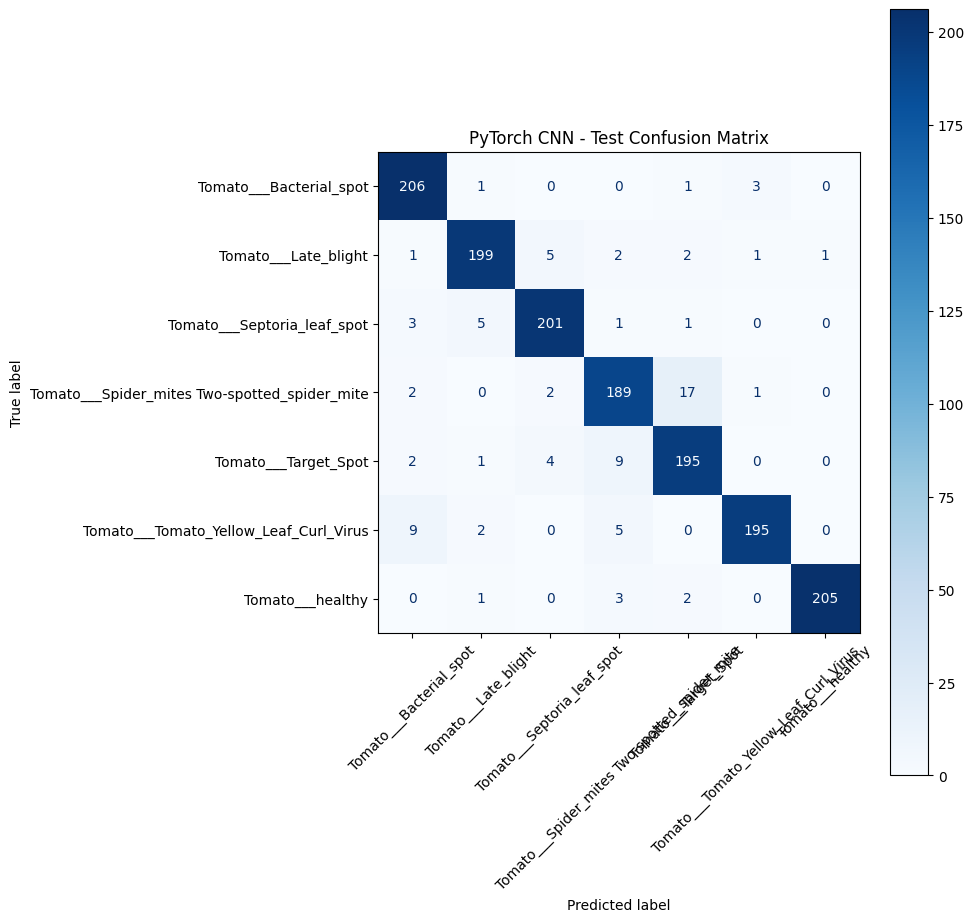

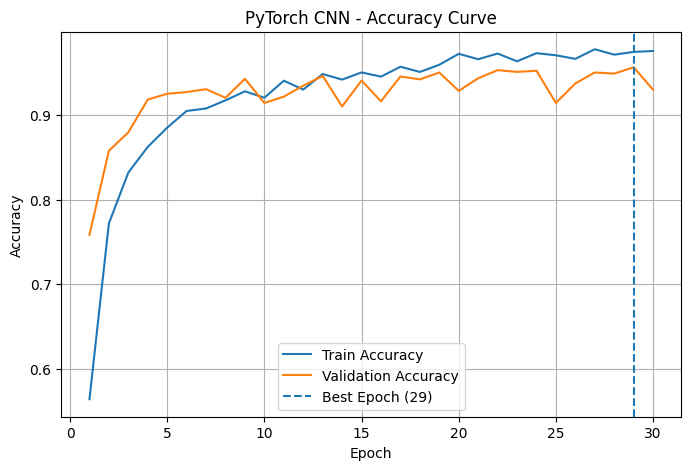

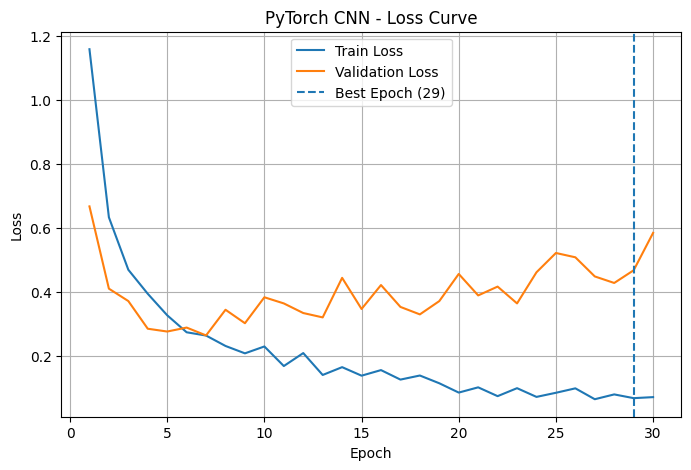

In [ ]:
# ==========================================
# PyTorch CNN - Best Model Test Evaluation
# ==========================================

import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------
# 1. Best Model 불러오기
# ------------------------------------------

model.load_state_dict(torch.load(
    "/content/best_tomato_pytorch_cnn.pth",
    map_location=device
))

model.eval()

print("Best Model 불러오기 완료")
print(f"Best Epoch       : {best_epoch}")
print(f"Best Val Accuracy: {best_val_accuracy:.4f}")


# ------------------------------------------
# 2. Test 데이터 예측
# ------------------------------------------

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)


# ------------------------------------------
# 3. 평가 지표 계산
# ------------------------------------------

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

test_precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)


print("\n====================================")
print("PyTorch CNN Test 결과")
print("====================================")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")
print(f"Test images: {len(all_labels)}")


# ------------------------------------------
# 4. Classification Report
# ------------------------------------------

print("\n====================================")
print("Classification Report")
print("====================================")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


# ------------------------------------------
# 5. Confusion Matrix
# ------------------------------------------

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("\n====================================")
print("Confusion Matrix")
print("====================================")

print(cm)


# ------------------------------------------
# 6. Confusion Matrix 시각화
# ------------------------------------------

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("PyTorch CNN - Test Confusion Matrix")
plt.tight_layout()
plt.show()


# ------------------------------------------
# 7. Learning Curve
# ------------------------------------------

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_accuracies,
    label="Train Accuracy"
)

plt.plot(
    epochs_range,
    val_accuracies,
    label="Validation Accuracy"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("PyTorch CNN - Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------
# 8. Loss Curve
# ------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_losses,
    label="Train Loss"
)

plt.plot(
    epochs_range,
    val_losses,
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PyTorch CNN - Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ==========================================
# PyTorch CNN - 결과물 전체 저장 및 ZIP 다운로드
# ==========================================

import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# ------------------------------------------
# 1. 결과 저장 폴더
# ------------------------------------------

SAVE_DIR = "/content/best_tomato_pytorch_cnn_results"

# 기존 폴더가 있으면 삭제 후 새로 생성
if os.path.exists(SAVE_DIR):
    shutil.rmtree(SAVE_DIR)

os.makedirs(SAVE_DIR, exist_ok=True)


# ------------------------------------------
# 2. Best Model 복사
# ------------------------------------------

shutil.copy(
    "/content/best_tomato_pytorch_cnn.pth",
    os.path.join(SAVE_DIR, "best_tomato_pytorch_cnn.pth")
)


# ------------------------------------------
# 3. 평가 결과 TXT 저장
# ------------------------------------------

report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    digits=4,
    zero_division=0
)

result_text = f"""
====================================
PyTorch CNN Test 결과
====================================

Best Epoch       : {best_epoch}
Best Val Accuracy: {best_val_accuracy:.4f}

Test images      : {len(all_labels)}

Accuracy         : {test_accuracy:.4f}
Precision        : {test_precision:.4f}
Recall           : {test_recall:.4f}
F1-score         : {test_f1:.4f}


====================================
Classification Report
====================================

{report}


====================================
Confusion Matrix
====================================

{cm}
"""

with open(
    os.path.join(SAVE_DIR, "test_results.txt"),
    "w",
    encoding="utf-8"
) as f:
    f.write(result_text)


# ------------------------------------------
# 4. Confusion Matrix 이미지 저장
# ------------------------------------------

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("PyTorch CNN - Test Confusion Matrix")
plt.tight_layout()

plt.savefig(
    os.path.join(SAVE_DIR, "confusion_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ------------------------------------------
# 5. Accuracy Curve 저장
# ------------------------------------------

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_accuracies,
    label="Train Accuracy"
)

plt.plot(
    epochs_range,
    val_accuracies,
    label="Validation Accuracy"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("PyTorch CNN - Accuracy Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(SAVE_DIR, "accuracy_curve.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ------------------------------------------
# 6. Loss Curve 저장
# ------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_losses,
    label="Train Loss"
)

plt.plot(
    epochs_range,
    val_losses,
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PyTorch CNN - Loss Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(SAVE_DIR, "loss_curve.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ------------------------------------------
# 7. Confusion Matrix 숫자 CSV 저장
# ------------------------------------------

import pandas as pd

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cm_df.to_csv(
    os.path.join(SAVE_DIR, "confusion_matrix.csv"),
    encoding="utf-8-sig"
)


# ------------------------------------------
# 8. 전체 결과 CSV 저장
# ------------------------------------------

metrics_df = pd.DataFrame({
    "Metric": [
        "Best Epoch",
        "Best Val Accuracy",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1-score",
        "Test Images"
    ],
    "Value": [
        best_epoch,
        best_val_accuracy,
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        len(all_labels)
    ]
})

metrics_df.to_csv(
    os.path.join(SAVE_DIR, "metrics.csv"),
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------
# 9. 학습 기록 CSV 저장
# ------------------------------------------

history_df = pd.DataFrame({
    "Epoch": list(epochs_range),
    "Train Loss": train_losses,
    "Train Accuracy": train_accuracies,
    "Validation Loss": val_losses,
    "Validation Accuracy": val_accuracies
})

history_df.to_csv(
    os.path.join(SAVE_DIR, "training_history.csv"),
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------
# 10. ZIP 압축
# ------------------------------------------

ZIP_PATH = shutil.make_archive(
    "/content/best_tomato_pytorch_cnn_results",
    "zip",
    SAVE_DIR
)

print("====================================")
print("결과 저장 완료!")
print("====================================")
print(f"폴더: {SAVE_DIR}")
print(f"ZIP : {ZIP_PATH}")


# ------------------------------------------
# 11. 데스크탑으로 다운로드
# ------------------------------------------

from google.colab import files

files.download(ZIP_PATH)

결과 저장 완료!
폴더: /content/best_tomato_pytorch_cnn_results
ZIP : /content/best_tomato_pytorch_cnn_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

TensorFlow version: 2.20.0
Found 6853 files belonging to 7 classes.
Found 1470 files belonging to 7 classes.
Found 1477 files belonging to 7 classes.

클래스:
['Tomato___Bacterial_spot', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___healthy']
클래스 수: 7


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │    12,583,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,624,775 (48.16 MB)

 Trainable params: 12,624,775 (48.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1584 - loss: 3.3274
Epoch 1: val_accuracy improved from None to 0.17959, saving model to /content/best_tomato_dnn.keras

Epoch 1: finished saving model to /content/best_tomato_dnn.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.1557 - loss: 2.3180 - val_accuracy: 0.1796 - val_loss: 1.9230
Epoch 2/30
214/215 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1533 - loss: 1.9285
Epoch 2: val_accuracy did not improve from 0.17959
215/215 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.1572 - loss: 1.9297 - val_accuracy: 0.1517 - val_loss: 1.9287
Epoch 3/30
213/215 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1530 - loss: 1.9239
Epoch 3: val_accuracy did not improve from 0.17959
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.1526 - loss: 1.9238 - val_accuracy: 0.1517 - val_loss: 1.9285
Epoch 4/30
213/215 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1452 - loss: 1.9212
Epoch 4: val_accuracy did not

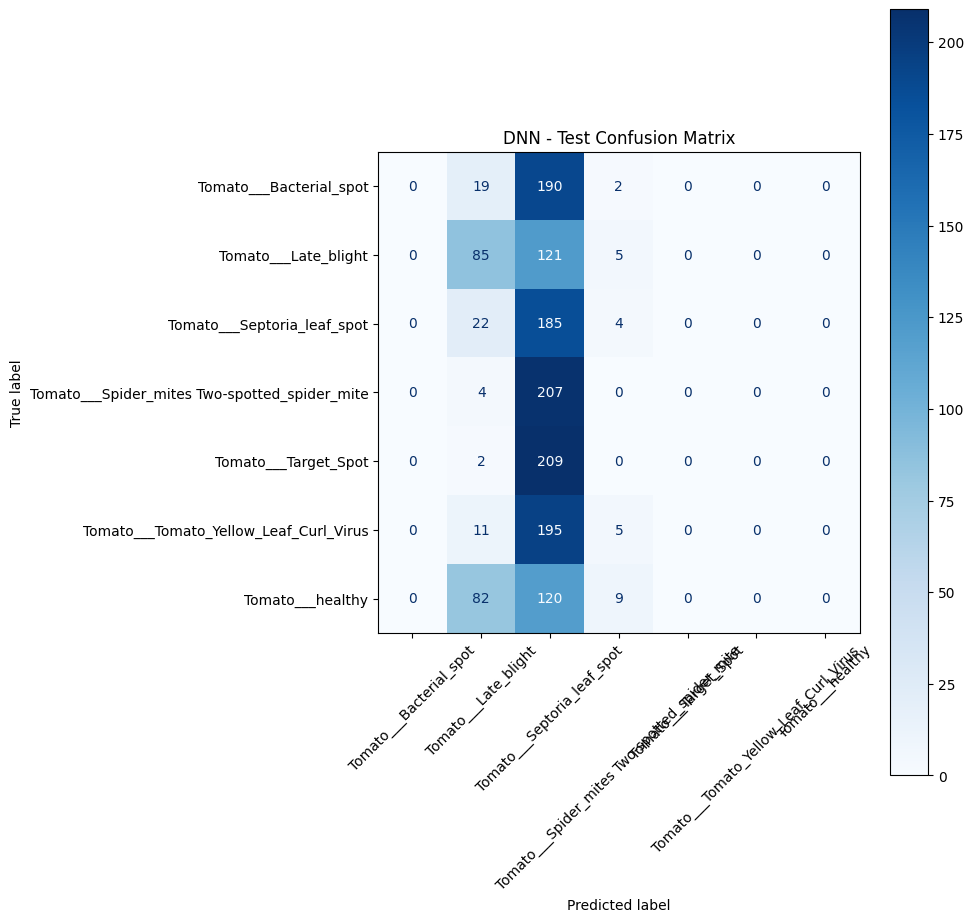

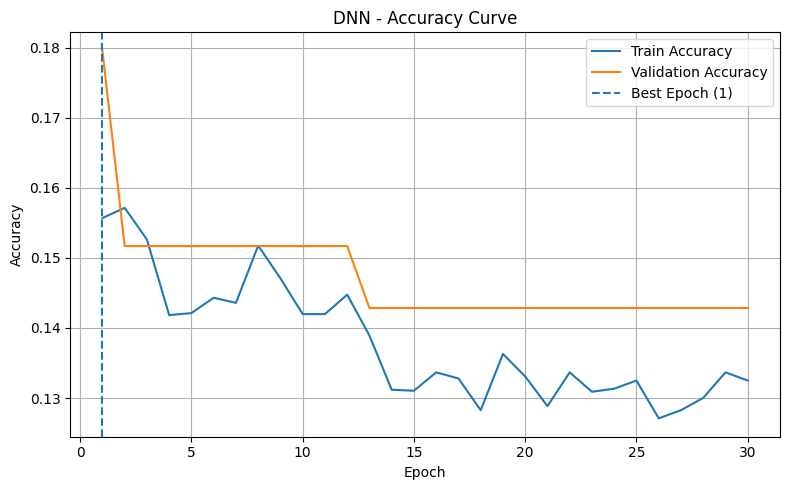

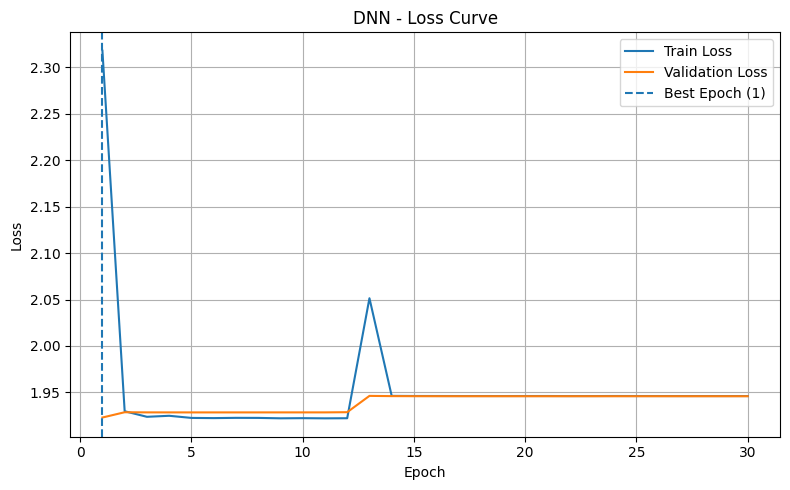


DNN 결과 저장 완료
결과 폴더 : /content/best_tomato_dnn_results
ZIP 파일  : /content/best_tomato_dnn_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================
# ANN / DNN Baseline
# Tomato Leaf Disease Classification
# ==========================================

import os
import random
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ==========================================
# 1. 기본 설정
# ==========================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = "/content/tomato_dataset_clean"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 30
NUM_CLASSES = 7

print("TensorFlow version:", tf.__version__)

# ==========================================
# 2. 데이터 불러오기
# ==========================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

print("\n클래스:")
print(class_names)
print("클래스 수:", len(class_names))


# ==========================================
# 3. DNN 모델
# ==========================================
#
# 입력 이미지
# 128 x 128 x 3
#
#       ↓ Flatten
#
# 49,152
#
#       ↓ Dense 256
#
# 256
#
#       ↓ Dense 128
#
# 128
#
#       ↓ Dense 64
#
# 64
#
#       ↓ Dropout 0.5
#
#       ↓ Output 7
#
# ==========================================

model = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    # 픽셀값 0~255 → 0~1
    layers.Rescaling(1./255),

    # 이미지 펼치기
    layers.Flatten(),

    layers.Dense(256, activation="relu"),

    layers.Dense(128, activation="relu"),

    layers.Dense(64, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation="softmax")
])


# ==========================================
# 4. 모델 컴파일
# ==========================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# ==========================================
# 5. Best Model 저장
# ==========================================

BEST_MODEL_PATH = "/content/best_tomato_dnn.keras"

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    BEST_MODEL_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)


# ==========================================
# 6. 학습
# ==========================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint]
)


# ==========================================
# 7. Best Epoch 확인
# ==========================================

best_epoch = np.argmax(
    history.history["val_accuracy"]
) + 1

best_val_accuracy = max(
    history.history["val_accuracy"]
)

print("\n====================================")
print("DNN 학습 완료")
print("====================================")
print(f"Best Epoch       : {best_epoch}")
print(f"Best Val Accuracy: {best_val_accuracy:.4f}")
print(f"모델 저장 위치   : {BEST_MODEL_PATH}")


# ==========================================
# 8. Best Model 불러오기
# ==========================================

best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)

print("\nBest DNN 모델 불러오기 완료")


# ==========================================
# 9. Test 데이터 예측
# ==========================================

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = best_model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

y_true = np.array(y_true)
y_pred = np.array(y_pred)


# ==========================================
# 10. 평가 지표
# ==========================================

test_accuracy = accuracy_score(
    y_true,
    y_pred
)

test_precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)


print("\n====================================")
print("DNN Test 결과")
print("====================================")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")
print(f"Test images: {len(y_true)}")


# ==========================================
# 11. Classification Report
# ==========================================

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("\n====================================")
print("Classification Report")
print("====================================")
print(report)


# ==========================================
# 12. Confusion Matrix
# ==========================================

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\n====================================")
print("Confusion Matrix")
print("====================================")
print(cm)


# ==========================================
# 13. 결과 저장 폴더
# ==========================================

SAVE_DIR = "/content/best_tomato_dnn_results"

if os.path.exists(SAVE_DIR):
    shutil.rmtree(SAVE_DIR)

os.makedirs(SAVE_DIR, exist_ok=True)


# ==========================================
# 14. 모델 저장
# ==========================================

shutil.copy(
    BEST_MODEL_PATH,
    os.path.join(
        SAVE_DIR,
        "best_tomato_dnn.keras"
    )
)


# ==========================================
# 15. Test 결과 TXT 저장
# ==========================================

result_text = f"""
====================================
Tomato Leaf Disease - DNN
====================================

Best Epoch        : {best_epoch}
Best Val Accuracy : {best_val_accuracy:.4f}

Test Images       : {len(y_true)}

Accuracy          : {test_accuracy:.4f}
Precision         : {test_precision:.4f}
Recall            : {test_recall:.4f}
F1-score          : {test_f1:.4f}


====================================
Classification Report
====================================

{report}


====================================
Confusion Matrix
====================================

{cm}
"""

with open(
    os.path.join(SAVE_DIR, "test_results.txt"),
    "w",
    encoding="utf-8"
) as f:
    f.write(result_text)


# ==========================================
# 16. Metrics CSV
# ==========================================

metrics_df = pd.DataFrame({
    "Metric": [
        "Best Epoch",
        "Best Val Accuracy",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1-score",
        "Test Images"
    ],
    "Value": [
        best_epoch,
        best_val_accuracy,
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        len(y_true)
    ]
})

metrics_df.to_csv(
    os.path.join(SAVE_DIR, "metrics.csv"),
    index=False,
    encoding="utf-8-sig"
)


# ==========================================
# 17. Training History CSV
# ==========================================

history_df = pd.DataFrame({
    "Epoch": range(1, EPOCHS + 1),
    "Train Loss": history.history["loss"],
    "Train Accuracy": history.history["accuracy"],
    "Validation Loss": history.history["val_loss"],
    "Validation Accuracy": history.history["val_accuracy"]
})

history_df.to_csv(
    os.path.join(SAVE_DIR, "training_history.csv"),
    index=False,
    encoding="utf-8-sig"
)


# ==========================================
# 18. Confusion Matrix CSV
# ==========================================

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cm_df.to_csv(
    os.path.join(
        SAVE_DIR,
        "confusion_matrix.csv"
    ),
    encoding="utf-8-sig"
)


# ==========================================
# 19. Confusion Matrix 이미지
# ==========================================

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("DNN - Test Confusion Matrix")
plt.tight_layout()

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ==========================================
# 20. Accuracy Curve
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    range(1, EPOCHS + 1),
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DNN - Accuracy Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "accuracy_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ==========================================
# 21. Loss Curve
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    history.history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DNN - Loss Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "loss_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ==========================================
# 22. ZIP 압축
# ==========================================

ZIP_PATH = shutil.make_archive(
    "/content/best_tomato_dnn_results",
    "zip",
    SAVE_DIR
)

print("\n====================================")
print("DNN 결과 저장 완료")
print("====================================")
print(f"결과 폴더 : {SAVE_DIR}")
print(f"ZIP 파일  : {ZIP_PATH}")


# ==========================================
# 23. 다운로드
# ==========================================

from google.colab import files

files.download(ZIP_PATH)

기존 DNN보다 단순화한 구조로 다시 돌리자.

TensorFlow version: 2.20.0
Found 6853 files belonging to 7 classes.
Found 1470 files belonging to 7 classes.
Found 1477 files belonging to 7 classes.

클래스:
['Tomato___Bacterial_spot', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___healthy']
클래스 수: 7
Train: 6853
Validation: 1470
Test: 1477


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,302,151 (24.04 MB)

 Trainable params: 6,302,151 (24.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1483 - loss: 3.1758
Epoch 1: val_accuracy improved from None to 0.14286, saving model to /content/best_tomato_dnn_simple.keras

Epoch 1: finished saving model to /content/best_tomato_dnn_simple.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.1436 - loss: 2.2524 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 2/30
214/215 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1377 - loss: 1.9461
Epoch 2: val_accuracy did not improve from 0.14286
215/215 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.1413 - loss: 1.9461 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 3/30
214/215 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1243 - loss: 1.9462
Epoch 3: val_accuracy did not improve from 0.14286
215/215 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.1272 - loss: 1.9461 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 4/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1315 - loss: 1.9461
Epoch 4: val_ac

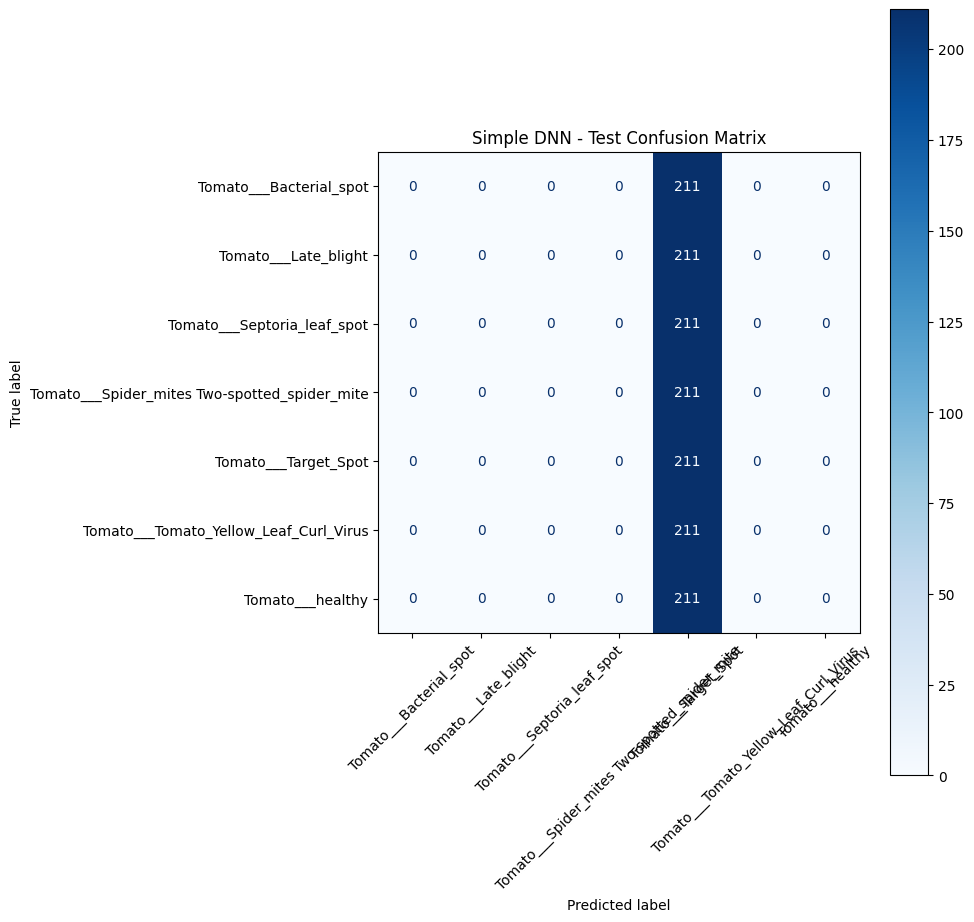

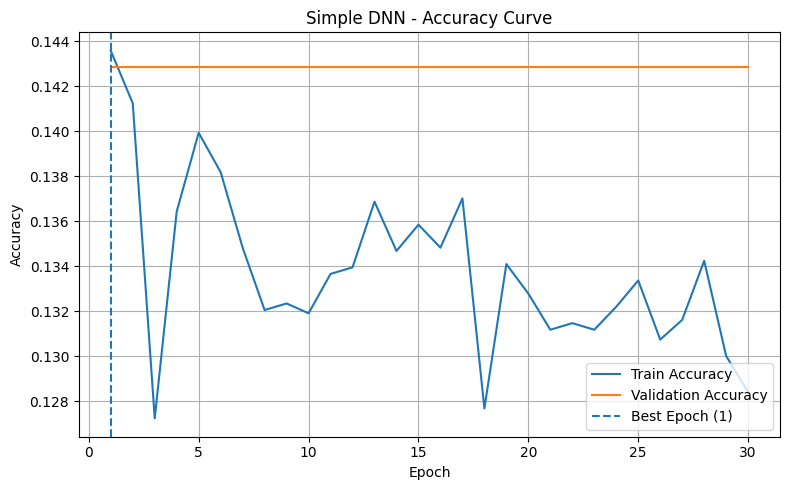

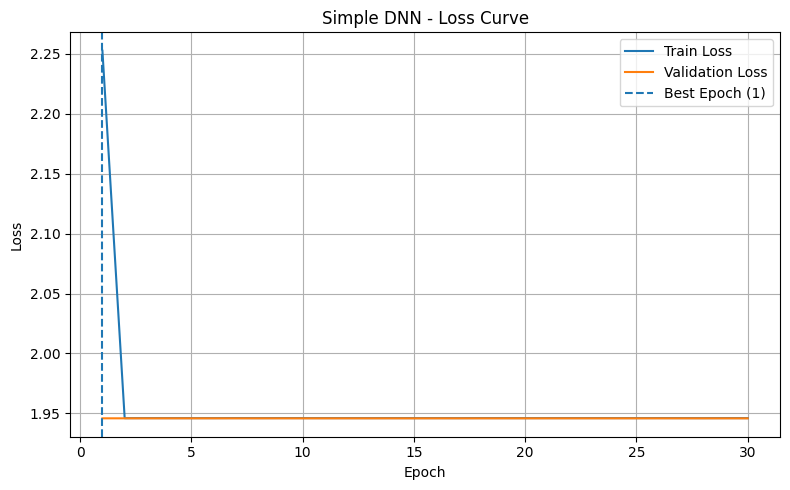


단순화 DNN 결과 저장 완료
결과 폴더 : /content/best_tomato_dnn_simple_results
ZIP 파일  : /content/best_tomato_dnn_simple_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================
# Simple DNN / ANN Baseline
# Tomato Leaf Disease Classification
# ==========================================

import os
import random
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ==========================================
# 1. 기본 설정
# ==========================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = "/content/tomato_dataset_clean"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 30
NUM_CLASSES = 7

print("TensorFlow version:", tf.__version__)


# ==========================================
# 2. 데이터 불러오기
# ==========================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

print("\n클래스:")
print(class_names)

print("클래스 수:", len(class_names))

print("Train:", sum(1 for _ in train_ds.unbatch()))
print("Validation:", sum(1 for _ in val_ds.unbatch()))
print("Test:", sum(1 for _ in test_ds.unbatch()))


# ==========================================
# 3. 단순화한 DNN 모델
# ==========================================
#
# 128 x 128 x 3
#       ↓
# Flatten
#       ↓
# 49,152
#       ↓
# Dense 128
#       ↓
# Dense 64
#       ↓
# Dense 32
#       ↓
# Dropout 0.5
#       ↓
# Output 7
#
# ==========================================

model = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    # 픽셀값 0~255 → 0~1
    layers.Rescaling(1./255),

    # 이미지 펼치기
    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dense(
        32,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])


# ==========================================
# 4. 모델 컴파일
# ==========================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ==========================================
# 5. 모델 구조 확인
# ==========================================

model.summary()


# ==========================================
# 6. Best Model 저장 설정
# ==========================================

BEST_MODEL_PATH = "/content/best_tomato_dnn_simple.keras"

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    BEST_MODEL_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)


# ==========================================
# 7. 학습
# ==========================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint]
)


# ==========================================
# 8. Best Epoch 확인
# ==========================================

best_epoch = np.argmax(
    history.history["val_accuracy"]
) + 1

best_val_accuracy = max(
    history.history["val_accuracy"]
)

print("\n====================================")
print("단순화 DNN 학습 완료")
print("====================================")

print(f"Best Epoch       : {best_epoch}")
print(f"Best Val Accuracy: {best_val_accuracy:.4f}")
print(f"모델 저장 위치   : {BEST_MODEL_PATH}")


# ==========================================
# 9. Best Model 불러오기
# ==========================================

best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)

print("\nBest DNN 모델 불러오기 완료")


# ==========================================
# 10. Test 데이터 예측
# ==========================================

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = best_model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

y_true = np.array(y_true)
y_pred = np.array(y_pred)


# ==========================================
# 11. 평가 지표
# ==========================================

test_accuracy = accuracy_score(
    y_true,
    y_pred
)

test_precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)


print("\n====================================")
print("단순화 DNN Test 결과")
print("====================================")

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")
print(f"Test images: {len(y_true)}")


# ==========================================
# 12. Classification Report
# ==========================================

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("\n====================================")
print("Classification Report")
print("====================================")

print(report)


# ==========================================
# 13. Confusion Matrix
# ==========================================

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\n====================================")
print("Confusion Matrix")
print("====================================")

print(cm)


# ==========================================
# 14. 결과 저장 폴더
# ==========================================

SAVE_DIR = "/content/best_tomato_dnn_simple_results"

if os.path.exists(SAVE_DIR):
    shutil.rmtree(SAVE_DIR)

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)


# ==========================================
# 15. Best Model 복사
# ==========================================

shutil.copy(
    BEST_MODEL_PATH,
    os.path.join(
        SAVE_DIR,
        "best_tomato_dnn_simple.keras"
    )
)


# ==========================================
# 16. Test 결과 TXT
# ==========================================

result_text = f"""
====================================
Tomato Leaf Disease - Simple DNN
====================================

Model Architecture
128x128x3
→ Flatten
→ Dense 128
→ Dense 64
→ Dense 32
→ Dropout 0.5
→ Output 7

Best Epoch        : {best_epoch}
Best Val Accuracy : {best_val_accuracy:.4f}

Test Images       : {len(y_true)}

Accuracy          : {test_accuracy:.4f}
Precision         : {test_precision:.4f}
Recall            : {test_recall:.4f}
F1-score          : {test_f1:.4f}


====================================
Classification Report
====================================

{report}


====================================
Confusion Matrix
====================================

{cm}
"""

with open(
    os.path.join(
        SAVE_DIR,
        "test_results.txt"
    ),
    "w",
    encoding="utf-8"
) as f:
    f.write(result_text)


# ==========================================
# 17. Metrics CSV
# ==========================================

metrics_df = pd.DataFrame({
    "Metric": [
        "Best Epoch",
        "Best Val Accuracy",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1-score",
        "Test Images"
    ],

    "Value": [
        best_epoch,
        best_val_accuracy,
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        len(y_true)
    ]
})

metrics_df.to_csv(
    os.path.join(
        SAVE_DIR,
        "metrics.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)


# ==========================================
# 18. Training History CSV
# ==========================================

history_df = pd.DataFrame({
    "Epoch": range(1, EPOCHS + 1),

    "Train Loss":
        history.history["loss"],

    "Train Accuracy":
        history.history["accuracy"],

    "Validation Loss":
        history.history["val_loss"],

    "Validation Accuracy":
        history.history["val_accuracy"]
})

history_df.to_csv(
    os.path.join(
        SAVE_DIR,
        "training_history.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)


# ==========================================
# 19. Confusion Matrix CSV
# ==========================================

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cm_df.to_csv(
    os.path.join(
        SAVE_DIR,
        "confusion_matrix.csv"
    ),
    encoding="utf-8-sig"
)


# ==========================================
# 20. Confusion Matrix 이미지
# ==========================================

fig, ax = plt.subplots(
    figsize=(10, 10)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title(
    "Simple DNN - Test Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ==========================================
# 21. Accuracy Curve
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    range(1, EPOCHS + 1),
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Simple DNN - Accuracy Curve"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "accuracy_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ==========================================
# 22. Loss Curve
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    history.history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Simple DNN - Loss Curve"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "loss_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ==========================================
# 23. ZIP 압축
# ==========================================

ZIP_PATH = shutil.make_archive(
    "/content/best_tomato_dnn_simple_results",
    "zip",
    SAVE_DIR
)

print("\n====================================")
print("단순화 DNN 결과 저장 완료")
print("====================================")

print(f"결과 폴더 : {SAVE_DIR}")
print(f"ZIP 파일  : {ZIP_PATH}")


# ==========================================
# 24. 다운로드
# ==========================================

from google.colab import files

files.download(ZIP_PATH)

pytorch dnn

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# =========================================================
# 1. 기본 설정
# =========================================================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

DATA_DIR = "/content/tomato_dataset_clean"

BATCH_SIZE = 32
EPOCHS = 30
LR = 0.001
IMG_SIZE = 64

# =========================================================
# 2. 데이터 전처리
#    - 증강 없음
#    - 64x64 Resize
#    - ToTensor() → 0~1
# =========================================================
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "train"),
    transform=transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "val"),
    transform=transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "test"),
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_dataset.classes
NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))


# =========================================================
# 3. DNN 모델
#    Flatten → Dense → Dense → Dense → Output
# =========================================================
class TomatoDNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(3 * IMG_SIZE * IMG_SIZE, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)


model = TomatoDNN(NUM_CLASSES).to(device)

print(model)


# =========================================================
# 4. Loss / Optimizer
# =========================================================
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)


# =========================================================
# 5. 학습 기록
# =========================================================
train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_accuracy = 0.0
best_epoch = 0

BEST_MODEL_PATH = "/content/best_tomato_pytorch_dnn.pth"


# =========================================================
# 6. 학습
# =========================================================
for epoch in range(EPOCHS):

    # -------------------------
    # Train
    # -------------------------
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total


    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total


    # 기록
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)


    # Best Model 저장
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        torch.save(model.state_dict(), BEST_MODEL_PATH)


    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )


print("\n===================================")
print("Best Epoch:", best_epoch)
print("Best Val Accuracy:", f"{best_val_accuracy:.4f}")
print("Best Model:", BEST_MODEL_PATH)
print("===================================")

Device: cuda
Classes: ['Tomato___Bacterial_spot', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___healthy']
Train: 6853
Validation: 1470
Test: 1477
TomatoDNN(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12288, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=32, bias=True)
    (6): ReLU()
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=32, out_features=7, bias=True)
  )
)
Epoch [01/30] Train Loss: 1.8536 Train Acc: 0.2336 | Val Loss: 1.6110 Val Acc: 0.4088
Epoch [02/30] Train Loss: 1.5347 Train Acc: 0.3905 | Val Loss: 1.3662 Val Acc: 0.4789
Epoch [03/30] Train Loss: 1.3774 Train Acc: 0.4805 | Val Loss: 1.2198 Val Acc: 0.5673
Epoch [04/30] Train Loss: 1.2912 Train Acc: 0.5

In [ ]:
# =========================================================
# Best PyTorch DNN 불러오기
# =========================================================

model.load_state_dict(
    torch.load(BEST_MODEL_PATH, map_location=device)
)

model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


test_accuracy = correct / total

print("===================================")
print("PyTorch DNN Test Accuracy")
print(f"{test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("Test Images:", total)
print("===================================")

PyTorch DNN Test Accuracy
0.7434 (74.34%)
Test Images: 1477


PyTorch DNN Test Results
Accuracy : 0.7434
Precision: 0.7556
Recall   : 0.7434
F1-score : 0.7401
Test images: 1477

Classification Report
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot     0.7328    0.8057    0.7675       211
                         Tomato___Late_blight     0.8758    0.6351    0.7363       211
                  Tomato___Septoria_leaf_spot     0.7261    0.5403    0.6196       211
Tomato___Spider_mites Two-spotted_spider_mite     0.6591    0.8246    0.7326       211
                         Tomato___Target_Spot     0.7071    0.6635    0.6846       211
       Tomato___Tomato_Yellow_Leaf_Curl_Virus     0.6947    0.9384    0.7984       211
                             Tomato___healthy     0.8936    0.7962    0.8421       211

                                     accuracy                         0.7434      1477
                                    macro avg     0.7556    0.7434    0.7401 

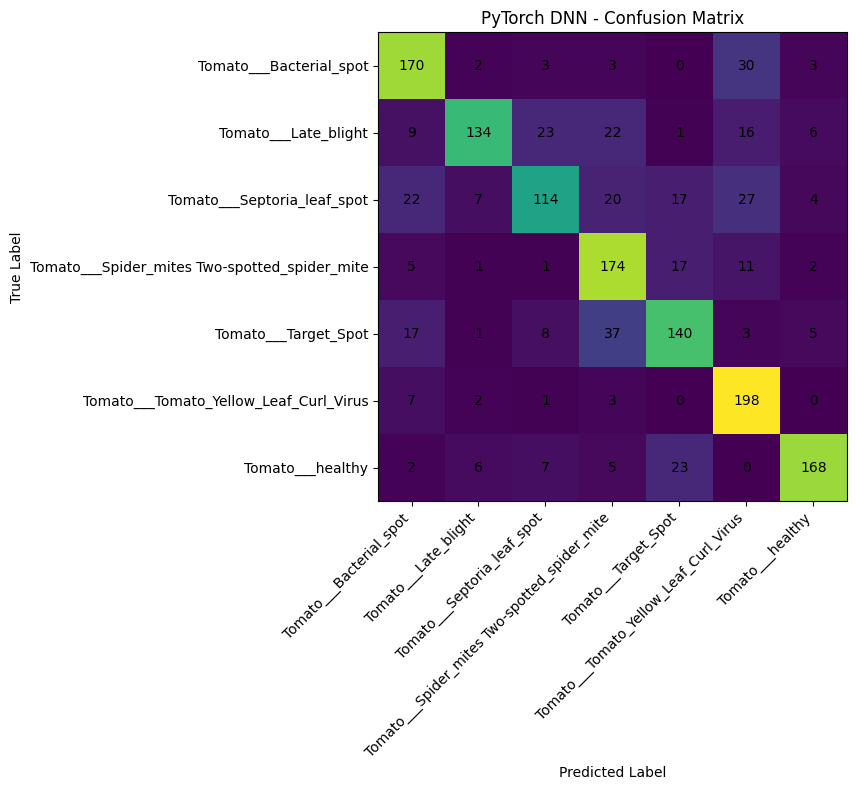

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


저장 완료:
/content/best_tomato_pytorch_dnn_results


In [ ]:
# =========================================================
# PyTorch DNN 상세 평가
# =========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Best Model 다시 불러오기
model.load_state_dict(
    torch.load(BEST_MODEL_PATH, map_location=device)
)

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# =========================================================
# 1. 기본 평가 지표
# =========================================================

accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

print("===================================")
print("PyTorch DNN Test Results")
print("===================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"Test images: {len(all_labels)}")


# =========================================================
# 2. Classification Report
# =========================================================

print("\n===================================")
print("Classification Report")
print("===================================")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


# =========================================================
# 3. Confusion Matrix
# =========================================================

cm = confusion_matrix(
    all_labels,
    all_preds
)

print("\n===================================")
print("Confusion Matrix")
print("===================================")

print(cm)


# =========================================================
# 4. Confusion Matrix 시각화
# =========================================================

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.title("PyTorch DNN - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(class_names)),
    class_names
)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

CM_PATH = "/content/pytorch_dnn_confusion_matrix.png"

plt.savefig(
    CM_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# 5. 결과 저장
# =========================================================

SAVE_DIR = "/content/best_tomato_pytorch_dnn_results"

os.makedirs(SAVE_DIR, exist_ok=True)


# Metrics
metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

metrics_df.to_csv(
    os.path.join(SAVE_DIR, "metrics.csv"),
    index=False
)


# Classification Report
report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4,
    zero_division=0
)

with open(
    os.path.join(SAVE_DIR, "classification_report.txt"),
    "w",
    encoding="utf-8"
) as f:
    f.write(report)


# Confusion Matrix CSV
cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cm_df.to_csv(
    os.path.join(SAVE_DIR, "confusion_matrix.csv"),
    encoding="utf-8-sig"
)


# Confusion Matrix PNG
import shutil

shutil.copy(
    CM_PATH,
    os.path.join(SAVE_DIR, "confusion_matrix.png")
)


# Best model
shutil.copy(
    BEST_MODEL_PATH,
    os.path.join(SAVE_DIR, "best_tomato_pytorch_dnn.pth")
)

print("\n저장 완료:")
print(SAVE_DIR)

In [ ]:
from google.colab import files
import shutil

RESULT_DIR = "/content/best_tomato_pytorch_dnn_results"

ZIP_PATH = shutil.make_archive(
    "/content/best_tomato_pytorch_dnn_results",
    "zip",
    RESULT_DIR
)

files.download(ZIP_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

64로줄여 kearas dnn

In [ ]:
DATA_DIR = "/content/tomato_dataset_clean"

IMG_SIZE = (64, 64)

BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("클래스:", class_names)
print("클래스 수:", NUM_CLASSES)

Found 6853 files belonging to 7 classes.
Found 1470 files belonging to 7 classes.
Found 1477 files belonging to 7 classes.
클래스: ['Tomato___Bacterial_spot', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___healthy']
클래스 수: 7


TensorFlow version: 2.20.0
Found 6853 files belonging to 7 classes.
Found 1470 files belonging to 7 classes.
Found 1477 files belonging to 7 classes.
클래스: ['Tomato___Bacterial_spot', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___healthy']
클래스 수: 7


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_6 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,583,559 (6.04 MB)

 Trainable params: 1,583,559 (6.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1482 - loss: 2.1514
Epoch 1: val_accuracy improved from None to 0.15170, saving model to /content/best_tomato_keras_dnn_64.keras

Epoch 1: finished saving model to /content/best_tomato_keras_dnn_64.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.1525 - loss: 1.9847 - val_accuracy: 0.1517 - val_loss: 1.9316
Epoch 2/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1592 - loss: 1.9078
Epoch 2: val_accuracy did not improve from 0.15170
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.1550 - loss: 1.9134 - val_accuracy: 0.1517 - val_loss: 1.9288
Epoch 3/30
213/215 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1437 - loss: 1.9258
Epoch 3: val_accuracy did not improve from 0.15170
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.1462 - loss: 1.9249 - val_accuracy: 0.1517 - val_loss: 1.9285
Epoch 4/30
214/215 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1489 - loss: 1.9218
Epoch 4: va

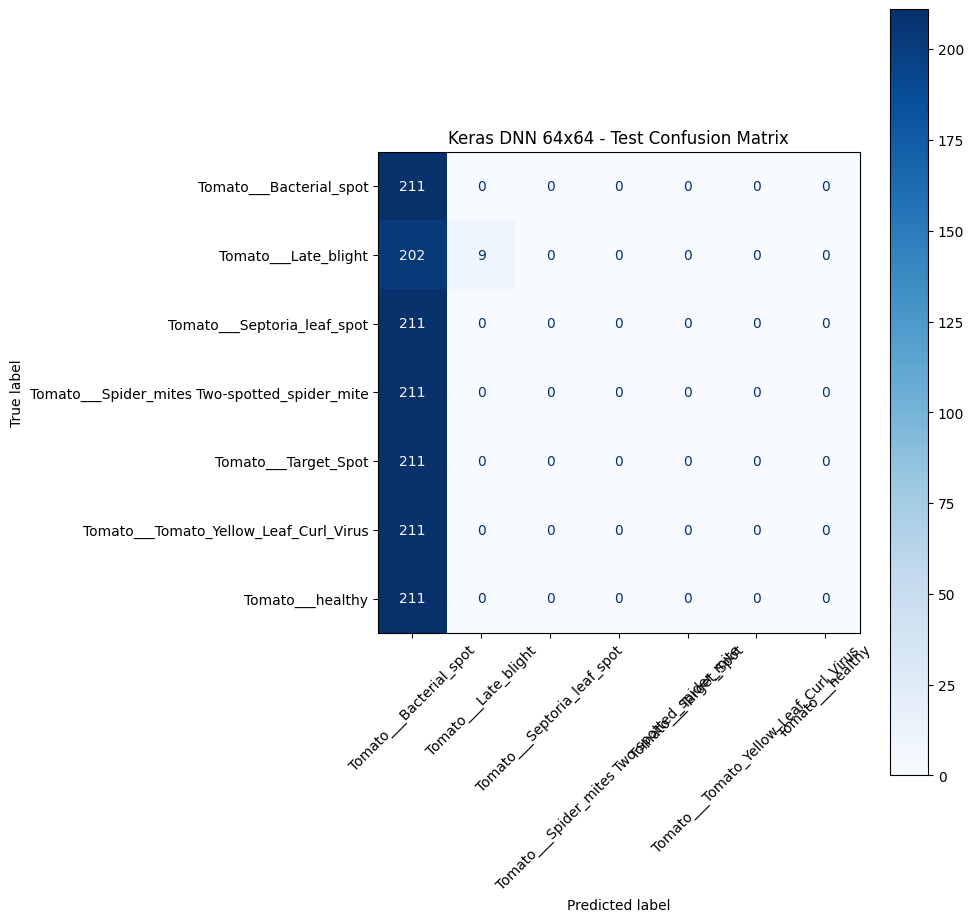

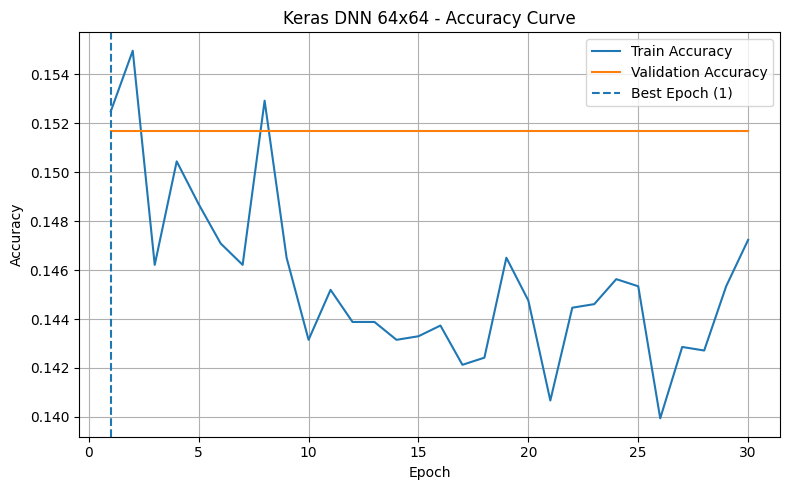

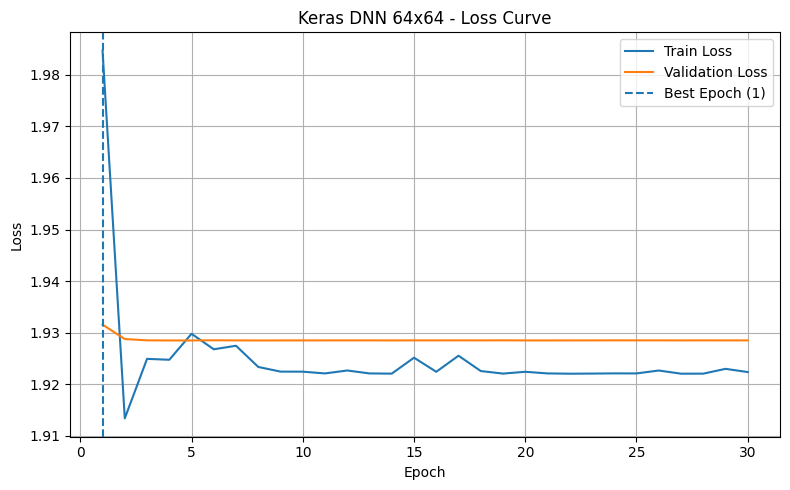


Keras DNN 64x64 결과 저장 완료
결과 폴더 : /content/best_tomato_keras_dnn_64_results
ZIP 파일  : /content/best_tomato_keras_dnn_64_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================
# Keras DNN 64x64 실험
# ==========================================

import os
import random
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ==========================================
# 1. 기본 설정
# ==========================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = "/content/tomato_dataset_clean"

IMG_SIZE = (64, 64)
BATCH_SIZE = 32
EPOCHS = 30
NUM_CLASSES = 7

print("TensorFlow version:", tf.__version__)


# ==========================================
# 2. 데이터 불러오기
# ==========================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("클래스:", class_names)
print("클래스 수:", NUM_CLASSES)


# ==========================================
# 3. Keras DNN 모델
# ==========================================

model = models.Sequential([

    layers.Input(shape=(64, 64, 3)),

    # 0~255 → 0~1
    layers.Rescaling(1./255),

    # 이미지 펼치기
    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dense(64, activation="relu"),

    layers.Dense(32, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# ==========================================
# 4. Best Model 저장
# ==========================================

BEST_MODEL_PATH = "/content/best_tomato_keras_dnn_64.keras"

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    BEST_MODEL_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)


# ==========================================
# 5. 학습
# ==========================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint]
)


# ==========================================
# 6. Best Epoch
# ==========================================

best_epoch = np.argmax(
    history.history["val_accuracy"]
) + 1

best_val_accuracy = max(
    history.history["val_accuracy"]
)

print("\n====================================")
print("Keras DNN 64x64 학습 완료")
print("====================================")
print(f"Best Epoch       : {best_epoch}")
print(f"Best Val Accuracy: {best_val_accuracy:.4f}")
print(f"모델 저장 위치   : {BEST_MODEL_PATH}")


# ==========================================
# 7. Best Model 불러오기
# ==========================================

best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)


# ==========================================
# 8. Test 예측
# ==========================================

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = best_model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

y_true = np.array(y_true)
y_pred = np.array(y_pred)


# ==========================================
# 9. 평가 지표
# ==========================================

test_accuracy = accuracy_score(
    y_true,
    y_pred
)

test_precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\n====================================")
print("Keras DNN 64x64 Test 결과")
print("====================================")

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")
print(f"Test images: {len(y_true)}")


# ==========================================
# 10. Classification Report
# ==========================================

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("\n====================================")
print("Classification Report")
print("====================================")

print(report)


# ==========================================
# 11. Confusion Matrix
# ==========================================

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\n====================================")
print("Confusion Matrix")
print("====================================")

print(cm)


# ==========================================
# 12. 결과 저장 폴더
# ==========================================

SAVE_DIR = "/content/best_tomato_keras_dnn_64_results"

if os.path.exists(SAVE_DIR):
    shutil.rmtree(SAVE_DIR)

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)


# ==========================================
# 13. Best Model 복사
# ==========================================

shutil.copy(
    BEST_MODEL_PATH,
    os.path.join(
        SAVE_DIR,
        "best_tomato_keras_dnn_64.keras"
    )
)


# ==========================================
# 14. Test 결과 TXT
# ==========================================

result_text = f"""
====================================
Tomato Leaf Disease - Keras DNN 64x64
====================================

Model Architecture

64x64x3
→ Flatten
→ Dense 128
→ Dense 64
→ Dense 32
→ Dropout 0.5
→ Output 7

Best Epoch        : {best_epoch}
Best Val Accuracy : {best_val_accuracy:.4f}

Test Images       : {len(y_true)}

Accuracy          : {test_accuracy:.4f}
Precision         : {test_precision:.4f}
Recall            : {test_recall:.4f}
F1-score          : {test_f1:.4f}


====================================
Classification Report
====================================

{report}


====================================
Confusion Matrix
====================================

{cm}
"""

with open(
    os.path.join(
        SAVE_DIR,
        "test_results.txt"
    ),
    "w",
    encoding="utf-8"
) as f:
    f.write(result_text)


# ==========================================
# 15. Metrics CSV
# ==========================================

metrics_df = pd.DataFrame({
    "Metric": [
        "Best Epoch",
        "Best Val Accuracy",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1-score",
        "Test Images"
    ],
    "Value": [
        best_epoch,
        best_val_accuracy,
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        len(y_true)
    ]
})

metrics_df.to_csv(
    os.path.join(
        SAVE_DIR,
        "metrics.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)


# ==========================================
# 16. Training History CSV
# ==========================================

history_df = pd.DataFrame({
    "Epoch": range(1, EPOCHS + 1),
    "Train Loss": history.history["loss"],
    "Train Accuracy": history.history["accuracy"],
    "Validation Loss": history.history["val_loss"],
    "Validation Accuracy": history.history["val_accuracy"]
})

history_df.to_csv(
    os.path.join(
        SAVE_DIR,
        "training_history.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)


# ==========================================
# 17. Confusion Matrix CSV
# ==========================================

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cm_df.to_csv(
    os.path.join(
        SAVE_DIR,
        "confusion_matrix.csv"
    ),
    encoding="utf-8-sig"
)


# ==========================================
# 18. Confusion Matrix 이미지
# ==========================================

fig, ax = plt.subplots(
    figsize=(10, 10)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title(
    "Keras DNN 64x64 - Test Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ==========================================
# 19. Accuracy Curve
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    range(1, EPOCHS + 1),
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Keras DNN 64x64 - Accuracy Curve"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "accuracy_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ==========================================
# 20. Loss Curve
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    history.history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Keras DNN 64x64 - Loss Curve"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "loss_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ==========================================
# 21. ZIP 압축
# ==========================================

ZIP_PATH = shutil.make_archive(
    "/content/best_tomato_keras_dnn_64_results",
    "zip",
    SAVE_DIR
)

print("\n====================================")
print("Keras DNN 64x64 결과 저장 완료")
print("====================================")

print(f"결과 폴더 : {SAVE_DIR}")
print(f"ZIP 파일  : {ZIP_PATH}")


# ==========================================
# 22. 다운로드
# ==========================================

from google.colab import files

files.download(ZIP_PATH)

PyTorch DNN 74.34%와 비슷한 조건에서 Keras DNN도 정상적으로 학습되는지 확인

In [ ]:
# ==========================================
# Keras DNN 진단 실험
# ==========================================

import tensorflow as tf
from tensorflow.keras import layers, models

# 기존 데이터 그대로 사용
# train_ds, val_ds는 위에서 이미 생성됨

keras_dnn_test = models.Sequential([
    layers.Input(shape=(64, 64, 3)),

    # 0~255 → 0~1
    layers.Rescaling(1./255),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu",
        kernel_initializer="he_normal"
    ),

    layers.Dense(
        64,
        activation="relu",
        kernel_initializer="he_normal"
    ),

    layers.Dense(
        32,
        activation="relu",
        kernel_initializer="he_normal"
    ),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

keras_dnn_test.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

keras_dnn_test.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_7 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,583,559 (6.04 MB)

 Trainable params: 1,583,559 (6.04 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_test = keras_dnn_test.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30
)

Epoch 1/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.3666 - loss: 1.7680 - val_accuracy: 0.3531 - val_loss: 1.6999
Epoch 2/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5554 - loss: 1.2458 - val_accuracy: 0.5844 - val_loss: 1.1525
Epoch 3/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6215 - loss: 1.0666 - val_accuracy: 0.5497 - val_loss: 1.2357
Epoch 4/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6577 - loss: 0.9733 - val_accuracy: 0.6503 - val_loss: 1.0218
Epoch 5/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6742 - loss: 0.9232 - val_accuracy: 0.6864 - val_loss: 0.8837
Epoch 6/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.6995 - loss: 0.8360 - val_accuracy: 0.5755 - val_loss: 1.2823
Epoch 7/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7200 - loss: 0.7928 - val_accuracy: 0.6769 - val_loss: 0.8798
Epoch 8/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.7373 - loss: 0.7450 - val_acc

he_normal빼고 Keras DNN 64×64 + Dropout 0.5

In [ ]:
# ==========================================
# Keras DNN 최종 실험
# 64x64 + Dropout 0.5
# He 초기화 사용하지 않음
# ==========================================

import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# ------------------------------------------
# 1. 기본 설정
# ------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (64, 64)
BATCH_SIZE = 32
EPOCHS = 30
NUM_CLASSES = 7

# 기존에 만든 clean dataset 사용
DATA_DIR = "/content/tomato_dataset_clean"

print("TensorFlow version:", tf.__version__)


# ------------------------------------------
# 2. 데이터 불러오기
# ------------------------------------------

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("클래스:", class_names)
print("클래스 수:", NUM_CLASSES)


# ------------------------------------------
# 3. Keras DNN 모델
# ------------------------------------------

model = models.Sequential([

    layers.Input(shape=(64, 64, 3)),

    # 0~255 → 0~1
    layers.Rescaling(1./255),

    # 이미지 펼치기
    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dense(64, activation="relu"),

    layers.Dense(32, activation="relu"),

    # Dropout 0.5
    layers.Dropout(0.5),

    # 7개 클래스 분류
    layers.Dense(NUM_CLASSES, activation="softmax")
])


# ------------------------------------------
# 4. Compile
# ------------------------------------------

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# ------------------------------------------
# 5. Best Model 저장
# ------------------------------------------

BEST_MODEL_PATH = "/content/best_tomato_keras_dnn_64_dropout05.keras"

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    BEST_MODEL_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)


# ------------------------------------------
# 6. 학습
# ------------------------------------------

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint]
)


# ------------------------------------------
# 7. Best Epoch
# ------------------------------------------

best_epoch = np.argmax(
    history.history["val_accuracy"]
) + 1

best_val_accuracy = max(
    history.history["val_accuracy"]
)

print("\n====================================")
print("Keras DNN 64x64 + Dropout 0.5")
print("학습 완료")
print("====================================")

print(f"Best Epoch       : {best_epoch}")
print(f"Best Val Accuracy: {best_val_accuracy:.4f}")
print(f"모델 저장 위치   : {BEST_MODEL_PATH}")

TensorFlow version: 2.20.0
Found 6853 files belonging to 7 classes.
Found 1470 files belonging to 7 classes.
Found 1477 files belonging to 7 classes.
클래스: ['Tomato___Bacterial_spot', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___healthy']
클래스 수: 7


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_8 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,583,559 (6.04 MB)

 Trainable params: 1,583,559 (6.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1482 - loss: 2.1514
Epoch 1: val_accuracy improved from None to 0.15170, saving model to /content/best_tomato_keras_dnn_64_dropout05.keras

Epoch 1: finished saving model to /content/best_tomato_keras_dnn_64_dropout05.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.1525 - loss: 1.9847 - val_accuracy: 0.1517 - val_loss: 1.9316
Epoch 2/30
212/215 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1593 - loss: 1.9077
Epoch 2: val_accuracy did not improve from 0.15170
215/215 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.1550 - loss: 1.9134 - val_accuracy: 0.1517 - val_loss: 1.9288
Epoch 3/30
212/215 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1437 - loss: 1.9258
Epoch 3: val_accuracy did not improve from 0.15170
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.1462 - loss: 1.9249 - val_accuracy: 0.1517 - val_loss: 1.9285
Epoch 4/30
214/215 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1489 - loss

80대 나온 케라스dnn 베스트 저장

In [ ]:
# ==========================================
# Keras DNN 최종 실험 + Best Model 저장
# 64x64 / Dropout 없음
# ==========================================

import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 모델
final_model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),
    layers.Rescaling(1./255),
    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

FINAL_MODEL_PATH = "/content/best_tomato_keras_dnn_64_final.keras"

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    FINAL_MODEL_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

final_history = final_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[checkpoint]
)

best_epoch = np.argmax(
    final_history.history["val_accuracy"]
) + 1

best_val_accuracy = max(
    final_history.history["val_accuracy"]
)

print("\n====================================")
print("Keras DNN 최종 학습 완료")
print("====================================")
print(f"Best Epoch       : {best_epoch}")
print(f"Best Val Accuracy: {best_val_accuracy:.4f}")
print(f"Best Model       : {FINAL_MODEL_PATH}")

Epoch 1/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2636 - loss: 1.9697
Epoch 1: val_accuracy improved from None to 0.41769, saving model to /content/best_tomato_keras_dnn_64_final.keras

Epoch 1: finished saving model to /content/best_tomato_keras_dnn_64_final.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.3693 - loss: 1.6709 - val_accuracy: 0.4177 - val_loss: 1.4742
Epoch 2/30
212/215 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5565 - loss: 1.2190
Epoch 2: val_accuracy improved from 0.41769 to 0.57551, saving model to /content/best_tomato_keras_dnn_64_final.keras

Epoch 2: finished saving model to /content/best_tomato_keras_dnn_64_final.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.5827 - loss: 1.1662 - val_accuracy: 0.5755 - val_loss: 1.1776
Epoch 3/30
214/215 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6266 - loss: 1.0280
Epoch 3: val_accuracy did not improve from 0.57551
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0

He 초기화 + Dropout 0.5 조합 케라스 dnn 테스

In [ ]:
# ==========================================
# Keras DNN 최종 후보 실험
# 64x64 + He 초기화 + Dropout 0.5
# ==========================================

import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# ------------------------------------------
# 1. 기본 설정
# ------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = "/content/tomato_dataset_clean"

IMG_SIZE = (64, 64)
BATCH_SIZE = 32
EPOCHS = 30
NUM_CLASSES = 7

print("TensorFlow version:", tf.__version__)


# ------------------------------------------
# 2. 데이터 불러오기
# ------------------------------------------

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("클래스:", class_names)
print("클래스 수:", NUM_CLASSES)


# ------------------------------------------
# 3. Keras DNN 모델
# ------------------------------------------

model_he_dropout = models.Sequential([

    layers.Input(shape=(64, 64, 3)),

    # 0~255 → 0~1
    layers.Rescaling(1./255),

    # 이미지 펼치기
    layers.Flatten(),

    # He 초기화 + ReLU
    layers.Dense(
        128,
        activation="relu",
        kernel_initializer="he_normal"
    ),

    layers.Dense(
        64,
        activation="relu",
        kernel_initializer="he_normal"
    ),

    layers.Dense(
        32,
        activation="relu",
        kernel_initializer="he_normal"
    ),

    # Dropout 0.5
    layers.Dropout(0.5),

    # 출력층
    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])


# ------------------------------------------
# 4. Compile
# ------------------------------------------

model_he_dropout.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_he_dropout.summary()


# ------------------------------------------
# 5. Best Model 저장
# ------------------------------------------

BEST_MODEL_PATH = "/content/best_tomato_keras_dnn_64_he_dropout05.keras"

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    BEST_MODEL_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)


# ------------------------------------------
# 6. 학습
# ------------------------------------------

history_he_dropout = model_he_dropout.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint]
)


# ------------------------------------------
# 7. Best Epoch
# ------------------------------------------

best_epoch_he_dropout = np.argmax(
    history_he_dropout.history["val_accuracy"]
) + 1

best_val_accuracy_he_dropout = max(
    history_he_dropout.history["val_accuracy"]
)

print("\n====================================")
print("Keras DNN 64x64")
print("He 초기화 + Dropout 0.5")
print("학습 완료")
print("====================================")

print(f"Best Epoch       : {best_epoch_he_dropout}")
print(f"Best Val Accuracy: {best_val_accuracy_he_dropout:.4f}")
print(f"모델 저장 위치   : {BEST_MODEL_PATH}")

TensorFlow version: 2.20.0
Found 6853 files belonging to 7 classes.
Found 1470 files belonging to 7 classes.
Found 1477 files belonging to 7 classes.
클래스: ['Tomato___Bacterial_spot', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___healthy']
클래스 수: 7


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_10 (Rescaling)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,583,559 (6.04 MB)

 Trainable params: 1,583,559 (6.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1812 - loss: 2.4729
Epoch 1: val_accuracy improved from None to 0.43878, saving model to /content/best_tomato_keras_dnn_64_he_dropout05.keras

Epoch 1: finished saving model to /content/best_tomato_keras_dnn_64_he_dropout05.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.2196 - loss: 2.0187 - val_accuracy: 0.4388 - val_loss: 1.7260
Epoch 2/30
211/215 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3008 - loss: 1.7158
Epoch 2: val_accuracy improved from 0.43878 to 0.48707, saving model to /content/best_tomato_keras_dnn_64_he_dropout05.keras

Epoch 2: finished saving model to /content/best_tomato_keras_dnn_64_he_dropout05.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.3277 - loss: 1.6576 - val_accuracy: 0.4871 - val_loss: 1.4497
Epoch 3/30
214/215 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3791 - loss: 1.5494
Epoch 3: val_accuracy improved from 0.48707 to 0.53401, saving model to /conten

평가

Best model 불러오기 완료

Keras DNN 64x64
He 초기화 + Dropout 0.5
Test 결과
Accuracy : 0.7448
Precision: 0.7600
Recall   : 0.7448
F1-score : 0.7457
Test images: 1477

Classification Report
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot     0.8494    0.6682    0.7480       211
                         Tomato___Late_blight     0.8387    0.6161    0.7104       211
                  Tomato___Septoria_leaf_spot     0.6435    0.6588    0.6511       211
Tomato___Spider_mites Two-spotted_spider_mite     0.6533    0.8483    0.7381       211
                         Tomato___Target_Spot     0.6260    0.7536    0.6839       211
       Tomato___Tomato_Yellow_Leaf_Curl_Virus     0.8657    0.8246    0.8447       211
                             Tomato___healthy     0.8436    0.8436    0.8436       211

                                     accuracy                         0.7448      1477
                                    m

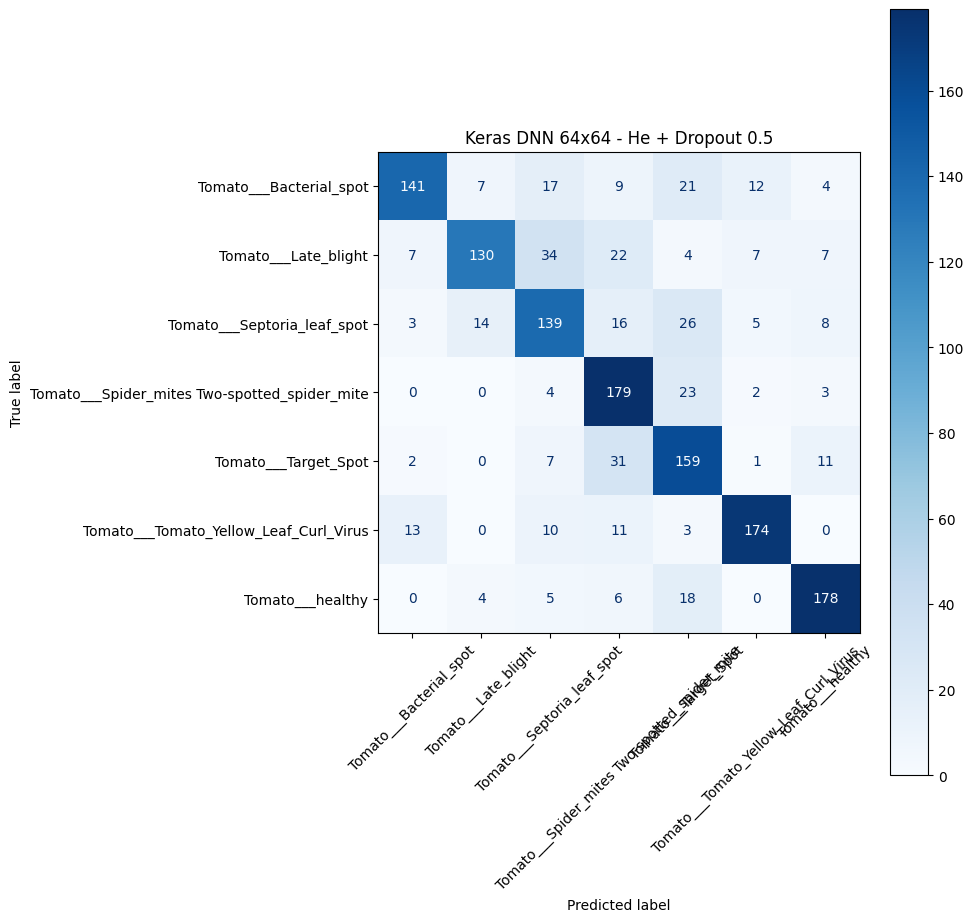

In [ ]:
# ==========================================
# Keras DNN 최종 Test 평가
# He 초기화 + Dropout 0.5
# ==========================================

import numpy as np
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt


# ------------------------------------------
# 1. Best Model 불러오기
# ------------------------------------------

BEST_MODEL_PATH = "/content/best_tomato_keras_dnn_64_he_dropout05.keras"

best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)

print("Best model 불러오기 완료")


# ------------------------------------------
# 2. Test 예측
# ------------------------------------------

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = best_model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

y_true = np.array(y_true)
y_pred = np.array(y_pred)


# ------------------------------------------
# 3. 평가 지표
# ------------------------------------------

test_accuracy = accuracy_score(
    y_true,
    y_pred
)

test_precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)


# ------------------------------------------
# 4. 결과 출력
# ------------------------------------------

print("\n====================================")
print("Keras DNN 64x64")
print("He 초기화 + Dropout 0.5")
print("Test 결과")
print("====================================")

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")
print(f"Test images: {len(y_true)}")


# ------------------------------------------
# 5. Classification Report
# ------------------------------------------

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("\n====================================")
print("Classification Report")
print("====================================")

print(report)


# ------------------------------------------
# 6. Confusion Matrix
# ------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\n====================================")
print("Confusion Matrix")
print("====================================")

print(cm)


# ------------------------------------------
# 7. Confusion Matrix 시각화
# ------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 10)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title(
    "Keras DNN 64x64 - He + Dropout 0.5"
)

plt.tight_layout()
plt.show()
plt.close()

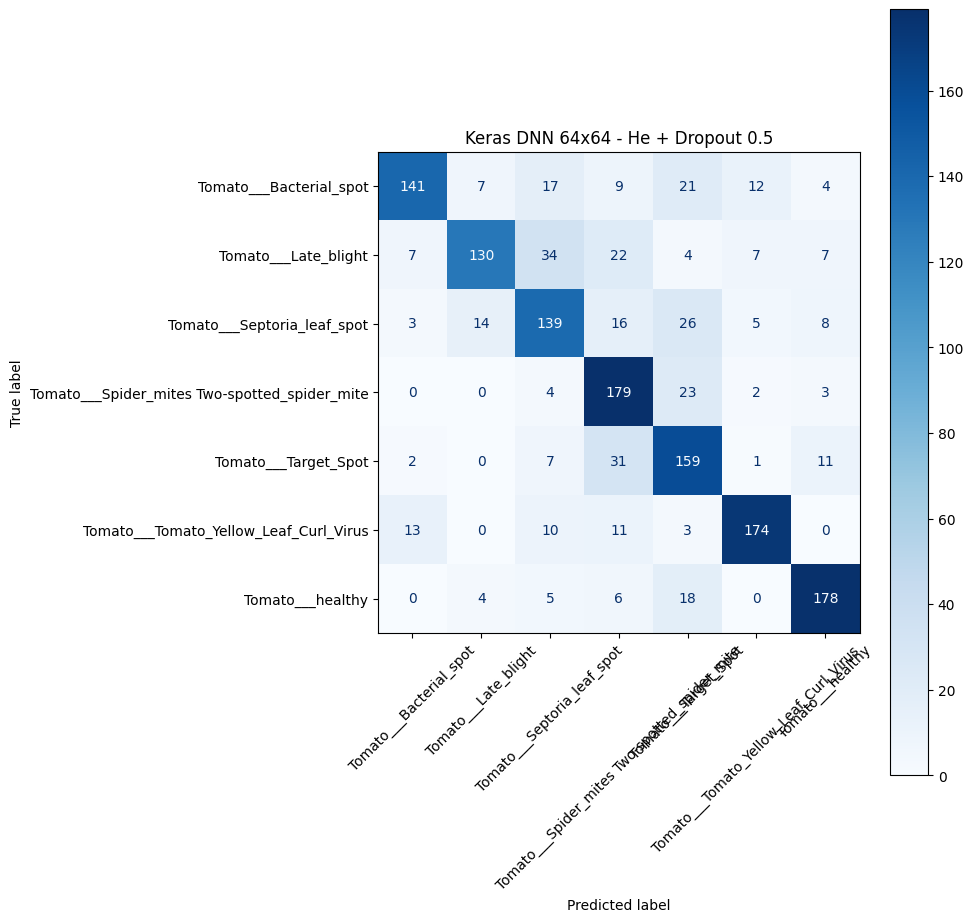

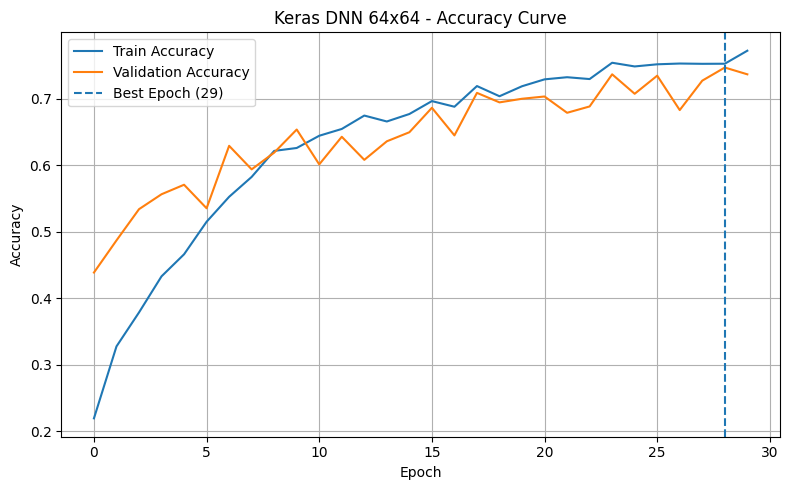

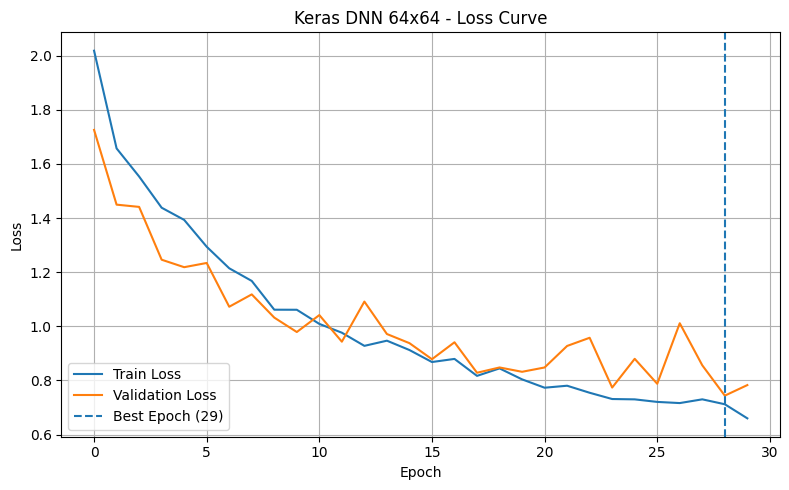


결과 저장 완료
결과 폴더 : /root/Desktop/best_tomato_keras_dnn_64_he_dropout05_results
ZIP 파일  : /root/Desktop/best_tomato_keras_dnn_64_he_dropout05_results.zip


In [ ]:
# ==========================================
# Keras DNN 최종 결과 저장
# He 초기화 + Dropout 0.5
# ==========================================

import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------
# 1. 저장 폴더
# ------------------------------------------

SAVE_DIR = "/root/Desktop/best_tomato_keras_dnn_64_he_dropout05_results"

if os.path.exists(SAVE_DIR):
    shutil.rmtree(SAVE_DIR)

os.makedirs(SAVE_DIR, exist_ok=True)


# ------------------------------------------
# 2. Best Model 복사
# ------------------------------------------

BEST_MODEL_PATH = "/content/best_tomato_keras_dnn_64_he_dropout05.keras"

shutil.copy(
    BEST_MODEL_PATH,
    os.path.join(
        SAVE_DIR,
        "best_tomato_keras_dnn_64_he_dropout05.keras"
    )
)


# ------------------------------------------
# 3. Test 결과 TXT 저장
# ------------------------------------------

result_text = f"""
====================================
Tomato Leaf Disease Classification
Keras DNN 64x64
He Initialization + Dropout 0.5
====================================

Model Architecture

64x64x3
→ Rescaling (1/255)
→ Flatten
→ Dense 128 + ReLU
→ Dense 64 + ReLU
→ Dense 32 + ReLU
→ Dropout 0.5
→ Output 7 + Softmax

Training Conditions

Optimizer: Adam
Learning Rate: 0.001
Batch Size: 32
Epochs: 30
Data Augmentation: None
Seed: 42

Best Epoch: {best_epoch_he_dropout}
Best Validation Accuracy: {best_val_accuracy_he_dropout:.4f}

Test Results

Test Images: {len(y_true)}
Accuracy: {test_accuracy:.4f}
Precision: {test_precision:.4f}
Recall: {test_recall:.4f}
F1-score: {test_f1:.4f}


====================================
Classification Report
====================================

{report}


====================================
Confusion Matrix
====================================

{cm}
"""

with open(
    os.path.join(SAVE_DIR, "test_results.txt"),
    "w",
    encoding="utf-8"
) as f:
    f.write(result_text)


# ------------------------------------------
# 4. Metrics CSV
# ------------------------------------------

metrics_df = pd.DataFrame({
    "Metric": [
        "Best Epoch",
        "Best Validation Accuracy",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1-score",
        "Test Images"
    ],
    "Value": [
        best_epoch_he_dropout,
        best_val_accuracy_he_dropout,
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        len(y_true)
    ]
})

metrics_df.to_csv(
    os.path.join(SAVE_DIR, "metrics.csv"),
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------
# 5. Classification Report CSV
# ------------------------------------------

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

report_df.to_csv(
    os.path.join(SAVE_DIR, "classification_report.csv"),
    encoding="utf-8-sig"
)


# ------------------------------------------
# 6. Confusion Matrix CSV
# ------------------------------------------

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cm_df.to_csv(
    os.path.join(SAVE_DIR, "confusion_matrix.csv"),
    encoding="utf-8-sig"
)


# ------------------------------------------
# 7. Confusion Matrix 이미지
# ------------------------------------------

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title(
    "Keras DNN 64x64 - He + Dropout 0.5"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ------------------------------------------
# 8. Training History CSV
# ------------------------------------------

history_df = pd.DataFrame({
    "Epoch": range(
        1,
        len(history_he_dropout.history["accuracy"]) + 1
    ),
    "Train Loss": history_he_dropout.history["loss"],
    "Train Accuracy": history_he_dropout.history["accuracy"],
    "Validation Loss": history_he_dropout.history["val_loss"],
    "Validation Accuracy": history_he_dropout.history["val_accuracy"]
})

history_df.to_csv(
    os.path.join(
        SAVE_DIR,
        "training_history.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------
# 9. Accuracy Curve
# ------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history_he_dropout.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_he_dropout.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.axvline(
    best_epoch_he_dropout - 1,
    linestyle="--",
    label=f"Best Epoch ({best_epoch_he_dropout})"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Keras DNN 64x64 - Accuracy Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "accuracy_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ------------------------------------------
# 10. Loss Curve
# ------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history_he_dropout.history["loss"],
    label="Train Loss"
)

plt.plot(
    history_he_dropout.history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    best_epoch_he_dropout - 1,
    linestyle="--",
    label=f"Best Epoch ({best_epoch_he_dropout})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Keras DNN 64x64 - Loss Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "loss_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ------------------------------------------
# 11. ZIP 압축
# ------------------------------------------

ZIP_PATH = shutil.make_archive(
    "/root/Desktop/best_tomato_keras_dnn_64_he_dropout05_results",
    "zip",
    SAVE_DIR
)

print("\n====================================")
print("결과 저장 완료")
print("====================================")

print(f"결과 폴더 : {SAVE_DIR}")
print(f"ZIP 파일  : {ZIP_PATH}")

In [ ]:
from google.colab import files

files.download(
    "/root/Desktop/best_tomato_keras_dnn_64_he_dropout05_results.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ann 케라스

Found 6853 files belonging to 7 classes.
Found 1470 files belonging to 7 classes.
Found 1477 files belonging to 7 classes.
Classes: ['Tomato___Bacterial_spot', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___healthy']


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_11 (Rescaling)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,583,559 (6.04 MB)

 Trainable params: 1,583,559 (6.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1812 - loss: 2.4729
Epoch 1: val_accuracy improved from None to 0.43878, saving model to /content/best_tomato_keras_ann.keras

Epoch 1: finished saving model to /content/best_tomato_keras_ann.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - accuracy: 0.2196 - loss: 2.0187 - val_accuracy: 0.4388 - val_loss: 1.7260
Epoch 2/30
213/215 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3011 - loss: 1.7152
Epoch 2: val_accuracy improved from 0.43878 to 0.48707, saving model to /content/best_tomato_keras_ann.keras

Epoch 2: finished saving model to /content/best_tomato_keras_ann.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.3277 - loss: 1.6576 - val_accuracy: 0.4871 - val_loss: 1.4497
Epoch 3/30
211/215 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3791 - loss: 1.5494
Epoch 3: val_accuracy improved from 0.48707 to 0.53401, saving model to /content/best_tomato_keras_ann.keras

Epoch 3: finished saving model to

,precision,recall,f1-score,support
Tomato___Bacterial_spot,0.849398,0.668246,0.748011,211.000000
Tomato___Late_blight,0.838710,0.616114,0.710383,211.000000
Tomato___Septoria_leaf_spot,0.643519,0.658768,0.651054,211.000000
Tomato___Spider_mites Two-spotted_spider_mite,0.653285,0.848341,0.738144,211.000000
Tomato___Target_Spot,0.625984,0.753555,0.683871,211.000000
Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.865672,0.824645,0.844660,211.000000
Tomato___healthy,0.843602,0.843602,0.843602,211.000000
accuracy,0.744753,0.744753,0.744753,0.744753
macro avg,0.760024,0.744753,0.745675,1477.000000
weighted avg,0.760024,0.744753,0.745675,1477.000000



Confusion Matrix


,Tomato___Bacterial_spot,Tomato___Late_blight,Tomato___Septoria_leaf_spot,Tomato___Spider_mites Two-spotted_spider_mite,Tomato___Target_Spot,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato___healthy
Tomato___Bacterial_spot,141,7,17,9,21,12,4
Tomato___Late_blight,7,130,34,22,4,7,7
Tomato___Septoria_leaf_spot,3,14,139,16,26,5,8
Tomato___Spider_mites Two-spotted_spider_mite,0,0,4,179,23,2,3
Tomato___Target_Spot,2,0,7,31,159,1,11
Tomato___Tomato_Yellow_Leaf_Curl_Virus,13,0,10,11,3,174,0
Tomato___healthy,0,4,5,6,18,0,178


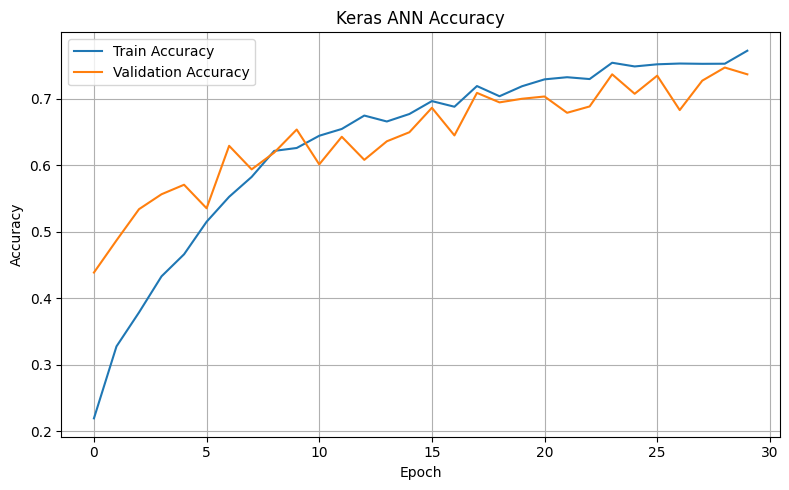

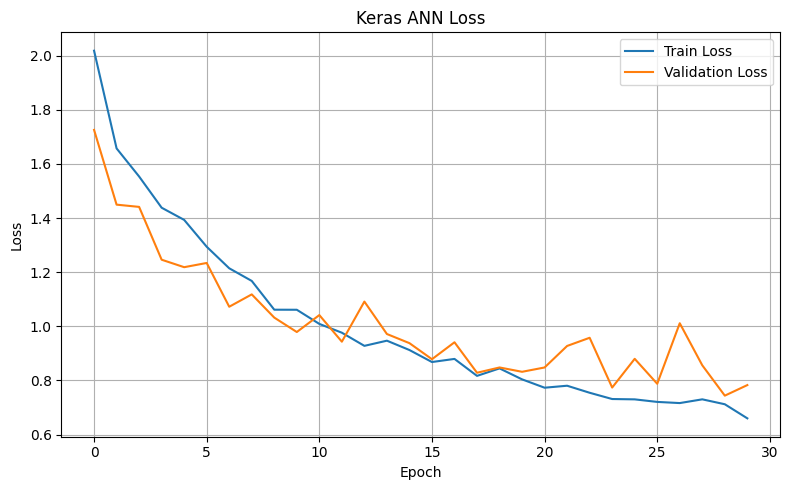

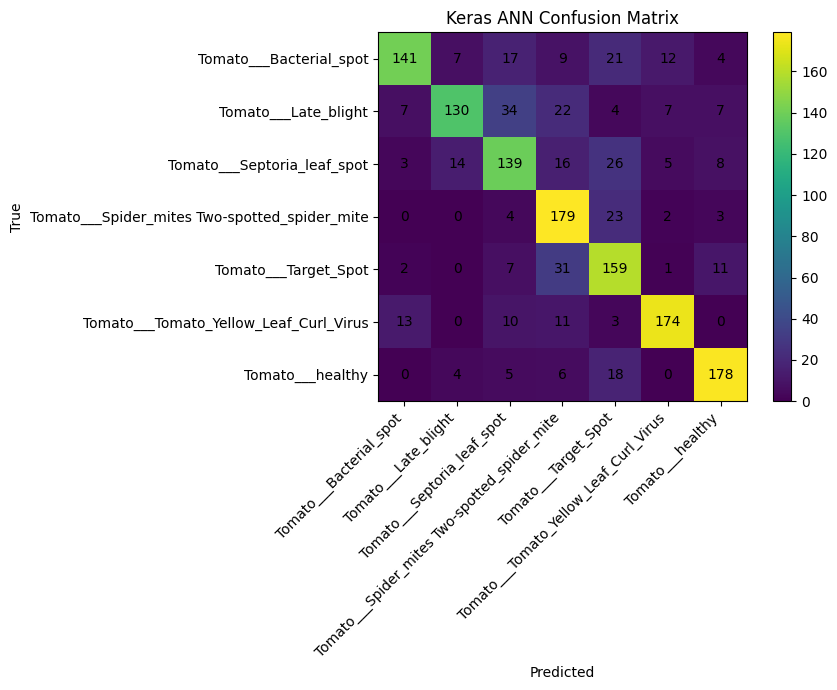


저장 완료
Colab folder:
/content/best_tomato_keras_ann_results

ZIP:
/content/best_tomato_keras_ann_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# Keras ANN
# 학습 → Best Model → Test → 결과 분석 → Desktop 저장
# ============================================================

import os
import random
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. Seed
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# 2. 설정
# ============================================================

DATA_DIR = "/content/tomato_dataset_clean"

IMG_SIZE = (64, 64)
BATCH_SIZE = 32
EPOCHS = 30

BEST_MODEL_PATH = "/content/best_tomato_keras_ann.keras"

# 결과 저장 폴더
SAVE_DIR = "/content/best_tomato_keras_ann_results"

os.makedirs(SAVE_DIR, exist_ok=True)

# ============================================================
# 3. Dataset
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Classes:", class_names)

# ============================================================
# 4. ANN Model
# ============================================================

model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),
    layers.Rescaling(1./255),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu",
        kernel_initializer="he_normal"
    ),

    layers.Dense(
        64,
        activation="relu",
        kernel_initializer="he_normal"
    ),

    layers.Dense(
        32,
        activation="relu",
        kernel_initializer="he_normal"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ============================================================
# 5. Best Model 저장
# ============================================================

checkpoint = ModelCheckpoint(
    BEST_MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

# ============================================================
# 6. 학습
# ============================================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint]
)

# ============================================================
# 7. Best Model 불러오기
# ============================================================

best_model = tf.keras.models.load_model(BEST_MODEL_PATH)

best_epoch = int(np.argmax(history.history["val_accuracy"]) + 1)

best_val_accuracy = float(
    max(history.history["val_accuracy"])
)

print("\nBest Epoch:", best_epoch)
print("Best Val Accuracy:", best_val_accuracy)

# ============================================================
# 8. Test Prediction
# ============================================================

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = best_model.predict(
        images,
        verbose=0
    )

    y_true.extend(labels.numpy())
    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ============================================================
# 9. Metrics
# ============================================================

test_accuracy = accuracy_score(y_true, y_pred)

test_precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\n================================")
print("Keras ANN Test Results")
print("================================")

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")

# ============================================================
# 10. Classification Report
# ============================================================

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

print("\nClassification Report")
display(report_df)

# ============================================================
# 11. Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

print("\nConfusion Matrix")
display(cm_df)

# ============================================================
# 12. 학습 결과 CSV
# ============================================================

history_df = pd.DataFrame(history.history)

history_df.insert(
    0,
    "epoch",
    range(1, len(history_df) + 1)
)

history_df.to_csv(
    os.path.join(SAVE_DIR, "training_history.csv"),
    index=False,
    encoding="utf-8-sig"
)

report_df.to_csv(
    os.path.join(SAVE_DIR, "classification_report.csv"),
    encoding="utf-8-sig"
)

cm_df.to_csv(
    os.path.join(SAVE_DIR, "confusion_matrix.csv"),
    encoding="utf-8-sig"
)

# ============================================================
# 13. Metrics CSV
# ============================================================

metrics_df = pd.DataFrame({
    "Metric": [
        "Best Epoch",
        "Best Validation Accuracy",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1"
    ],
    "Value": [
        best_epoch,
        best_val_accuracy,
        test_accuracy,
        test_precision,
        test_recall,
        test_f1
    ]
})

metrics_df.to_csv(
    os.path.join(SAVE_DIR, "metrics.csv"),
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# 14. Accuracy Curve
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Keras ANN Accuracy")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(SAVE_DIR, "accuracy_curve.png"),
    dpi=200
)

plt.show()

# ============================================================
# 15. Loss Curve
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Keras ANN Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(SAVE_DIR, "loss_curve.png"),
    dpi=200
)

plt.show()

# ============================================================
# 16. Confusion Matrix 이미지
# ============================================================

plt.figure(figsize=(9, 7))

plt.imshow(cm)

plt.title("Keras ANN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.xticks(
    range(NUM_CLASSES),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(NUM_CLASSES),
    class_names
)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.savefig(
    os.path.join(SAVE_DIR, "confusion_matrix.png"),
    dpi=200
)

plt.show()

# ============================================================
# 17. 모델 복사
# ============================================================

shutil.copy(
    BEST_MODEL_PATH,
    os.path.join(
        SAVE_DIR,
        "best_tomato_keras_ann.keras"
    )
)

# ============================================================
# 18. 결과 TXT
# ============================================================

with open(
    os.path.join(SAVE_DIR, "test_results.txt"),
    "w",
    encoding="utf-8"
) as f:

    f.write("Keras ANN Tomato Leaf Classification\n")
    f.write("=" * 50 + "\n\n")

    f.write("Model Architecture\n")
    f.write("Input: 64x64x3\n")
    f.write("Flatten\n")
    f.write("Dense 128 + ReLU + He Normal\n")
    f.write("Dense 64 + ReLU + He Normal\n")
    f.write("Dense 32 + ReLU + He Normal\n")
    f.write("Dropout 0.5\n")
    f.write("Output: 7 classes + Softmax\n\n")

    f.write("Training Conditions\n")
    f.write("Optimizer: Adam\n")
    f.write("Learning Rate: 0.001\n")
    f.write("Batch Size: 32\n")
    f.write("Epochs: 30\n")
    f.write("Data Augmentation: None\n")
    f.write("Seed: 42\n\n")

    f.write(f"Best Epoch: {best_epoch}\n")
    f.write(
        f"Best Validation Accuracy: "
        f"{best_val_accuracy:.4f}\n\n"
    )

    f.write("Test Results\n")
    f.write(f"Accuracy : {test_accuracy:.4f}\n")
    f.write(f"Precision: {test_precision:.4f}\n")
    f.write(f"Recall   : {test_recall:.4f}\n")
    f.write(f"F1-score : {test_f1:.4f}\n\n")

    f.write("Classification Report\n")
    f.write(
        report_df.to_string()
    )

# ============================================================
# 19. ZIP
# ============================================================

ZIP_PATH = shutil.make_archive(
    "/content/best_tomato_keras_ann_results",
    "zip",
    SAVE_DIR
)

print("\n================================")
print("저장 완료")
print("================================")

print("Colab folder:")
print(SAVE_DIR)

print("\nZIP:")
print(ZIP_PATH)

# ============================================================
# 20. 데스크탑으로 다운로드
# ============================================================

from google.colab import files

files.download(ZIP_PATH)

pytorch cnn

Device: cuda
Classes: ['Tomato___Bacterial_spot', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___healthy']
Train: 6853
Validation: 1470
Test: 1477

Model:
ANN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=12288, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc4): Linear(in_features=32, out_features=7, bias=True)
)
Epoch [01/30] Train Loss: 1.8536 Train Acc: 0.2336 | Val Loss: 1.6110 Val Acc: 0.4088
Epoch [02/30] Train Loss: 1.5347 Train Acc: 0.3905 | Val Loss: 1.3662 Val Acc: 0.4789
Epoch [03/30] Train Loss: 1.3774 Train Acc: 0.4805 | Val Loss: 1.2198 Val Acc: 0.5673
Epoch [04/30] Train Loss: 1.2912 Train Acc: 0.5239 | Val Loss: 1.2563 Val Acc: 0.5177
Epoch [05/3

,precision,recall,f1-score,support
Tomato___Bacterial_spot,0.732759,0.805687,0.767494,211.000000
Tomato___Late_blight,0.875817,0.635071,0.736264,211.000000
Tomato___Septoria_leaf_spot,0.726115,0.540284,0.619565,211.000000
Tomato___Spider_mites Two-spotted_spider_mite,0.659091,0.824645,0.732632,211.000000
Tomato___Target_Spot,0.707071,0.663507,0.684597,211.000000
Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.694737,0.938389,0.798387,211.000000
Tomato___healthy,0.893617,0.796209,0.842105,211.000000
accuracy,0.743399,0.743399,0.743399,0.743399
macro avg,0.755601,0.743399,0.740149,1477.000000
weighted avg,0.755601,0.743399,0.740149,1477.000000



Confusion Matrix


,Tomato___Bacterial_spot,Tomato___Late_blight,Tomato___Septoria_leaf_spot,Tomato___Spider_mites Two-spotted_spider_mite,Tomato___Target_Spot,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato___healthy
Tomato___Bacterial_spot,170,2,3,3,0,30,3
Tomato___Late_blight,9,134,23,22,1,16,6
Tomato___Septoria_leaf_spot,22,7,114,20,17,27,4
Tomato___Spider_mites Two-spotted_spider_mite,5,1,1,174,17,11,2
Tomato___Target_Spot,17,1,8,37,140,3,5
Tomato___Tomato_Yellow_Leaf_Curl_Virus,7,2,1,3,0,198,0
Tomato___healthy,2,6,7,5,23,0,168


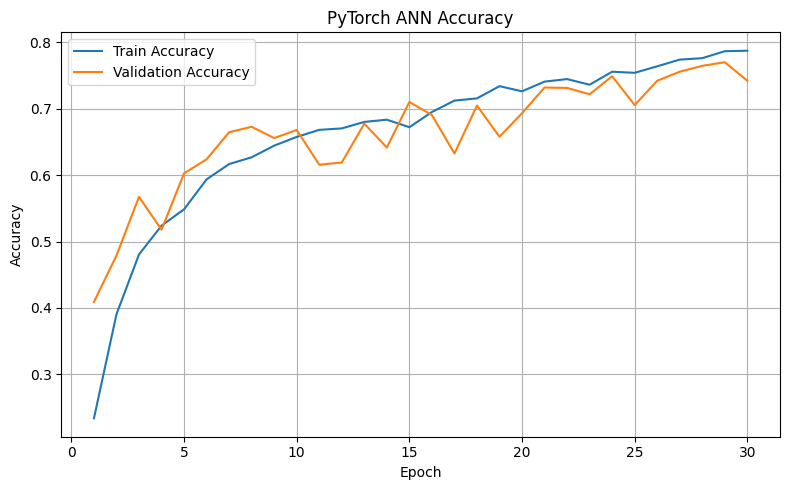

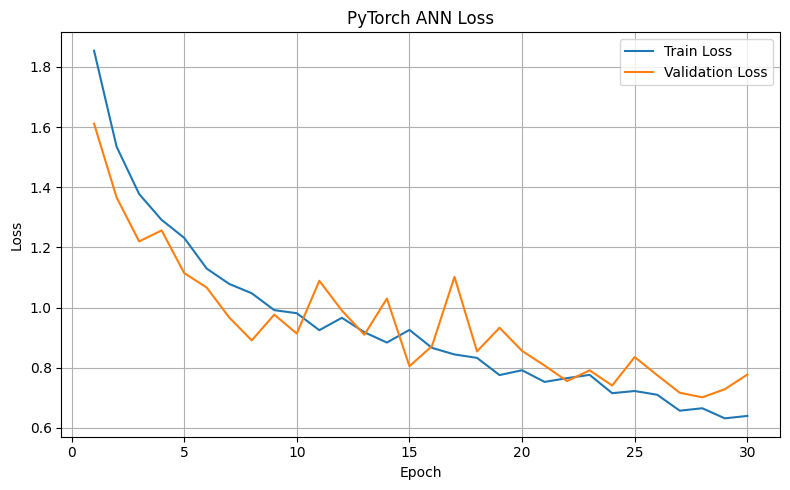

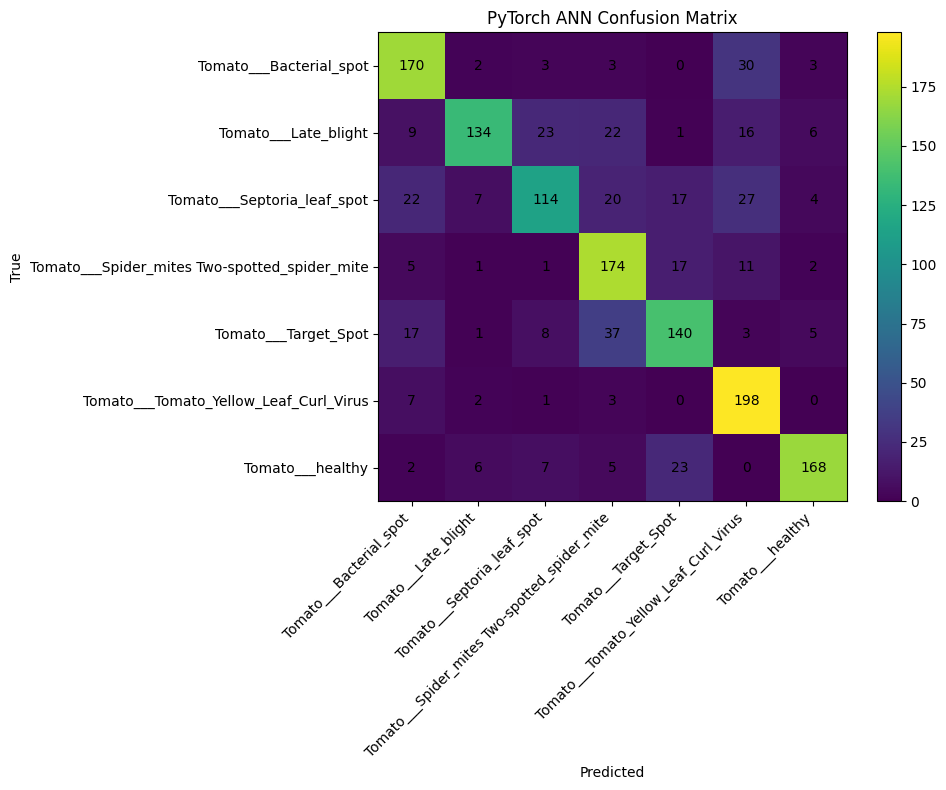


모든 결과 저장 완료!

결과 폴더:
/content/best_tomato_pytorch_ann_results

ZIP:
/content/best_tomato_pytorch_ann_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# PyTorch ANN
# 학습 → Best Model → Test → 분석 → Desktop 다운로드
# ============================================================

import os
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. Seed
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ============================================================
# 2. 설정
# ============================================================

DATA_DIR = "/content/tomato_dataset_clean"

IMG_SIZE = 64
BATCH_SIZE = 32
EPOCHS = 30

BEST_MODEL_PATH = "/content/best_tomato_pytorch_ann.pth"
SAVE_DIR = "/content/best_tomato_pytorch_ann_results"

os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# ============================================================
# 3. Dataset
# ============================================================

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "train"),
    transform=transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "val"),
    transform=transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "test"),
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_dataset.classes
NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

# ============================================================
# 4. ANN Model
# ============================================================

class ANN(nn.Module):

    def __init__(self, num_classes=7):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(
            3 * 64 * 64,
            128
        )

        self.fc2 = nn.Linear(
            128,
            64
        )

        self.fc3 = nn.Linear(
            64,
            32
        )

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(0.5)

        self.fc4 = nn.Linear(
            32,
            num_classes
        )

    def forward(self, x):

        x = self.flatten(x)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))

        x = self.dropout(x)

        x = self.fc4(x)

        return x


model = ANN(NUM_CLASSES).to(device)

print("\nModel:")
print(model)

# ============================================================
# 5. Loss / Optimizer
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# ============================================================
# 6. 학습 기록
# ============================================================

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0
best_epoch = 0

# ============================================================
# 7. Training
# ============================================================

for epoch in range(EPOCHS):

    # -------------------------
    # Train
    # -------------------------

    model.train()

    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * labels.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        train_total += labels.size(0)

        train_correct += (
            predictions == labels
        ).sum().item()

    train_loss = (
        running_loss / train_total
    )

    train_accuracy = (
        train_correct / train_total
    )

    # -------------------------
    # Validation
    # -------------------------

    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_val_loss += (
                loss.item() * labels.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            val_total += labels.size(0)

            val_correct += (
                predictions == labels
            ).sum().item()

    val_loss = (
        running_val_loss / val_total
    )

    val_accuracy = (
        val_correct / val_total
    )

    # 기록
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )

    # -------------------------
    # Best Model 저장
    # -------------------------

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

# ============================================================
# 8. Best Model
# ============================================================

print("\n==============================")
print("Best Model")
print("==============================")

print("Best Epoch:", best_epoch)
print(
    f"Best Val Accuracy: "
    f"{best_val_accuracy:.4f}"
)

model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model.eval()

# ============================================================
# 9. Test
# ============================================================

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            predictions.cpu().numpy()
        )

# ============================================================
# 10. Metrics
# ============================================================

test_accuracy = accuracy_score(
    y_true,
    y_pred
)

test_precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\n================================")
print("PyTorch ANN Test Results")
print("================================")

print(
    f"Accuracy : {test_accuracy:.4f}"
)

print(
    f"Precision: {test_precision:.4f}"
)

print(
    f"Recall   : {test_recall:.4f}"
)

print(
    f"F1-score : {test_f1:.4f}"
)

# ============================================================
# 11. Classification Report
# ============================================================

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report
).transpose()

print("\nClassification Report")
display(report_df)

# ============================================================
# 12. Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

print("\nConfusion Matrix")
display(cm_df)

# ============================================================
# 13. Training History CSV
# ============================================================

history_df = pd.DataFrame({
    "epoch": range(1, EPOCHS + 1),
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_accuracy": train_accuracies,
    "val_accuracy": val_accuracies
})

history_df.to_csv(
    os.path.join(
        SAVE_DIR,
        "training_history.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# 14. Metrics CSV
# ============================================================

metrics_df = pd.DataFrame({
    "Metric": [
        "Best Epoch",
        "Best Validation Accuracy",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1"
    ],
    "Value": [
        best_epoch,
        best_val_accuracy,
        test_accuracy,
        test_precision,
        test_recall,
        test_f1
    ]
})

metrics_df.to_csv(
    os.path.join(
        SAVE_DIR,
        "metrics.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# 15. Classification Report CSV
# ============================================================

report_df.to_csv(
    os.path.join(
        SAVE_DIR,
        "classification_report.csv"
    ),
    encoding="utf-8-sig"
)

# ============================================================
# 16. Confusion Matrix CSV
# ============================================================

cm_df.to_csv(
    os.path.join(
        SAVE_DIR,
        "confusion_matrix.csv"
    ),
    encoding="utf-8-sig"
)

# ============================================================
# 17. Accuracy Curve
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("PyTorch ANN Accuracy")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "accuracy_curve.png"
    ),
    dpi=200
)

plt.show()

# ============================================================
# 18. Loss Curve
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PyTorch ANN Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "loss_curve.png"
    ),
    dpi=200
)

plt.show()

# ============================================================
# 19. Confusion Matrix 이미지
# ============================================================

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.title("PyTorch ANN Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("True")

plt.xticks(
    range(NUM_CLASSES),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(NUM_CLASSES),
    class_names
)

for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "confusion_matrix.png"
    ),
    dpi=200
)

plt.show()

# ============================================================
# 20. Best Model 복사
# ============================================================

shutil.copy(
    BEST_MODEL_PATH,
    os.path.join(
        SAVE_DIR,
        "best_tomato_pytorch_ann.pth"
    )
)

# ============================================================
# 21. TXT 저장
# ============================================================

with open(
    os.path.join(
        SAVE_DIR,
        "test_results.txt"
    ),
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "PyTorch ANN Tomato Leaf Classification\n"
    )

    f.write("=" * 55 + "\n\n")

    f.write("Model Architecture\n")
    f.write("Input: 64x64x3\n")
    f.write("Flatten\n")
    f.write("Linear: 12288 -> 128\n")
    f.write("ReLU\n")
    f.write("Linear: 128 -> 64\n")
    f.write("ReLU\n")
    f.write("Linear: 64 -> 32\n")
    f.write("ReLU\n")
    f.write("Dropout: 0.5\n")
    f.write("Linear: 32 -> 7\n\n")

    f.write("Training Conditions\n")
    f.write("Optimizer: Adam\n")
    f.write("Learning Rate: 0.001\n")
    f.write("Batch Size: 32\n")
    f.write("Epochs: 30\n")
    f.write("Image Size: 64x64\n")
    f.write("Data Augmentation: None\n")
    f.write("Seed: 42\n\n")

    f.write(
        f"Best Epoch: {best_epoch}\n"
    )

    f.write(
        f"Best Validation Accuracy: "
        f"{best_val_accuracy:.4f}\n\n"
    )

    f.write("Test Results\n")

    f.write(
        f"Accuracy : {test_accuracy:.4f}\n"
    )

    f.write(
        f"Precision: {test_precision:.4f}\n"
    )

    f.write(
        f"Recall   : {test_recall:.4f}\n"
    )

    f.write(
        f"F1-score : {test_f1:.4f}\n\n"
    )

    f.write("Classification Report\n\n")

    f.write(
        report_df.to_string()
    )

    f.write("\n\nConfusion Matrix\n\n")

    f.write(
        cm_df.to_string()
    )

# ============================================================
# 22. ZIP
# ============================================================

ZIP_PATH = shutil.make_archive(
    "/content/best_tomato_pytorch_ann_results",
    "zip",
    SAVE_DIR
)

print("\n================================")
print("모든 결과 저장 완료!")
print("================================")

print("\n결과 폴더:")
print(SAVE_DIR)

print("\nZIP:")
print(ZIP_PATH)

# ============================================================
# 23. 데스크탑 다운로드
# ============================================================

from google.colab import files

files.download(ZIP_PATH)

단층 ann

In [ ]:
# ============================================================
# Keras 단층 ANN
# 64x64 -> Flatten -> Output 7
# ============================================================

import os
import random
import numpy as np
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. Seed
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# 2. 설정
# ============================================================

DATA_DIR = "/content/tomato_dataset_clean"

IMG_SIZE = (64, 64)
BATCH_SIZE = 32
EPOCHS = 30

BEST_MODEL_PATH = "/content/best_tomato_keras_single_ann.keras"

# ============================================================
# 3. Dataset
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Train:", 6853)
print("Validation:", 1470)
print("Test:", 1477)

# ============================================================
# 4. 단층 ANN
# ============================================================

model = models.Sequential([

    layers.Input(shape=(64, 64, 3)),

    layers.Rescaling(1./255),

    layers.Flatten(),

    # 단층 ANN의 출력층
    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ============================================================
# 5. Best Model
# ============================================================

checkpoint = ModelCheckpoint(
    BEST_MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

# ============================================================
# 6. 학습
# ============================================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint]
)

# ============================================================
# 7. Best Model 불러오기
# ============================================================

best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)

best_epoch = int(
    np.argmax(
        history.history["val_accuracy"]
    ) + 1
)

best_val_accuracy = float(
    max(history.history["val_accuracy"])
)

print("\n==============================")
print("Best Model")
print("==============================")

print("Best Epoch:", best_epoch)
print(
    f"Best Val Accuracy: "
    f"{best_val_accuracy:.4f}"
)

# ============================================================
# 8. Test
# ============================================================

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = best_model.predict(
        images,
        verbose=0
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        np.argmax(
            predictions,
            axis=1
        )
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ============================================================
# 9. Metrics
# ============================================================

test_accuracy = accuracy_score(
    y_true,
    y_pred
)

test_precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\n================================")
print("Keras Single-Layer ANN")
print("================================")

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")

# ============================================================
# 10. Classification Report
# ============================================================

print("\nClassification Report")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

# ============================================================
# 11. Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\nConfusion Matrix")
print(cm)

Found 6853 files belonging to 7 classes.
Found 1470 files belonging to 7 classes.
Found 1477 files belonging to 7 classes.
Classes: ['Tomato___Bacterial_spot', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___healthy']
Train: 6853
Validation: 1470
Test: 1477


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_12 (Rescaling)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 7)              │        86,023 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,023 (336.03 KB)

 Trainable params: 86,023 (336.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3255 - loss: 2.4155
Epoch 1: val_accuracy improved from None to 0.46259, saving model to /content/best_tomato_keras_single_ann.keras

Epoch 1: finished saving model to /content/best_tomato_keras_single_ann.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.4186 - loss: 1.7793 - val_accuracy: 0.4626 - val_loss: 1.5595
Epoch 2/30
213/215 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5475 - loss: 1.2837
Epoch 2: val_accuracy improved from 0.46259 to 0.55782, saving model to /content/best_tomato_keras_single_ann.keras

Epoch 2: finished saving model to /content/best_tomato_keras_single_ann.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.5644 - loss: 1.2482 - val_accuracy: 0.5578 - val_loss: 1.1936
Epoch 3/30
212/215 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6087 - loss: 1.1286
Epoch 3: val_accuracy improved from 0.55782 to 0.59456, saving model to /content/best_tomato_keras_single_ann.keras

Best ANN 모델 불러오기 완료


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_12 (Rescaling)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 7)              │        86,023 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258,071 (1008.09 KB)

 Trainable params: 86,023 (336.03 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 172,048 (672.07 KB)


Test 데이터 평가 중...
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step

Keras Single-Layer ANN
Accuracy : 0.7007
Precision: 0.7145
Recall   : 0.7007
F1-score : 0.6926

Classification Report
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.69      0.76      0.72       211
                         Tomato___Late_blight       0.75      0.67      0.70       211
                  Tomato___Septoria_leaf_spot       0.77      0.46      0.58       211
Tomato___Spider_mites Two-spotted_spider_mite       0.73      0.70      0.71       211
                         Tomato___Target_Spot       0.77      0.53      0.63       211
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.67      0.92      0.78       211
                             Tomato___healthy       0.63      0.86      0.73       211

                                     accuracy                           0.70      1477
                                    ma

<Figure size 1000x800 with 0 Axes>

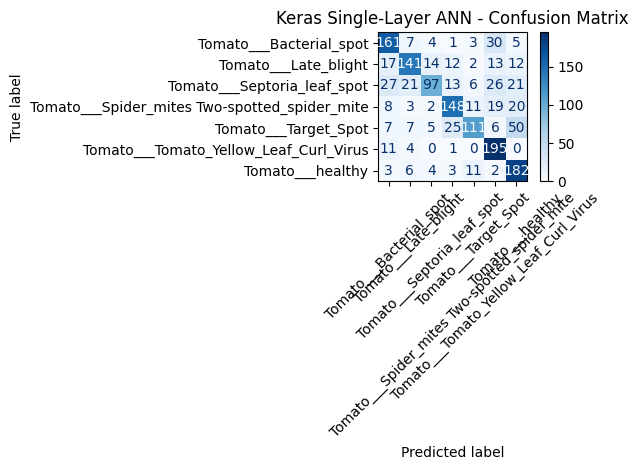

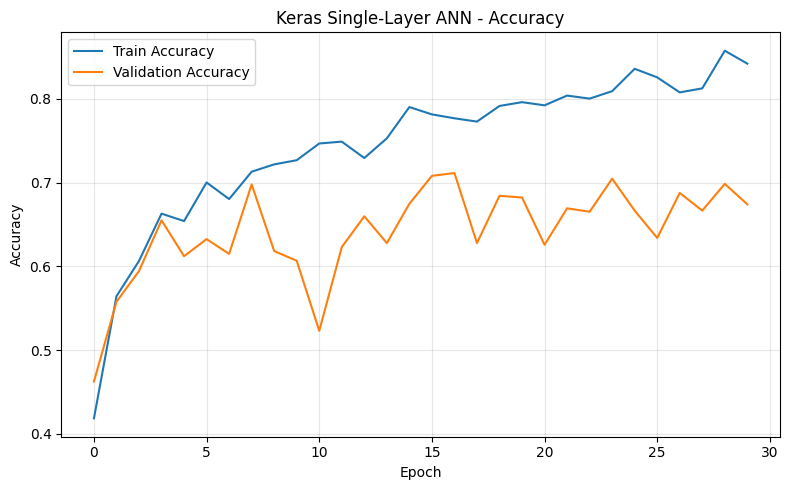

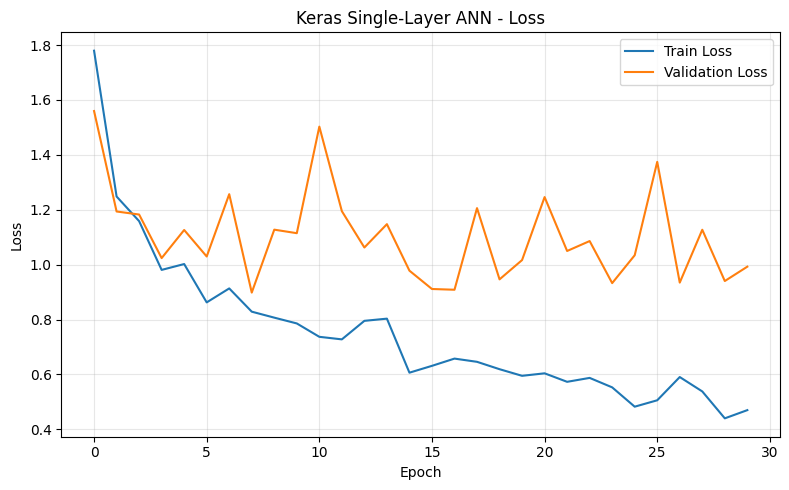


Best Model Information
Best Epoch       : 17
Best Val Accuracy: 0.7116

결과 저장 완료
accuracy_curve.png
best_tomato_keras_single_ann.keras
classification_report.csv
confusion_matrix.csv
confusion_matrix.png
loss_curve.png
metrics.csv
test_results.txt
training_history.csv


In [ ]:
# ============================================================
# Keras Single-Layer ANN
# 평가 + 결과 저장
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# 1. 경로 설정
# ------------------------------------------------------------

MODEL_PATH = "/content/best_tomato_keras_single_ann.keras"

RESULT_DIR = "/content/best_tomato_keras_single_ann_results"
os.makedirs(RESULT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 2. Best 모델 불러오기
# ------------------------------------------------------------

best_model = load_model(MODEL_PATH)

print("Best ANN 모델 불러오기 완료")
best_model.summary()

# ------------------------------------------------------------
# 3. Test 데이터 예측
# ------------------------------------------------------------

print("\nTest 데이터 평가 중...")

y_prob = best_model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

# test_ds에서 실제 라벨 추출
y_true = np.concatenate([
    y.numpy() for _, y in test_ds
])

# ------------------------------------------------------------
# 4. 기본 평가 지표
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\n==============================")
print("Keras Single-Layer ANN")
print("==============================")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# ------------------------------------------------------------
# 5. Classification Report
# ------------------------------------------------------------

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_text = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print("\nClassification Report")
print(report_text)

# CSV 저장
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(
    os.path.join(RESULT_DIR, "classification_report.csv"),
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# 6. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix")
print(cm)

# CSV 저장
cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cm_df.to_csv(
    os.path.join(RESULT_DIR, "confusion_matrix.csv"),
    encoding="utf-8-sig"
)

# 이미지 저장
plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)

plt.title("Keras Single-Layer ANN - Confusion Matrix")
plt.tight_layout()

plt.savefig(
    os.path.join(RESULT_DIR, "confusion_matrix.png"),
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 7. 최종 평가 결과 CSV
# ------------------------------------------------------------

metrics_df = pd.DataFrame({
    "Model": ["Keras Single-Layer ANN"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1": [f1]
})

metrics_df.to_csv(
    os.path.join(RESULT_DIR, "metrics.csv"),
    index=False,
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# 8. 학습 History 저장
# ------------------------------------------------------------

history_df = pd.DataFrame(history.history)

history_df.insert(
    0,
    "epoch",
    range(1, len(history_df) + 1)
)

history_df.to_csv(
    os.path.join(RESULT_DIR, "training_history.csv"),
    index=False,
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# 9. Accuracy 그래프
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Keras Single-Layer ANN - Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(RESULT_DIR, "accuracy_curve.png"),
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 10. Loss 그래프
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Keras Single-Layer ANN - Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(RESULT_DIR, "loss_curve.png"),
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 11. Best Epoch 확인
# ------------------------------------------------------------

best_epoch = np.argmax(history.history["val_accuracy"]) + 1
best_val_accuracy = max(history.history["val_accuracy"])

print("\n==============================")
print("Best Model Information")
print("==============================")
print(f"Best Epoch       : {best_epoch}")
print(f"Best Val Accuracy: {best_val_accuracy:.4f}")

# ------------------------------------------------------------
# 12. 텍스트 결과 저장
# ------------------------------------------------------------

result_text = f"""
========================================
Keras Single-Layer ANN
========================================

Model Architecture
Input: 64x64x3
Flatten
Dense(7, Softmax)

Total Parameters:
{best_model.count_params():,}

Training
Optimizer: Adam
Learning Rate: 0.001
Batch Size: 32
Epochs: 30
Data Augmentation: None
Seed: 42

Best Epoch:
{best_epoch}

Best Validation Accuracy:
{best_val_accuracy:.4f}

Test Results
----------------------------------------
Accuracy : {accuracy:.4f}
Precision: {precision:.4f}
Recall   : {recall:.4f}
F1-score : {f1:.4f}

Classification Report
----------------------------------------
{report_text}

Confusion Matrix
----------------------------------------
{cm}
"""

with open(
    os.path.join(RESULT_DIR, "test_results.txt"),
    "w",
    encoding="utf-8"
) as f:
    f.write(result_text)

# ------------------------------------------------------------
# 13. 모델도 결과 폴더에 복사
# ------------------------------------------------------------

import shutil

shutil.copy(
    MODEL_PATH,
    os.path.join(
        RESULT_DIR,
        "best_tomato_keras_single_ann.keras"
    )
)

# ------------------------------------------------------------
# 14. 결과 파일 확인
# ------------------------------------------------------------

print("\n==============================")
print("결과 저장 완료")
print("==============================")

for file in sorted(os.listdir(RESULT_DIR)):
    print(file)

In [ ]:
# 결과 폴더 ZIP 압축 후 데스크탑 다운로드
import shutil
from google.colab import files

zip_path = shutil.make_archive(
    "/content/best_tomato_keras_single_ann_results",
    "zip",
    "/content/best_tomato_keras_single_ann_results"
)

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# PyTorch 단층 ANN
# 64x64 -> Flatten -> Output 7
# ============================================================

import os
import random
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. Seed
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ============================================================
# 2. 설정
# ============================================================

DATA_DIR = "/content/tomato_dataset_clean"

IMG_SIZE = 64
BATCH_SIZE = 32
EPOCHS = 30

BEST_MODEL_PATH = "/content/best_tomato_pytorch_single_ann.pth"

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

# ============================================================
# 3. Dataset
# ============================================================

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "train"),
    transform=transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "val"),
    transform=transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "test"),
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_dataset.classes
NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

# ============================================================
# 4. 단층 ANN
# ============================================================

class SingleLayerANN(nn.Module):

    def __init__(self, num_classes=7):
        super().__init__()

        # 64 x 64 x 3 = 12,288
        self.flatten = nn.Flatten()

        # 단층 ANN
        self.fc = nn.Linear(
            64 * 64 * 3,
            num_classes
        )

    def forward(self, x):

        x = self.flatten(x)

        x = self.fc(x)

        return x


model = SingleLayerANN(
    NUM_CLASSES
).to(device)

print("\nModel:")
print(model)

# ============================================================
# 5. Loss / Optimizer
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# ============================================================
# 6. 기록
# ============================================================

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0
best_epoch = 0

# ============================================================
# 7. 학습
# ============================================================

for epoch in range(EPOCHS):

    # -------------------------
    # Train
    # -------------------------

    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        train_loss += (
            loss.item()
            * labels.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        train_total += labels.size(0)

        train_correct += (
            predictions == labels
        ).sum().item()

    train_loss /= train_total

    train_accuracy = (
        train_correct / train_total
    )

    # -------------------------
    # Validation
    # -------------------------

    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_loss += (
                loss.item()
                * labels.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            val_total += labels.size(0)

            val_correct += (
                predictions == labels
            ).sum().item()

    val_loss /= val_total

    val_accuracy = (
        val_correct / val_total
    )

    # 기록
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(
        train_accuracy
    )

    val_accuracies.append(
        val_accuracy
    )

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )

    # -------------------------
    # Best Model
    # -------------------------

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

# ============================================================
# 8. Best Model
# ============================================================

model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model.eval()

print("\n==============================")
print("Best Model")
print("==============================")

print(
    "Best Epoch:",
    best_epoch
)

print(
    f"Best Val Accuracy: "
    f"{best_val_accuracy:.4f}"
)

# ============================================================
# 9. Test
# ============================================================

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            predictions.cpu().numpy()
        )

# ============================================================
# 10. Metrics
# ============================================================

test_accuracy = accuracy_score(
    y_true,
    y_pred
)

test_precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\n================================")
print("PyTorch Single-Layer ANN")
print("================================")

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")

# ============================================================
# 11. Classification Report
# ============================================================

print("\nClassification Report")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

# ============================================================
# 12. Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\nConfusion Matrix")
print(cm)

Device: cuda
Classes: ['Tomato___Bacterial_spot', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___healthy']
Train: 6853
Validation: 1470
Test: 1477

Model:
SingleLayerANN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=12288, out_features=7, bias=True)
)
Epoch [01/30] Train Loss: 1.6215 Train Acc: 0.4426 | Val Loss: 1.7997 Val Acc: 0.4660
Epoch [02/30] Train Loss: 1.2326 Train Acc: 0.5609 | Val Loss: 1.4519 Val Acc: 0.5429
Epoch [03/30] Train Loss: 1.2226 Train Acc: 0.5913 | Val Loss: 1.2864 Val Acc: 0.5782
Epoch [04/30] Train Loss: 1.1331 Train Acc: 0.6135 | Val Loss: 1.6032 Val Acc: 0.4769
Epoch [05/30] Train Loss: 1.0605 Train Acc: 0.6375 | Val Loss: 0.9389 Val Acc: 0.6952
Epoch [06/30] Train Loss: 0.9377 Train Acc: 0.6761 | Val Loss: 1.1633 Val Acc: 0.5932
Epoch [07/30] Train Loss: 0.9223 Train Acc: 0.6807 | Val Loss: 2.7720 V

Best PyTorch ANN 모델 불러오기 완료

Test 데이터 평가 중...

PyTorch Single-Layer ANN
Accuracy : 0.7265
Precision: 0.7328
Recall   : 0.7265
F1-score : 0.7239

Classification Report
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.64      0.84      0.73       211
                         Tomato___Late_blight       0.77      0.61      0.68       211
                  Tomato___Septoria_leaf_spot       0.70      0.66      0.68       211
Tomato___Spider_mites Two-spotted_spider_mite       0.74      0.77      0.75       211
                         Tomato___Target_Spot       0.68      0.63      0.65       211
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.78      0.91      0.84       211
                             Tomato___healthy       0.83      0.66      0.73       211

                                     accuracy                           0.73      1477
                                    macro avg   

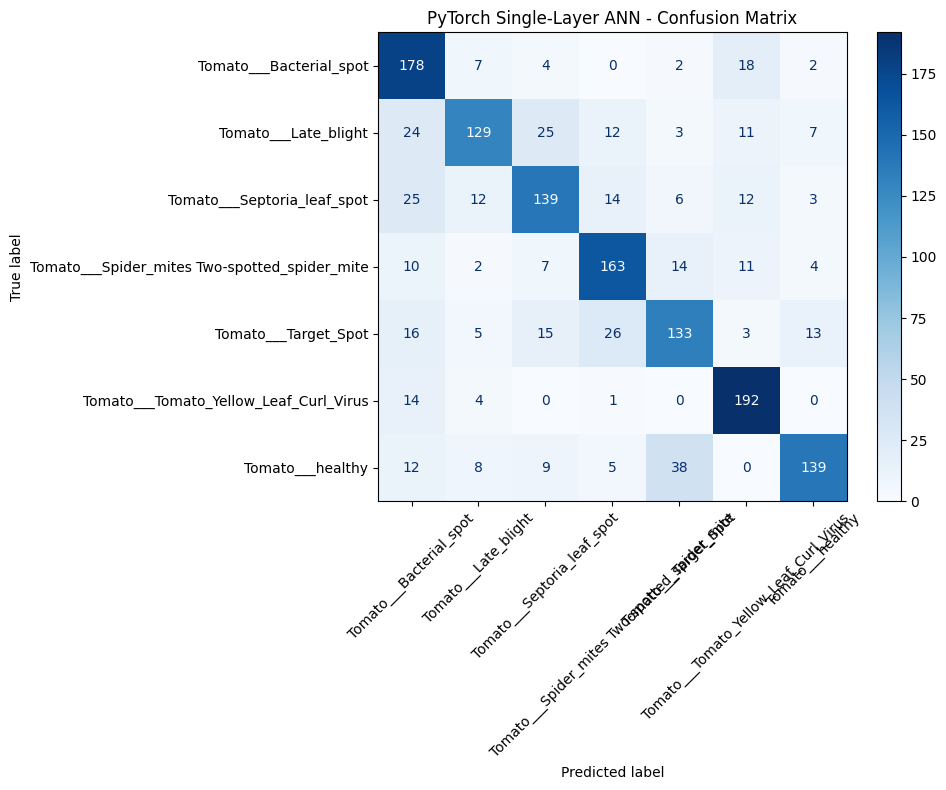

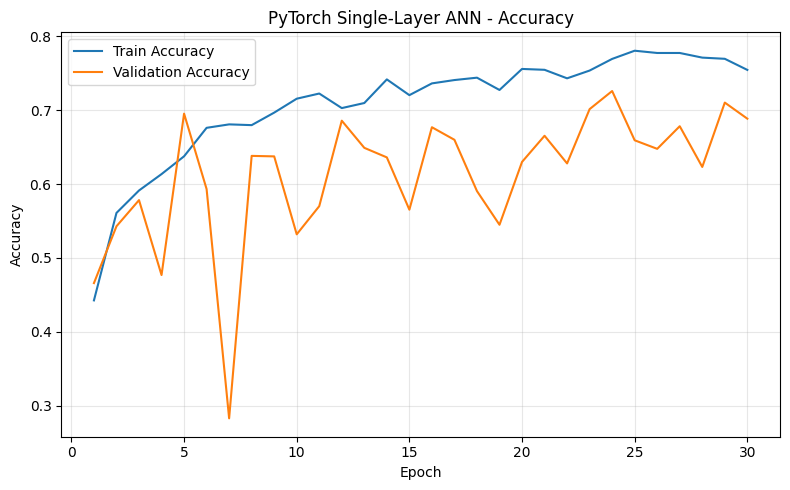

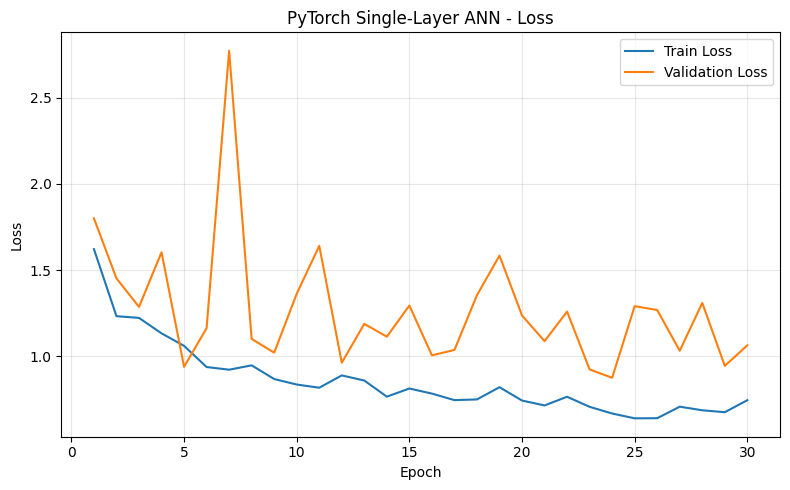


Best Model Information
Best Epoch       : 24
Best Val Accuracy: 0.7259

결과 저장 완료
accuracy_curve.png
best_tomato_pytorch_single_ann.pth
classification_report.csv
confusion_matrix.csv
confusion_matrix.png
loss_curve.png
metrics.csv
test_results.txt
training_history.csv

ZIP 생성 완료:
/content/best_tomato_pytorch_single_ann_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


데스크탑 다운로드 시작!


In [ ]:
# ============================================================
# PyTorch Single-Layer ANN
# 평가 + 결과 저장 + 데스크탑 다운로드
# ============================================================

import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# 1. 결과 저장 폴더
# ------------------------------------------------------------

RESULT_DIR = "/content/best_tomato_pytorch_single_ann_results"
os.makedirs(RESULT_DIR, exist_ok=True)

MODEL_PATH = "/content/best_tomato_pytorch_single_ann.pth"

# ------------------------------------------------------------
# 2. Best 모델 불러오기
# ------------------------------------------------------------

# 반드시 학습할 때 사용한 Single-Layer ANN 구조와 동일해야 함
best_model = SingleLayerANN(num_classes=7).to(device)

best_model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

best_model.eval()

print("Best PyTorch ANN 모델 불러오기 완료")

# ------------------------------------------------------------
# 3. Test 데이터 예측
# ------------------------------------------------------------

print("\nTest 데이터 평가 중...")

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        y_true.extend(
            labels.cpu().numpy()
        )

        y_pred.extend(
            predictions.cpu().numpy()
        )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ------------------------------------------------------------
# 4. 평가 지표
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\n==============================")
print("PyTorch Single-Layer ANN")
print("==============================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# ------------------------------------------------------------
# 5. Classification Report
# ------------------------------------------------------------

report_text = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

print("\nClassification Report")
print(report_text)

report_df = pd.DataFrame(
    report_dict
).transpose()

report_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "classification_report.csv"
    ),
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# 6. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\nConfusion Matrix")
print(cm)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cm_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "confusion_matrix.csv"
    ),
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# 7. Confusion Matrix 이미지 저장
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 8)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)

plt.title(
    "PyTorch Single-Layer ANN - Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULT_DIR,
        "confusion_matrix.png"
    ),
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 8. 최종 평가 결과 CSV
# ------------------------------------------------------------

metrics_df = pd.DataFrame({
    "Model": ["PyTorch Single-Layer ANN"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1": [f1]
})

metrics_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "metrics.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# 9. 학습 History 저장
# ------------------------------------------------------------

history_df = pd.DataFrame({
    "epoch": range(
        1,
        len(train_losses) + 1
    ),
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_accuracy": train_accuracies,
    "val_accuracy": val_accuracies
})

history_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "training_history.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# 10. Accuracy 그래프
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "PyTorch Single-Layer ANN - Accuracy"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULT_DIR,
        "accuracy_curve.png"
    ),
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 11. Loss 그래프
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "PyTorch Single-Layer ANN - Loss"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULT_DIR,
        "loss_curve.png"
    ),
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 12. Best Epoch
# ------------------------------------------------------------

best_epoch = np.argmax(
    val_accuracies
) + 1

best_val_accuracy = max(
    val_accuracies
)

print("\n==============================")
print("Best Model Information")
print("==============================")

print(f"Best Epoch       : {best_epoch}")
print(f"Best Val Accuracy: {best_val_accuracy:.4f}")

# ------------------------------------------------------------
# 13. 텍스트 결과 저장
# ------------------------------------------------------------

result_text = f"""
========================================
PyTorch Single-Layer ANN
========================================

Model Architecture
Input: 64x64x3
Flatten
Linear(12288 -> 7)

Training
Optimizer: Adam
Learning Rate: 0.001
Batch Size: 32
Epochs: 30
Loss: CrossEntropyLoss
Data Augmentation: None
Seed: 42

Best Epoch:
{best_epoch}

Best Validation Accuracy:
{best_val_accuracy:.4f}

Test Results
----------------------------------------
Accuracy : {accuracy:.4f}
Precision: {precision:.4f}
Recall   : {recall:.4f}
F1-score : {f1:.4f}

Classification Report
----------------------------------------
{report_text}

Confusion Matrix
----------------------------------------
{cm}
"""

with open(
    os.path.join(
        RESULT_DIR,
        "test_results.txt"
    ),
    "w",
    encoding="utf-8"
) as f:
    f.write(result_text)

# ------------------------------------------------------------
# 14. Best 모델 파일 복사
# ------------------------------------------------------------

shutil.copy(
    MODEL_PATH,
    os.path.join(
        RESULT_DIR,
        "best_tomato_pytorch_single_ann.pth"
    )
)

# ------------------------------------------------------------
# 15. 결과 파일 확인
# ------------------------------------------------------------

print("\n==============================")
print("결과 저장 완료")
print("==============================")

for file in sorted(
    os.listdir(RESULT_DIR)
):
    print(file)

# ------------------------------------------------------------
# 16. ZIP 압축
# ------------------------------------------------------------

zip_path = shutil.make_archive(
    "/content/best_tomato_pytorch_single_ann_results",
    "zip",
    RESULT_DIR
)

print("\nZIP 생성 완료:")
print(zip_path)

# ------------------------------------------------------------
# 17. 데스크탑으로 다운로드
# ------------------------------------------------------------

from google.colab import files

files.download(zip_path)

print("\n데스크탑 다운로드 시작!")

비교 막대그래프

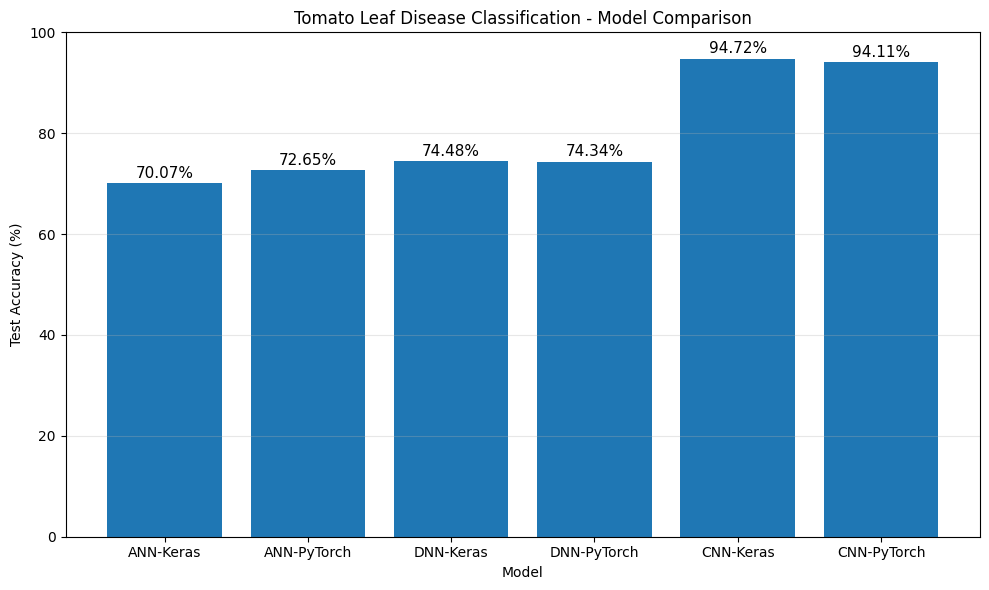

그래프와 CSV 저장 완료


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# 최종 6개 모델 Test Accuracy
# ============================================

data = {
    "Model": [
        "ANN-Keras",
        "ANN-PyTorch",
        "DNN-Keras",
        "DNN-PyTorch",
        "CNN-Keras",
        "CNN-PyTorch"
    ],
    "Accuracy": [
        70.07,
        72.65,
        74.48,
        74.34,
        94.72,
        94.11
    ]
}

df = pd.DataFrame(data)

# ============================================
# 그래프
# ============================================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    df["Model"],
    df["Accuracy"]
)

plt.ylabel("Test Accuracy (%)")
plt.xlabel("Model")
plt.title("Tomato Leaf Disease Classification - Model Comparison")

# 정확도 숫자 표시
for bar, value in zip(bars, df["Accuracy"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

# PNG 저장
plt.savefig(
    "/content/final_6_model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# CSV 저장
df.to_csv(
    "/content/final_6_model_accuracy_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

print("그래프와 CSV 저장 완료")

In [ ]:
from google.colab import files

files.download("/content/final_6_model_accuracy_comparison.png")
files.download("/content/final_6_model_accuracy_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Best CNN 모델 불러오기 완료
CNN 입력 형태: (None, 128, 128, 3)
Found 1477 files belonging to 7 classes.

Classes:
['Tomato___Bacterial_spot', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___healthy']

선택된 클래스:
Tomato___Bacterial_spot

Conv Layer:
1 conv2d_9
2 conv2d_10
3 conv2d_11


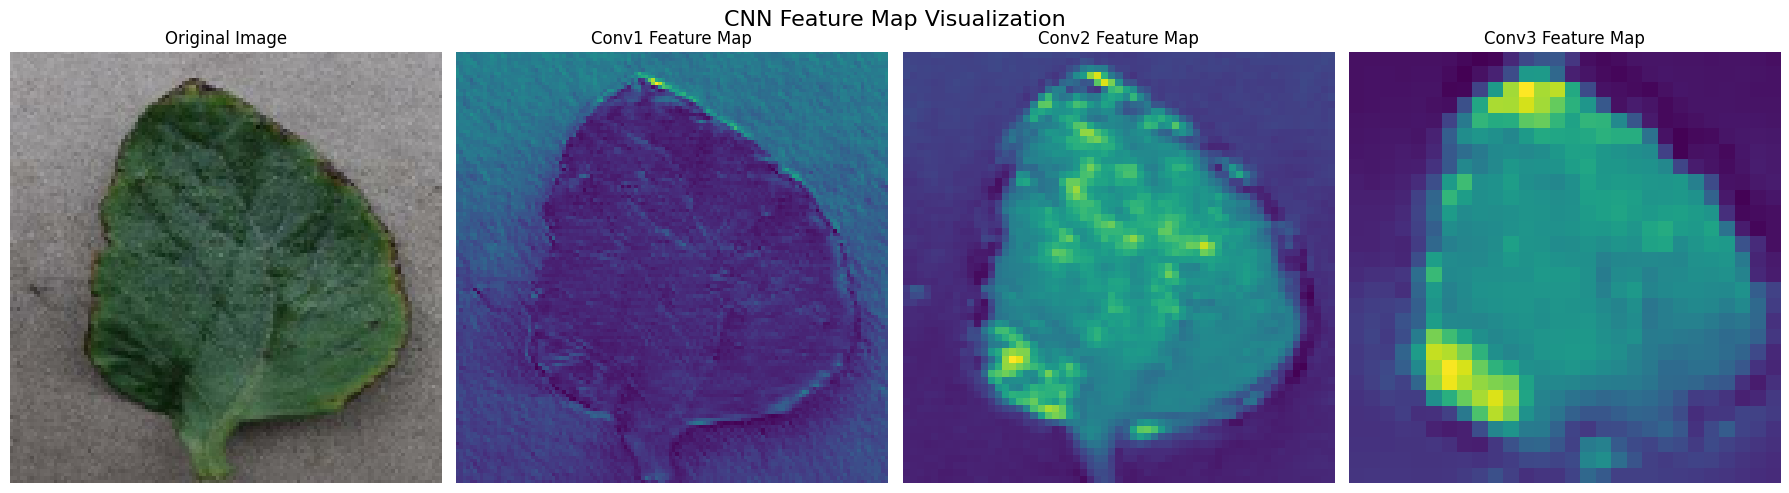


Feature Map 저장 완료
/content/tomato_cnn_feature_map.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


데스크톱 다운로드 시작!


In [ ]:
# ============================================================
# Keras CNN Feature Map
# 최종 CNN = 128x128 입력 기준
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from google.colab import files

# ------------------------------------------------------------
# 1. Best CNN 모델
# ------------------------------------------------------------

model_path = "/content/best_tomato_cnn_dropout05.keras"

cnn_model = load_model(model_path)

print("Best CNN 모델 불러오기 완료")
print("CNN 입력 형태:", cnn_model.input_shape)

# ------------------------------------------------------------
# 2. 128x128 Test Dataset 생성
# ------------------------------------------------------------

feature_test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/tomato_dataset_clean/test",
    image_size=(128, 128),
    batch_size=32,
    shuffle=False
)

class_names_feature = feature_test_ds.class_names

print("\nClasses:")
print(class_names_feature)

# ------------------------------------------------------------
# 3. 이미지 하나 선택
# ------------------------------------------------------------

images, labels = next(iter(feature_test_ds))

sample_image = images[0:1]
sample_label = labels[0].numpy()

print("\n선택된 클래스:")
print(class_names_feature[sample_label])

# ------------------------------------------------------------
# 4. Conv2D 레이어 찾기
# ------------------------------------------------------------

conv_layers = [
    layer for layer in cnn_model.layers
    if isinstance(layer, tf.keras.layers.Conv2D)
]

print("\nConv Layer:")

for i, layer in enumerate(conv_layers):
    print(i + 1, layer.name)

# ------------------------------------------------------------
# 5. Feature Map 추출 모델
# ------------------------------------------------------------

feature_model = tf.keras.Model(
    inputs=cnn_model.inputs,
    outputs=[layer.output for layer in conv_layers]
)

feature_maps = feature_model.predict(
    sample_image,
    verbose=0
)

# ------------------------------------------------------------
# 6. Feature Map 시각화
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    4,
    figsize=(18, 5)
)

# 원본
axes[0].imshow(
    sample_image[0].numpy().astype("uint8")
)

axes[0].set_title(
    "Original Image"
)

axes[0].axis("off")

# Conv1 ~ Conv3
for i in range(3):

    fmap = feature_maps[i][0]

    # 채널 평균
    fmap_mean = np.mean(
        fmap,
        axis=-1
    )

    axes[i + 1].imshow(
        fmap_mean,
        cmap="viridis"
    )

    axes[i + 1].set_title(
        f"Conv{i + 1} Feature Map"
    )

    axes[i + 1].axis("off")

plt.suptitle(
    "CNN Feature Map Visualization",
    fontsize=16
)

plt.tight_layout()

# ------------------------------------------------------------
# 7. PNG 저장
# ------------------------------------------------------------

save_path = "/content/tomato_cnn_feature_map.png"

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n================================")
print("Feature Map 저장 완료")
print("================================")
print(save_path)

# ------------------------------------------------------------
# 8. 데스크톱 다운로드
# ------------------------------------------------------------

files.download(save_path)

print("\n데스크톱 다운로드 시작!")

Best CNN 모델 불러오기 완료
Input shape: (None, 128, 128, 3)
Found 1477 files belonging to 7 classes.
선택된 클래스: Tomato___Bacterial_spot

Conv Layer:
Conv1: conv2d_9 / Filters: 32
Conv2: conv2d_10 / Filters: 64
Conv3: conv2d_11 / Filters: 128


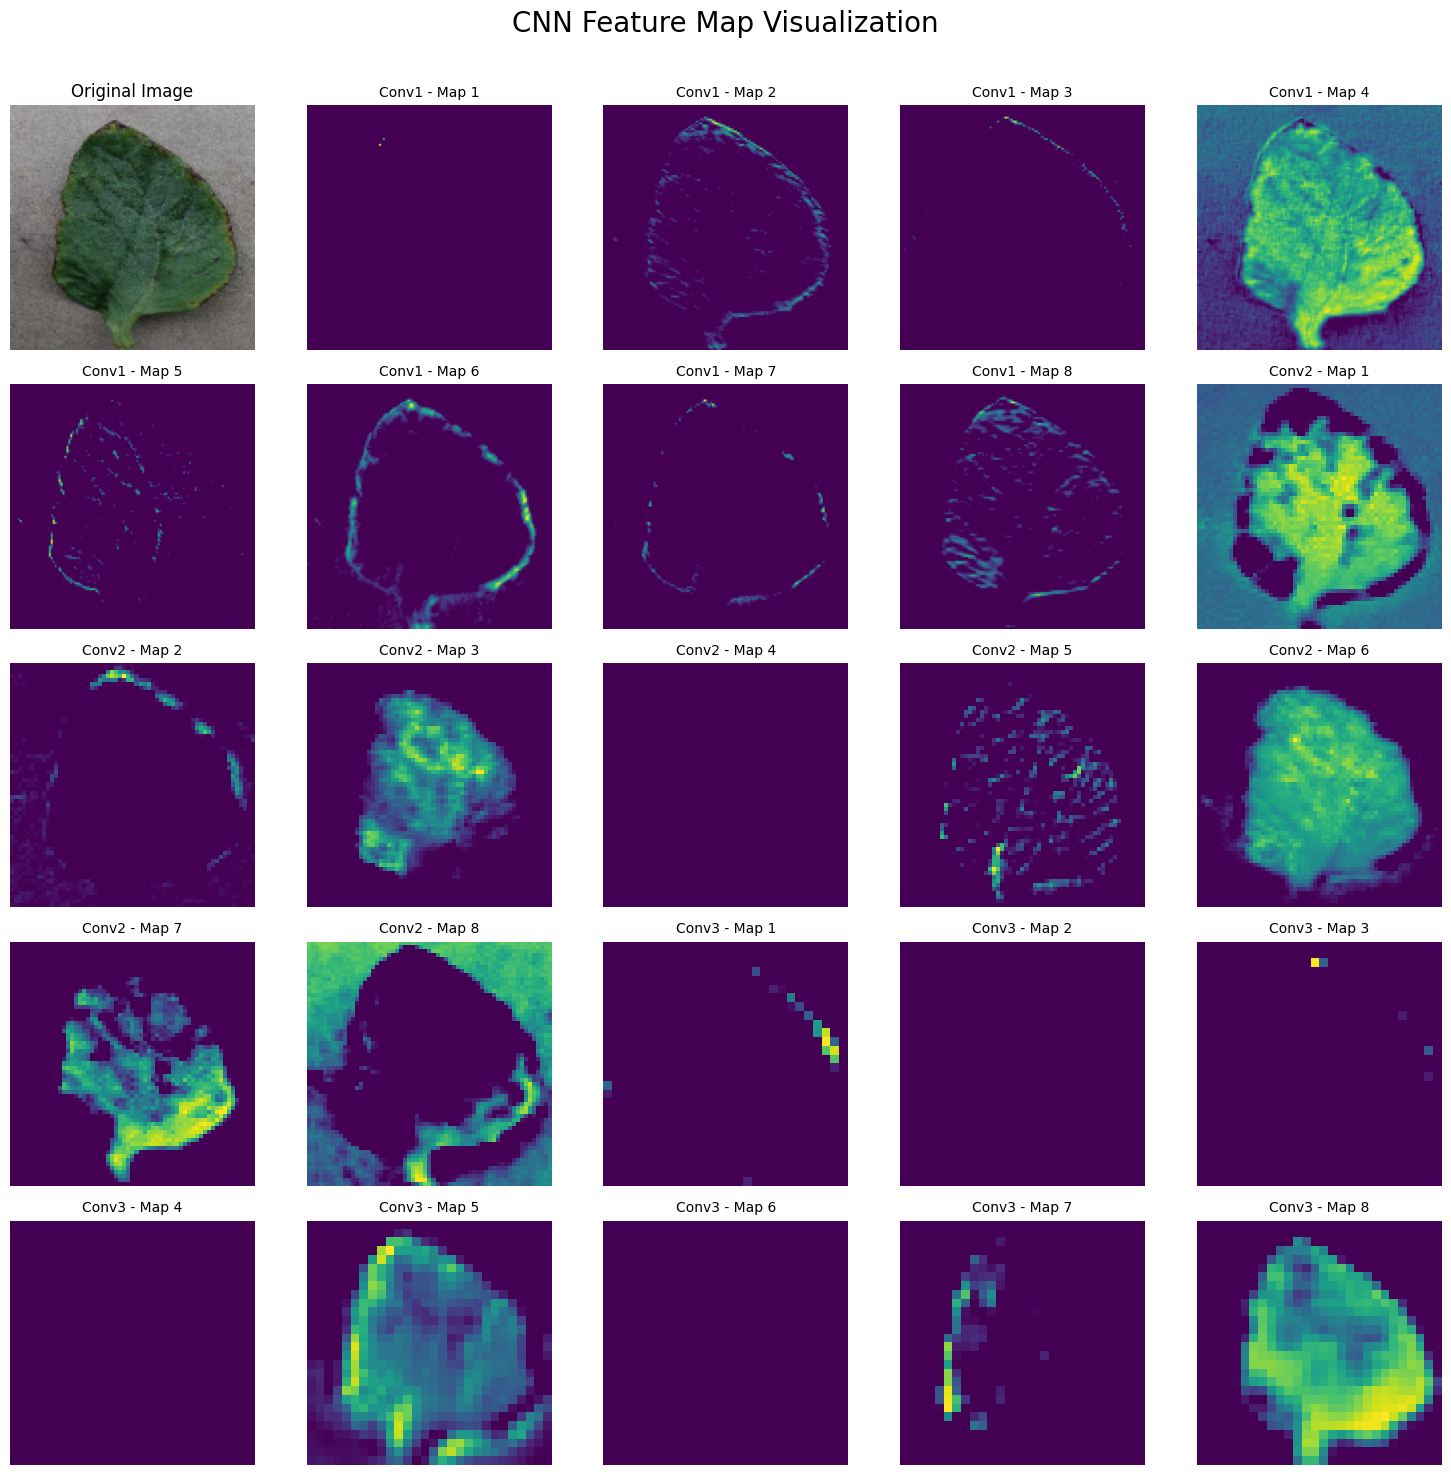


Feature Map 25개 저장 완료
/content/tomato_cnn_feature_map_25.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


데스크톱 다운로드 시작!


In [ ]:
# ============================================================
# CNN Feature Map 25개 시각화
# Original 1 + Conv1 8 + Conv2 8 + Conv3 8
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from google.colab import files

# ------------------------------------------------------------
# 1. 최종 Keras CNN 불러오기
# ------------------------------------------------------------

model_path = "/content/best_tomato_cnn_dropout05.keras"

cnn_model = load_model(model_path)

print("Best CNN 모델 불러오기 완료")
print("Input shape:", cnn_model.input_shape)

# ------------------------------------------------------------
# 2. CNN용 128x128 Test Dataset
# ------------------------------------------------------------

feature_test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/tomato_dataset_clean/test",
    image_size=(128, 128),
    batch_size=32,
    shuffle=False
)

class_names_feature = feature_test_ds.class_names

# ------------------------------------------------------------
# 3. 이미지 하나 선택
# ------------------------------------------------------------

images, labels = next(iter(feature_test_ds))

sample_image = images[0:1]
sample_label = labels[0].numpy()

print("선택된 클래스:", class_names_feature[sample_label])

# ------------------------------------------------------------
# 4. Conv2D 레이어 찾기
# ------------------------------------------------------------

conv_layers = [
    layer for layer in cnn_model.layers
    if isinstance(layer, tf.keras.layers.Conv2D)
]

print("\nConv Layer:")

for i, layer in enumerate(conv_layers):
    print(
        f"Conv{i+1}: {layer.name} / "
        f"Filters: {layer.filters}"
    )

# ------------------------------------------------------------
# 5. Feature Map 추출
# ------------------------------------------------------------

feature_model = tf.keras.Model(
    inputs=cnn_model.inputs,
    outputs=[layer.output for layer in conv_layers]
)

feature_maps = feature_model.predict(
    sample_image,
    verbose=0
)

# ------------------------------------------------------------
# 6. 25개 Feature Map 선택
# ------------------------------------------------------------

# 각 Conv Layer에서 8개 채널 선택
selected_maps = []

for fmap in feature_maps:

    fmap = fmap[0]

    # 첫 8개 채널 사용
    selected_maps.append(
        fmap[:, :, :8]
    )

# ------------------------------------------------------------
# 7. 5 x 5 화면 구성
# ------------------------------------------------------------

fig, axes = plt.subplots(
    5,
    5,
    figsize=(15, 15)
)

axes = axes.flatten()

# ------------------------------------------------------------
# 첫 번째: 원본 이미지
# ------------------------------------------------------------

axes[0].imshow(
    sample_image[0].numpy().astype("uint8")
)

axes[0].set_title(
    "Original Image",
    fontsize=12
)

axes[0].axis("off")

# ------------------------------------------------------------
# Conv1 / Conv2 / Conv3
# ------------------------------------------------------------

plot_index = 1

for layer_idx in range(3):

    maps = selected_maps[layer_idx]

    for channel_idx in range(8):

        fmap = maps[:, :, channel_idx]

        axes[plot_index].imshow(
            fmap,
            cmap="viridis"
        )

        axes[plot_index].set_title(
            f"Conv{layer_idx + 1} - Map {channel_idx + 1}",
            fontsize=10
        )

        axes[plot_index].axis("off")

        plot_index += 1

# ------------------------------------------------------------
# 제목
# ------------------------------------------------------------

plt.suptitle(
    "CNN Feature Map Visualization",
    fontsize=20
)

plt.tight_layout(
    rect=[0, 0, 1, 0.97]
)

# ------------------------------------------------------------
# 8. 저장
# ------------------------------------------------------------

save_path = "/content/tomato_cnn_feature_map_25.png"

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n====================================")
print("Feature Map 25개 저장 완료")
print("====================================")
print(save_path)

# ------------------------------------------------------------
# 9. 데스크톱 다운로드
# ------------------------------------------------------------

files.download(save_path)

print("\n데스크톱 다운로드 시작!")

In [ ]:
import os
import shutil

# ============================================
# Google Drive 백업 폴더
# ============================================

DRIVE_DIR = "/content/drive/MyDrive/tomato_project_final"

os.makedirs(DRIVE_DIR, exist_ok=True)

# ============================================
# 백업할 최종 자료
# ============================================

items = [
    "/content/best_tomato_keras_single_ann.keras",
    "/content/best_tomato_pytorch_single_ann.pth",
    "/content/best_tomato_cnn_dropout05.keras",

    "/content/best_tomato_keras_single_ann_results",
    "/content/best_tomato_pytorch_single_ann_results",

    "/content/best_tomato_keras_dnn_64_he_dropout05_results.zip",
    "/content/best_tomato_pytorch_dnn_results.zip",

    "/content/best_tomato_pytorch_single_ann_results.zip",

    "/content/tomato_cnn_feature_map_25.png",
    "/content/tomato_cnn_feature_map.png",
]

# ============================================
# 복사
# ============================================

for item in items:

    if not os.path.exists(item):
        print("없음:", item)
        continue

    destination = os.path.join(
        DRIVE_DIR,
        os.path.basename(item)
    )

    if os.path.isdir(item):

        shutil.copytree(
            item,
            destination,
            dirs_exist_ok=True
        )

    else:

        shutil.copy2(
            item,
            destination
        )

    print("백업 완료:", os.path.basename(item))

# ============================================
# 확인
# ============================================

print("\n==============================")
print("Google Drive 백업 완료")
print("==============================")
print(DRIVE_DIR)

print("\n저장된 파일:")
for name in sorted(os.listdir(DRIVE_DIR)):
    print("-", name)

백업 완료: best_tomato_keras_single_ann.keras
백업 완료: best_tomato_pytorch_single_ann.pth
백업 완료: best_tomato_cnn_dropout05.keras
백업 완료: best_tomato_keras_single_ann_results
백업 완료: best_tomato_pytorch_single_ann_results
없음: /content/best_tomato_keras_dnn_64_he_dropout05_results.zip
백업 완료: best_tomato_pytorch_dnn_results.zip
백업 완료: best_tomato_pytorch_single_ann_results.zip
백업 완료: tomato_cnn_feature_map_25.png
백업 완료: tomato_cnn_feature_map.png

Google Drive 백업 완료
/content/drive/MyDrive/tomato_project_final

저장된 파일:
- best_tomato_cnn_dropout05.keras
- best_tomato_keras_single_ann.keras
- best_tomato_keras_single_ann_results
- best_tomato_pytorch_dnn_results.zip
- best_tomato_pytorch_single_ann.pth
- best_tomato_pytorch_single_ann_results
- best_tomato_pytorch_single_ann_results.zip
- tomato_cnn_feature_map.png
- tomato_cnn_feature_map_25.png


In [ ]:
# ============================================================
# Keras DNN 최종 결과 찾기 + Google Drive 백업
# ============================================================

import os
import shutil

# Drive 백업 폴더
DRIVE_DIR = "/content/drive/MyDrive/tomato_project_final"
os.makedirs(DRIVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. /content에서 Keras DNN 관련 파일 찾기
# ------------------------------------------------------------

print("Keras DNN 관련 자료 검색 중...\n")

found = []

for root, dirs, files in os.walk("/content"):

    # Drive 내부는 검색에서 제외
    if root.startswith("/content/drive"):
        continue

    for name in files:

        if "keras_dnn" in name.lower() or "tomato_keras_dnn" in name.lower():
            path = os.path.join(root, name)
            found.append(path)

for root, dirs, files in os.walk("/content"):

    if root.startswith("/content/drive"):
        continue

    for name in dirs:

        if "keras_dnn" in name.lower() or "tomato_keras_dnn" in name.lower():
            path = os.path.join(root, name)

            if path not in found:
                found.append(path)

# ------------------------------------------------------------
# 2. 검색 결과
# ------------------------------------------------------------

if len(found) == 0:

    print("❌ Keras DNN 관련 파일을 찾지 못했어.")

else:

    print("찾은 자료:")

    for path in found:
        print("-", path)

    # --------------------------------------------------------
    # 3. Drive로 백업
    # --------------------------------------------------------

    print("\nDrive 백업 시작...\n")

    for item in found:

        name = os.path.basename(item)
        destination = os.path.join(
            DRIVE_DIR,
            name
        )

        if os.path.isdir(item):

            shutil.copytree(
                item,
                destination,
                dirs_exist_ok=True
            )

        else:

            shutil.copy2(
                item,
                destination
            )

        print("백업 완료:", name)

# ------------------------------------------------------------
# 4. 최종 Drive 확인
# ------------------------------------------------------------

print("\n==============================")
print("현재 Drive 최종 폴더")
print("==============================")

for name in sorted(os.listdir(DRIVE_DIR)):
    print("-", name)

Keras DNN 관련 자료 검색 중...

찾은 자료:
- /content/best_tomato_keras_dnn_64_final.keras
- /content/best_tomato_keras_dnn_64_results.zip
- /content/best_tomato_keras_dnn_64.keras
- /content/best_tomato_keras_dnn_64_dropout05.keras
- /content/best_tomato_keras_dnn_64_he_dropout05.keras
- /content/best_tomato_keras_dnn_64_results/best_tomato_keras_dnn_64.keras
- /content/best_tomato_keras_dnn_64_results

Drive 백업 시작...

백업 완료: best_tomato_keras_dnn_64_final.keras
백업 완료: best_tomato_keras_dnn_64_results.zip
백업 완료: best_tomato_keras_dnn_64.keras
백업 완료: best_tomato_keras_dnn_64_dropout05.keras
백업 완료: best_tomato_keras_dnn_64_he_dropout05.keras
백업 완료: best_tomato_keras_dnn_64.keras
백업 완료: best_tomato_keras_dnn_64_results

현재 Drive 최종 폴더
- best_tomato_cnn_dropout05.keras
- best_tomato_keras_dnn_64.keras
- best_tomato_keras_dnn_64_dropout05.keras
- best_tomato_keras_dnn_64_final.keras
- best_tomato_keras_dnn_64_he_dropout05.keras
- best_tomato_keras_dnn_64_results
- best_tomato_keras_dnn_64_results.zip

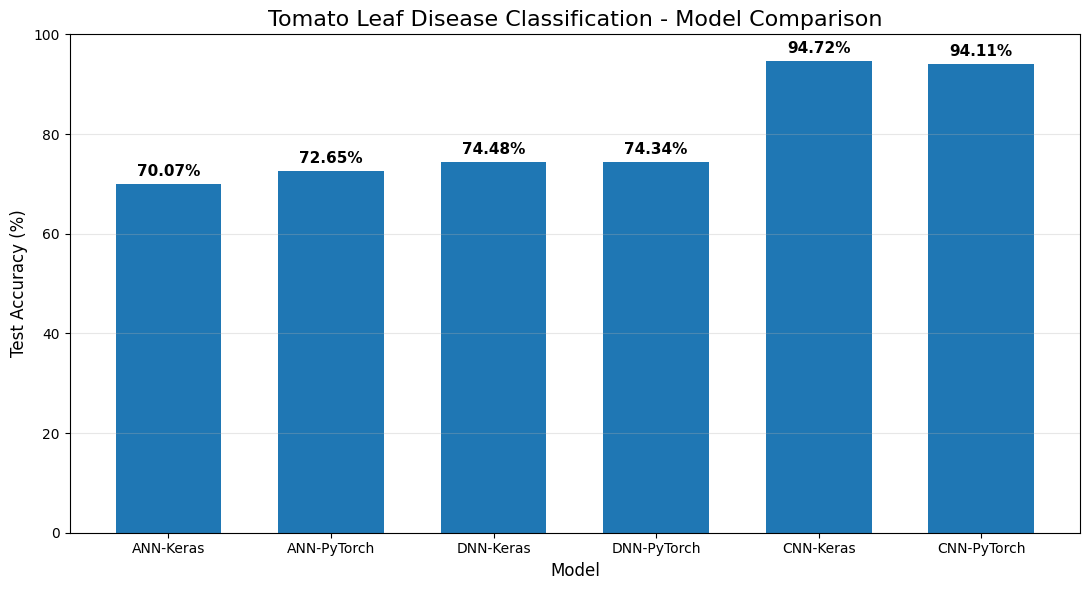

최종 그래프 생성 완료
         Model  Test Accuracy
0    ANN-Keras          70.07
1  ANN-PyTorch          72.65
2    DNN-Keras          74.48
3  DNN-PyTorch          74.34
4    CNN-Keras          94.72
5  CNN-PyTorch          94.11

Google Drive 백업 완료
/content/drive/MyDrive/tomato_project_final


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


그래프 데스크톱 다운로드 시작!


In [ ]:
# ============================================
# 최종 6개 모델 비교 그래프
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import shutil
from google.colab import files

# --------------------------------------------
# 최종 결과
# --------------------------------------------

df = pd.DataFrame({
    "Model": [
        "ANN-Keras",
        "ANN-PyTorch",
        "DNN-Keras",
        "DNN-PyTorch",
        "CNN-Keras",
        "CNN-PyTorch"
    ],
    "Test Accuracy": [
        70.07,
        72.65,
        74.48,
        74.34,
        94.72,
        94.11
    ]
})

# --------------------------------------------
# 그래프
# --------------------------------------------

plt.figure(figsize=(11, 6))

bars = plt.bar(
    df["Model"],
    df["Test Accuracy"],
    width=0.65
)

plt.title(
    "Tomato Leaf Disease Classification - Model Comparison",
    fontsize=16
)

plt.xlabel("Model", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)

plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

# 막대 위 정확도 표시
for bar, value in zip(bars, df["Test Accuracy"]):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()

# --------------------------------------------
# 파일 저장
# --------------------------------------------

png_path = "/content/final_6_model_accuracy_comparison.png"
csv_path = "/content/final_6_model_accuracy_comparison.csv"

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

df.to_csv(
    csv_path,
    index=False,
    encoding="utf-8-sig"
)

# --------------------------------------------
# Google Drive 백업
# --------------------------------------------

drive_dir = "/content/drive/MyDrive/tomato_project_final"

shutil.copy2(
    png_path,
    drive_dir
)

shutil.copy2(
    csv_path,
    drive_dir
)

print("================================")
print("최종 그래프 생성 완료")
print("================================")

print(df)

print("\nGoogle Drive 백업 완료")
print(drive_dir)

# --------------------------------------------
# 데스크톱 다운로드
# --------------------------------------------

files.download(png_path)

print("\n그래프 데스크톱 다운로드 시작!")

Epoch 수:
30


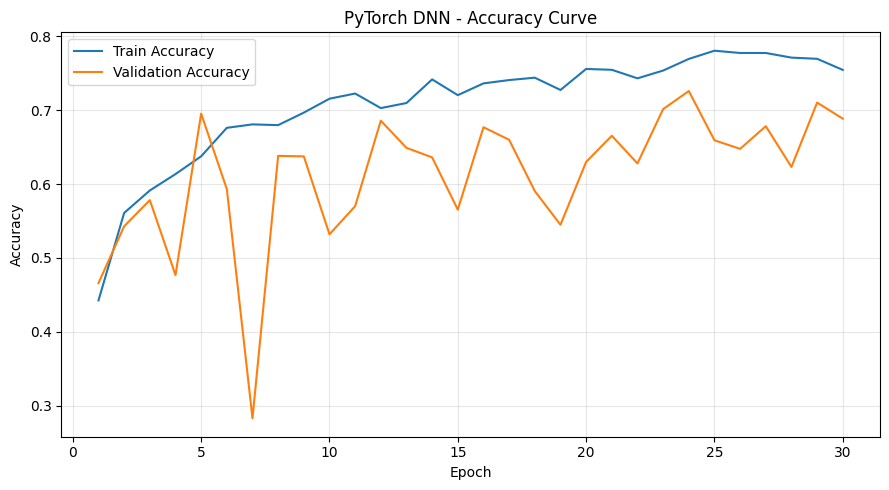

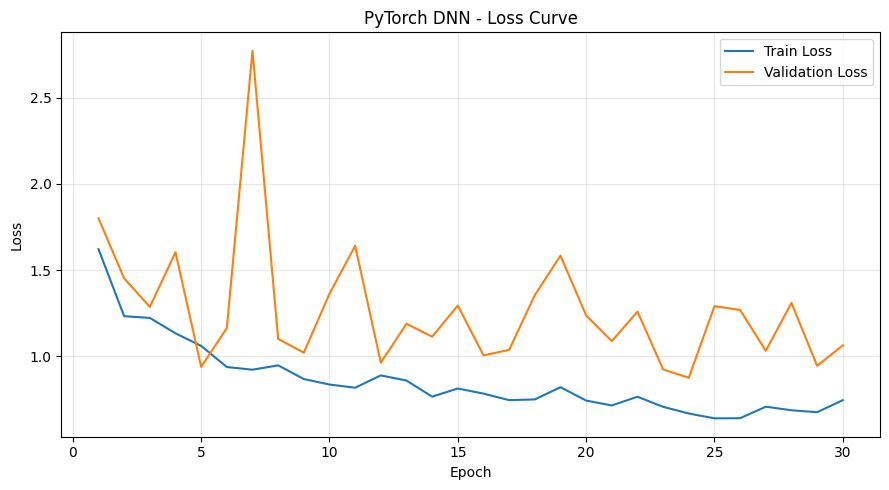


PyTorch DNN 학습곡선 저장 완료
Accuracy: /content/best_tomato_pytorch_dnn_results/accuracy_curve.png
Loss: /content/best_tomato_pytorch_dnn_results/loss_curve.png
History: /content/best_tomato_pytorch_dnn_results/training_history.csv
Drive 백업 완료


In [ ]:
# ============================================================
# PyTorch DNN - Accuracy / Loss Curve 저장
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

RESULT_DIR = "/content/best_tomato_pytorch_dnn_results"
os.makedirs(RESULT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. History 확인
# ------------------------------------------------------------

print("Epoch 수:")
print(len(train_losses))

# ------------------------------------------------------------
# 2. History CSV 저장
# ------------------------------------------------------------

history_df = pd.DataFrame({
    "epoch": range(1, len(train_losses) + 1),
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_accuracy": train_accuracies,
    "val_accuracy": val_accuracies
})

history_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "training_history.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# 3. Accuracy Curve
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("PyTorch DNN - Accuracy Curve")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

accuracy_path = os.path.join(
    RESULT_DIR,
    "accuracy_curve.png"
)

plt.savefig(
    accuracy_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 4. Loss Curve
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PyTorch DNN - Loss Curve")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

loss_path = os.path.join(
    RESULT_DIR,
    "loss_curve.png"
)

plt.savefig(
    loss_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 5. Drive 백업
# ------------------------------------------------------------

DRIVE_DIR = "/content/drive/MyDrive/tomato_project_final"

import shutil

shutil.copy2(
    accuracy_path,
    DRIVE_DIR
)

shutil.copy2(
    loss_path,
    DRIVE_DIR
)

shutil.copy2(
    os.path.join(
        RESULT_DIR,
        "training_history.csv"
    ),
    DRIVE_DIR
)

print("\n==============================")
print("PyTorch DNN 학습곡선 저장 완료")
print("==============================")

print("Accuracy:", accuracy_path)
print("Loss:", loss_path)
print("History:", os.path.join(RESULT_DIR, "training_history.csv"))
print("Drive 백업 완료")

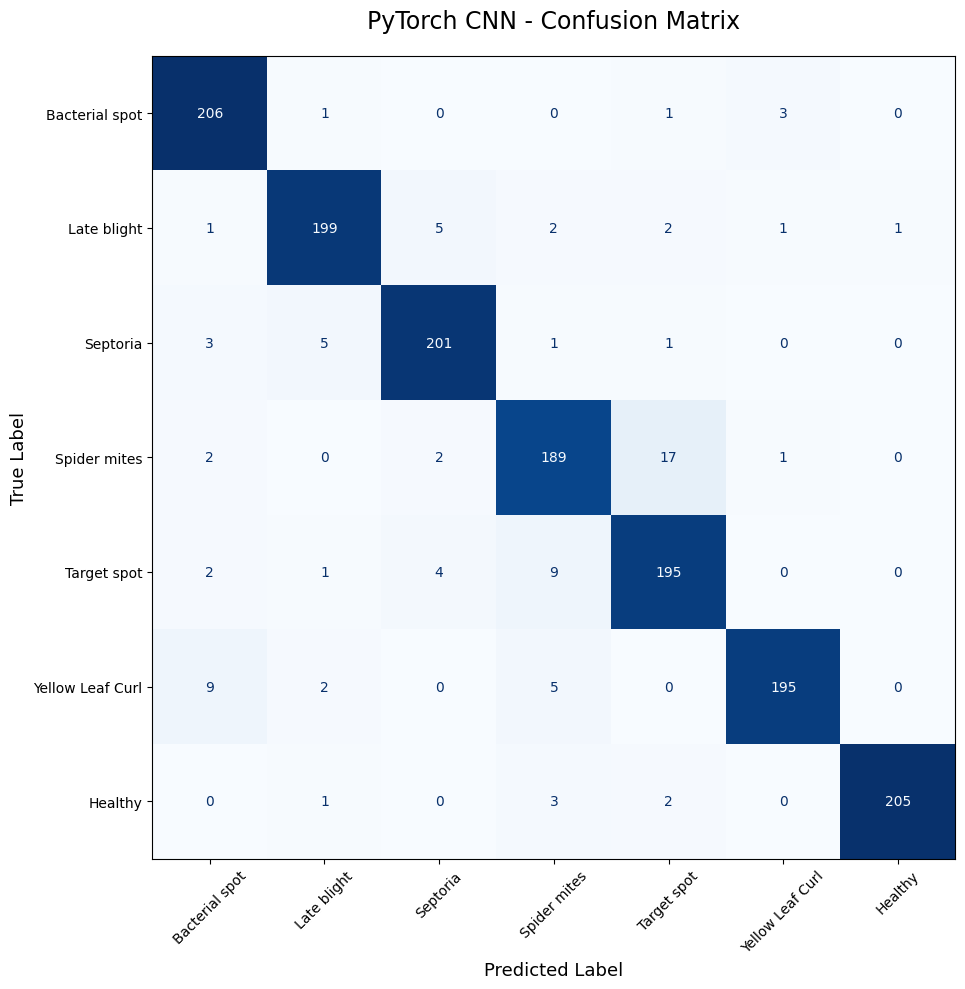

저장 완료:
/content/best_tomato_pytorch_cnn_results/confusion_matrix_clean.png


In [ ]:
# ============================================================
# PyTorch CNN - Confusion Matrix 깔끔하게 다시 저장
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# ------------------------------------------------------------
# 1. 기존 Confusion Matrix CSV 불러오기
# ------------------------------------------------------------

RESULT_DIR = "/content/best_tomato_pytorch_cnn_results"

cm_df = pd.read_csv(
    os.path.join(
        RESULT_DIR,
        "confusion_matrix.csv"
    ),
    index_col=0
)

cm = cm_df.values

# ------------------------------------------------------------
# 2. 발표용 짧은 클래스 이름
# ------------------------------------------------------------

short_names = [
    "Bacterial spot",
    "Late blight",
    "Septoria",
    "Spider mites",
    "Target spot",
    "Yellow Leaf Curl",
    "Healthy"
]

# ------------------------------------------------------------
# 3. Confusion Matrix
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 10)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=short_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    xticks_rotation=45,
    colorbar=False
)

ax.set_title(
    "PyTorch CNN - Confusion Matrix",
    fontsize=17,
    pad=20
)

ax.set_xlabel(
    "Predicted Label",
    fontsize=13
)

ax.set_ylabel(
    "True Label",
    fontsize=13
)

plt.tight_layout()

# ------------------------------------------------------------
# 4. 저장
# ------------------------------------------------------------

save_path = os.path.join(
    RESULT_DIR,
    "confusion_matrix_clean.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("저장 완료:")
print(save_path)

In [ ]:
import shutil

DRIVE_DIR = "/content/drive/MyDrive/tomato_project_final"

shutil.copy2(
    "/content/best_tomato_pytorch_cnn_results/confusion_matrix_clean.png",
    DRIVE_DIR
)

print("Google Drive 백업 완료")

Google Drive 백업 완료


In [ ]:
from google.colab import files

files.download(
    "/content/best_tomato_pytorch_dnn_results/accuracy_curve.png"
)

files.download(
    "/content/best_tomato_pytorch_dnn_results/loss_curve.png"
)

files.download(
    "/content/best_tomato_pytorch_dnn_results/training_history.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download(
    "/content/best_tomato_pytorch_cnn_results/confusion_matrix_clean.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>